# Figure 1: Forward velocity heatmaps (Cue 1 vs Cue 2)

Two side-by-side heatmaps of mean forward velocity across position bins
(rows = sessions, columns = position). Sessions with fewer than 10 trials
are excluded (matching the dash-app filter, see `animal_6_data_overview.ipynb`).
Horizontal lines mark the cue introduction (2024-11-26) and a later
behavioural transition (2025-01-17). The track schematic above each heatmap
uses a cue zone of [-80, 25]; a vertical line at -120 marks the position at
which the cue first becomes visible. Sized for an A4 thesis page; SVG export
at the bottom of the section.

In [3]:
import os
import sys
import glob
import json
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.lines import Line2D

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths()

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics
from analytics_processing.sessions_from_nas_parsing import (
    sessionlist_fullfnames_from_args, fullfnames2snames,
)
from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data
from dashsrc.components.dashvis_constants import (
    CUE_COL_MAP, REWARD_LOCATION_COL_MAP, OUTCOME_COL_MAP,
)

Logger().init_logger(None, None, logging_level='WARNING')

ANIMAL_IDS = [6]
PARADIGMS = [1100]

EXCLUDED_SESSION_NAMES = [
    '2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min',
    '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min',
    '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min',
]

session_dirs = sessionlist_fullfnames_from_args(
    PARADIGMS, ANIMAL_IDS, None,
    excl_session_names=EXCLUDED_SESSION_NAMES,
)[0]
session_names = fullfnames2snames(session_dirs)

behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))
metadata = analytics.get_analytics('SessionMetadata', session_names=session_names)
print(f'Loaded {behav.index.get_level_values("session_id").nunique()} sessions.')

Loaded 31 sessions.


In [4]:
MIN_TRIALS_PER_SESSION = 10
METRIC_COL = 'posbin_velocity'
METRIC_MAX = 80
SMOOTH = True

# A4 portrait at 96 DPI: 210mm x 297mm ≈ 794 x 1123 px.
FIG_WIDTH_PX = 720
FIG_HEIGHT_PX = 480
TRACK_VIS_PX = 22      # height of the single-row track schematic
XLABEL_PX = 44         # bottom strip for x-axis labels

CUE_ZONE_START = -80
CUE_ZONE_END = 25
CUE_VISIBLE_BIN = -120

# Per-panel cue colors (Cue1 = orange, Cue2 = purple).
CUE1_COLOR = CUE_COL_MAP[1]
CUE2_COLOR = CUE_COL_MAP[2]

SESSION_LINE_DATES = ('2024-11-26', '2025-01-17')
SESSION_LINE_LABELS = ('Cue introduction', 'Reversal')


def filter_short_sessions(data, min_trials=MIN_TRIALS_PER_SESSION):
    """Mirror the <10-trial exclusion used in animal_6_data_overview.ipynb."""
    trial_counts = (
        data.reset_index()[['session_id', 'trial_id']]
        .dropna()
        .drop_duplicates()
        .groupby('session_id')['trial_id']
        .nunique()
        .sort_index()
    )
    valid = trial_counts[trial_counts >= min_trials].index
    excluded = trial_counts[trial_counts < min_trials].index.tolist()
    print(f'Excluded {len(excluded)} sessions (<{min_trials} trials): {excluded}')
    mask = data.index.get_level_values('session_id').isin(valid)
    return data.loc[mask].copy(), list(valid)


def heatmap_table(data, metric_col=METRIC_COL, smooth=SMOOTH):
    """Per-session mean of `metric_col` across position bins."""
    rows = []
    for sid, sd in data.groupby(level='session_id'):
        sd = sd.copy()
        if smooth:
            sd[metric_col] = (
                sd[metric_col].rolling(window=10, center=True, min_periods=1).mean()
            )
        lo, hi = sd['from_position_bin'].min(), sd['from_position_bin'].max()
        sd = sd[(sd['from_position_bin'] > lo) & (sd['from_position_bin'] < hi)]
        med = sd.groupby('from_position_bin')[metric_col].mean()
        med.name = sid
        rows.append(med)
    hm = pd.concat(rows, axis=1).T.sort_index()
    hm.index.name = 'session_id'
    return hm


def override_cue_zone(track_details_json, start=CUE_ZONE_START, end=CUE_ZONE_END):
    td = deepcopy(track_details_json)
    for cue_key in ('cue1', 'cue2'):
        if cue_key in td:
            td[cue_key]['start_pos'] = start
            td[cue_key]['end_pos'] = end
    return td


def draw_track_schematic(fig, row, col, track_details, min_track, max_track,
                          draw_cue=2, cue_color=None):
    """Single-row track schematic above the heatmap. Shows the cue zone
    (panel-specific color), reward 1, and reward 2 as labeled rectangles."""
    td = pd.concat(
        [pd.Series(details, name=zone) for zone, details in track_details.items()],
        axis=1,
    ).T

    fig.update_yaxes(row=row, col=col, range=(1, 0),
                     ticks='', showticklabels=False,
                     showgrid=False, zeroline=False)
    fig.update_xaxes(row=row, col=col, range=(min_track, max_track),
                     ticks='', showticklabels=False,
                     showgrid=False, zeroline=False)

    cue_col = cue_color or CUE_COL_MAP[draw_cue]
    y0, y1 = 0.18, 0.82

    fig.add_shape(
        type='rect',
        x0=td.loc[f'cue{draw_cue}', 'start_pos'],
        x1=td.loc[f'cue{draw_cue}', 'end_pos'],
        y0=y0, y1=y1,
        fillcolor=cue_col, line=dict(color=cue_col, width=0),
        row=row, col=col,
    )
    cue_w = td.loc[f'cue{draw_cue}', 'end_pos'] - td.loc[f'cue{draw_cue}', 'start_pos']
    cue_center = td.loc[f'cue{draw_cue}', 'start_pos'] + cue_w / 2
    fig.add_annotation(
        x=cue_center, y=0.5, text='Cue', showarrow=False,
        font=dict(family='Arial', size=9, color='white'),
        row=row, col=col,
    )

    for r in (1, 2):
        r_color = REWARD_LOCATION_COL_MAP[r]
        fig.add_shape(
            type='rect',
            x0=td.loc[f'reward{r}', 'start_pos'],
            x1=td.loc[f'reward{r}', 'end_pos'],
            y0=y0, y1=y1,
            fillcolor=r_color, line=dict(color=r_color, width=0),
            row=row, col=col,
        )
        r_w = td.loc[f'reward{r}', 'end_pos'] - td.loc[f'reward{r}', 'start_pos']
        r_center = td.loc[f'reward{r}', 'start_pos'] + r_w / 2
        fig.add_annotation(
            x=r_center, y=0.5, text=f'R{r}', showarrow=False,
            font=dict(family='Arial', size=8, color='black'),
            row=row, col=col,
        )

    fig.add_shape(
        type='rect',
        x0=min_track, x1=max_track,
        y0=y0, y1=y1,
        line=dict(color='black', width=0.8),
        fillcolor='rgba(0,0,0,0)',
        row=row, col=col,
    )


def session_line_y_positions(session_ids, date_strs):
    """y-position just after the last session whose id starts with each date.
    Falls back to the most recent earlier session if the exact date is absent."""
    positions = []
    for d in date_strs:
        matches = [i for i, s in enumerate(session_ids) if str(s).startswith(d)]
        if matches:
            positions.append(max(matches) + 0.5)
        else:
            earlier = [i for i, s in enumerate(session_ids)
                       if str(s).split('_')[0] <= d]
            positions.append((max(earlier) + 0.5) if earlier else None)
    return positions

In [5]:
behav_filt, valid_sessions = filter_short_sessions(behav)

panels = {}
for cue_label, cue_filter_str in [('Cue 1 trials', 'Cue1 trials'),
                                   ('Cue 2 trials', 'Cue2 trials')]:
    sub, _ = group_filter_data(behav_filt, cue_filter=[cue_filter_str])
    panels[cue_label] = heatmap_table(sub)

all_sids = sorted(
    set().union(*(set(h.index) for h in panels.values() if not h.empty))
)

aligned = {k: v.reindex(all_sids) for k, v in panels.items()}

min_track = min(v.columns.min() for v in aligned.values() if not v.empty)
max_track = max(v.columns.max() for v in aligned.values() if not v.empty)

track_details_raw = json.loads(metadata.iloc[0]['track_details'])
track_details = override_cue_zone(track_details_raw)

track_h = TRACK_VIS_PX / FIG_HEIGHT_PX
label_h = XLABEL_PX / FIG_HEIGHT_PX
hm_h = 1.0 - track_h - label_h

MARGIN_L_PX = 74
MARGIN_R_PX = 110
MARGIN_T_PX = 30
MARGIN_B_PX = 46

fig = make_subplots(
    rows=2, cols=2,
    row_heights=[track_h, hm_h + label_h],
    column_widths=[0.5, 0.5],
    shared_xaxes=True,
    horizontal_spacing=0.10,
    vertical_spacing=0.01,
    subplot_titles=('Cue 1 trials', 'Cue 2 trials', None, None),
)

cmap = px.colors.sequential.Plotly3_r
panel_cue_colors = {1: CUE1_COLOR, 2: CUE2_COLOR}

for col_idx, (label, hm) in enumerate(aligned.items(), start=1):
    draw_track_schematic(
        fig, row=1, col=col_idx,
        track_details=track_details,
        min_track=min_track, max_track=max_track,
        draw_cue=col_idx,
        cue_color=panel_cue_colors[col_idx],
    )

    customdata = np.tile(
        np.array(all_sids, dtype=object).reshape(-1, 1), (1, len(hm.columns))
    )
    fig.add_trace(
        go.Heatmap(
            z=hm.values,
            x=hm.columns,
            y=np.arange(len(all_sids)),
            colorscale=cmap,
            zmin=0,
            zmax=METRIC_MAX,
            showscale=(col_idx == 2),
            colorbar=dict(
                title=dict(text='Forward velocity [cm/s]',
                            font=dict(family='Arial', size=9, color='black')),
                thickness=9,
                len=hm_h * 0.95,
                xpad=6,
                yanchor='middle',
                y=(label_h + hm_h / 2),
                tickfont=dict(family='Arial', size=8, color='black'),
            ) if col_idx == 2 else None,
            customdata=customdata,
            hovertemplate=(
                'session=%{customdata}<br>pos=%{x} cm'
                '<br>v=%{z:.1f} cm/s<extra></extra>'
            ),
        ),
        row=2, col=col_idx,
    )

    fig.add_vline(
        x=CUE_VISIBLE_BIN, row=2, col=col_idx,
        line=dict(color='white', width=1.2, dash='dot'),
    )
    fig.add_annotation(
        x=CUE_VISIBLE_BIN, y=-0.5,
        text='cue visible', showarrow=False,
        font=dict(family='Arial', size=8, color='black'),
        bgcolor='rgba(255,255,255,0.85)', borderpad=1,
        xanchor='center', yanchor='bottom',
        row=2, col=col_idx,
    )

line_ys = session_line_y_positions(all_sids, SESSION_LINE_DATES)
plot_x_start = MARGIN_L_PX / FIG_WIDTH_PX
plot_x_end = 1 - MARGIN_R_PX / FIG_WIDTH_PX
plot_width_paper = plot_x_end - plot_x_start
domain_gap_center = (fig.layout.xaxis3.domain[1] + fig.layout.xaxis4.domain[0]) / 2
gap_center_paper_x = plot_x_start + domain_gap_center * plot_width_paper

for y_pos, lbl in zip(line_ys, SESSION_LINE_LABELS):
    if y_pos is None:
        continue
    for col_idx in (1, 2):
        fig.add_hline(
            y=y_pos, row=2, col=col_idx,
            line=dict(color='red', width=2.2, dash='dash'),
        )
    fig.add_annotation(
        x=gap_center_paper_x, xref='paper',
        y=y_pos, yref='y3',
        text=lbl, showarrow=False,
        font=dict(family='Arial', size=9, color='black'),
        bgcolor='rgba(255,255,255,0.95)',
        bordercolor='red', borderwidth=0.8, borderpad=2,
        xanchor='center', yanchor='middle',
    )

n_sess = len(all_sids)
max_visible = max(1, int(np.floor((FIG_HEIGHT_PX * hm_h) / 12)))
step = max(1, int(np.ceil(n_sess / max_visible)))
y_idx = np.arange(0, n_sess, step)
y_text = [str(all_sids[i]).split('_')[0] for i in y_idx]

fig.update_yaxes(
    autorange='reversed',
    tickmode='array',
    tickvals=y_idx, ticktext=y_text,
    zeroline=False, showgrid=False,
    ticks='outside', ticklen=2, tickwidth=0.6,
    tickfont=dict(family='Arial', size=8, color='black'),
    title=dict(text='Session', font=dict(family='Arial', size=10, color='black')),
    row=2, col=1,
)
fig.update_yaxes(
    autorange='reversed',
    showticklabels=False, ticks='',
    zeroline=False, showgrid=False,
    row=2, col=2,
)

for col_idx in (1, 2):
    fig.update_xaxes(
        range=(min_track, max_track),
        zeroline=False, showgrid=False,
        ticks='outside', ticklen=2, tickwidth=0.6,
        tickfont=dict(family='Arial', size=8, color='black'),
        title=dict(text='Position [cm]',
                    font=dict(family='Arial', size=10, color='black')),
        row=2, col=col_idx,
    )

fig.update_layout(
    width=FIG_WIDTH_PX,
    height=FIG_HEIGHT_PX,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=MARGIN_L_PX, r=MARGIN_R_PX, t=MARGIN_T_PX, b=MARGIN_B_PX),
    font=dict(family='Arial', size=9, color='black'),
    showlegend=False,
)
for ann in fig.layout.annotations:
    if ann.text in ('Cue 1 trials', 'Cue 2 trials'):
        ann.font = dict(family='Arial', size=11, color='black')

fig.show()

Excluded 0 sessions (<10 trials): []


## Results paragraph: animal velocity in VR

Using the same session-position aggregation shown in the forward-velocity heatmaps, the animal maintained comparable forward running speeds on Cue 1 and Cue 2 trials (Cue 1: mean = 63.5 cm/s, max = 144.1 cm/s; Cue 2: mean = 63.2 cm/s, max = 113.6 cm/s). Collapsing across cues, the plotted heatmap values had a mean of 63.3 cm/s, median of 63.5 cm/s, maximum of 144.1 cm/s, and 99th percentile of 102.5 cm/s. The higher Cue 1 maximum should therefore be interpreted as the largest plotted session-position mean, not as an instantaneous trial-bin velocity. These speeds indicate robust active locomotion: they are well above active-locomotion thresholds used in Long-Evans rat VR analyses (>5 cm/s in Aghajan et al., 2015; >10 cm/s in Safaryan and Mehta, 2021), and the average velocity is at or slightly above the high-speed VR range (30-60 cm/s) used to compare hippocampal rhythms in VR. This places the behavior within the running regime of established rat VR/navigation studies, where running speed is treated as a key self-motion variable for hippocampal-entorhinal spatial coding (Ravassard et al., 2013; Kropff et al., 2015).

References for this paragraph:

- Aghajan, Z. M., Acharya, L., Moore, J. J., Cushman, J. D., Vuong, C., & Mehta, M. R. (2015). *Impaired spatial selectivity and intact phase precession in two-dimensional virtual reality*. *Nature Neuroscience*, 18, 121-128. https://doi.org/10.1038/nn.3884
- Kropff, E., Carmichael, J. E., Moser, M.-B., & Moser, E. I. (2015). *Speed cells in the medial entorhinal cortex*. *Nature*, 523, 419-424. https://doi.org/10.1038/nature14622
- Ravassard, P., Kees, A. L., Willers, B., Ho, D., Aharoni, D. A., Cushman, J., Aghajan, Z. M., & Mehta, M. R. (2013). *Multisensory control of hippocampal spatiotemporal selectivity*. *Science*, 340(6138), 1342-1346. https://doi.org/10.1126/science.1232655
- Safaryan, K., & Mehta, M. R. (2021). *Enhanced hippocampal theta rhythmicity and emergence of eta oscillation in virtual reality*. *Nature Neuroscience*, 24, 1065-1070. https://doi.org/10.1038/s41593-021-00871-z

In [ ]:
PERF_MIN_TRIALS = 10
PERF_PRE_CUE_START = "2024-11-27_16-11"
PERF_REVERSAL_DATE = "2025-01-23"
PERF_NEURAL_ANALYTICS = ("FiringRateTrackwiseHz", "EnsembleT0Projection")


def _short_session_id(session_name):
    return "_".join(str(session_name).split("_")[:2])


perf_trial_counts = (
    behav.reset_index()[["session_id", "trial_id"]]
    .dropna()
    .drop_duplicates()
    .groupby("session_id")["trial_id"]
    .nunique()
    .sort_index()
)
perf_behavior_sessions = sorted(
    perf_trial_counts[perf_trial_counts >= PERF_MIN_TRIALS].index.astype(str)
)
perf_session_number_by_id = {
    session_id: number
    for number, session_id in enumerate(perf_behavior_sessions, start=1)
}

neural_session_sets = []
for analytic in PERF_NEURAL_ANALYTICS:
    analytic_sessions = {
        _short_session_id(session_name)
        for session_dir, session_name in zip(session_dirs, session_names)
        if (Path(session_dir).parent / "session_analytics" / f"{analytic}.parquet").exists()
    }
    neural_session_sets.append(analytic_sessions)

# heatmaps.
animal_analytics_dir = Path(session_dirs[0]).parents[2] / "animal_analytics"
trackwise_ens_path = animal_analytics_dir / "TrackwiseEnsembleProj.parquet"
if trackwise_ens_path.exists():
    trackwise_ens_sessions = set(
        pd.read_parquet(trackwise_ens_path, columns=["session_id"])["session_id"]
        .dropna()
        .astype(str)
        .unique()
    )
    neural_session_sets.append(trackwise_ens_sessions)

perf_neural_sessions = sorted(set(perf_behavior_sessions).intersection(*neural_session_sets))
perf_excluded_behavior_only = sorted(set(perf_behavior_sessions) - set(perf_neural_sessions))
print(f"Behavior sessions after >={PERF_MIN_TRIALS} trials: {len(perf_behavior_sessions)}")
print(f"Behavior sessions with neural analytics: {len(perf_neural_sessions)}")
print(f"Excluded behavior-only sessions: {perf_excluded_behavior_only}")

behav_perf_neural = behav.loc[
    behav.index.get_level_values("session_id").astype(str).isin(perf_neural_sessions)
].copy()

perf_rows = []
for session_id in perf_neural_sessions:
    session_behav = behav_perf_neural.loc[session_id]
    cue1 = session_behav["cue"].eq(1)
    cue2 = session_behav["cue"].eq(2)

    cue1_den = int(cue1.sum())
    cue2_den = int(cue2.sum())
    n_trials = len(session_behav)

    cue1_expert = (
        cue1
        & session_behav["choice_R1"].eq(1)
        & session_behav["choice_R2"].eq(0)
    )
    cue2_expert = (
        cue2
        & session_behav["choice_R1"].eq(0)
        & session_behav["choice_R2"].eq(1)
    )
    cue1_double_stop = (
        cue1
        & session_behav["choice_R1"].eq(1)
        & session_behav["choice_R2"].eq(1)
    )
    cue2_double_stop = (
        cue2
        & session_behav["choice_R1"].eq(1)
        & session_behav["choice_R2"].eq(1)
    )

    perf_rows.append({
        "session_id": session_id,
        "cue1_expert": 100 * int(cue1_expert.sum()) / cue1_den if cue1_den else np.nan,
        "cue2_expert": 100 * int(cue2_expert.sum()) / cue2_den if cue2_den else np.nan,
        "cue1_double_stop": 100 * int(cue1_double_stop.sum()) / cue1_den if cue1_den else np.nan,
        "cue2_double_stop": 100 * int(cue2_double_stop.sum()) / cue2_den if cue2_den else np.nan,
        "r1_stop_overall": 100 * int(session_behav["choice_R1"].eq(1).sum()) / n_trials,
        "r2_stop_overall": 100 * int(session_behav["choice_R2"].eq(1).sum()) / n_trials,
    })

perf_df = pd.DataFrame(perf_rows).sort_values("session_id").set_index("session_id")


def _series_after(column, start=PERF_PRE_CUE_START):
    sub = perf_df.loc[perf_df.index >= start, column]
    return sub.index.to_numpy(), sub.to_numpy(dtype=float)


def _series_before_or_at(column, end=PERF_PRE_CUE_START):
    sub = perf_df.loc[perf_df.index <= end, column]
    return sub.index.to_numpy(), sub.to_numpy(dtype=float)


def _by_visual(pre_x, pre_y, post_x, post_y, reversal=PERF_REVERSAL_DATE):
    pre_mask = pre_x < reversal
    post_mask = post_x >= reversal
    return (
        np.concatenate([pre_x[pre_mask], post_x[post_mask]]),
        np.concatenate([pre_y[pre_mask], post_y[post_mask]]),
    )


def _session_numbers_for(session_ids):
    return np.array([perf_session_number_by_id[str(s)] for s in session_ids], dtype=int)


x_r1, y_r1 = _series_before_or_at("r1_stop_overall")
x_r2, y_r2 = _series_before_or_at("r2_stop_overall")
x_c1_exp, y_c1_exp = _series_after("cue1_expert")
x_c2_exp, y_c2_exp = _series_after("cue2_expert")
x_c1_ds, y_c1_ds = _series_after("cue1_double_stop")
x_c2_ds, y_c2_ds = _series_after("cue2_double_stop")

# After reversal the visual cue identity swaps, so keep values but swap colors.
x_v1_exp, y_v1_exp = _by_visual(x_c1_exp, y_c1_exp, x_c2_exp, y_c2_exp)
x_v1_ds, y_v1_ds = _by_visual(x_c1_ds, y_c1_ds, x_c2_ds, y_c2_ds)
x_v2_exp, y_v2_exp = _by_visual(x_c2_exp, y_c2_exp, x_c1_exp, y_c1_exp)
x_v2_ds, y_v2_ds = _by_visual(x_c2_ds, y_c2_ds, x_c1_ds, y_c1_ds)

fig_behavior_neural = go.Figure()
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_r1), y=y_r1, mode="lines+markers", name="R1 Stop Overall",
    line=dict(width=2, color="lightgrey"), marker=dict(size=7, color="lightgrey"),
))
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_r2), y=y_r2, mode="lines+markers", name="R2 Stop Overall",
    line=dict(width=2, color="dimgrey"), marker=dict(size=7, color="dimgrey"),
))
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_v1_exp), y=y_v1_exp, mode="lines+markers", name="Cue 1 - Expert",
    line=dict(width=2, color="orange"), marker=dict(size=7, color="orange"),
))
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_v1_ds), y=y_v1_ds, mode="lines+markers", name="Cue 1 - Double Stop",
    line=dict(width=2, color="peachpuff", dash="dash"),
    marker=dict(size=7, color="peachpuff"),
))
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_v2_exp), y=y_v2_exp, mode="lines+markers", name="Cue 2 - Expert",
    line=dict(width=2, color="purple"), marker=dict(size=7, color="purple"),
))
fig_behavior_neural.add_trace(go.Scatter(
    x=_session_numbers_for(x_v2_ds), y=y_v2_ds, mode="lines+markers", name="Cue 2 - Double Stop",
    line=dict(width=2, color="lavender", dash="dash"),
    marker=dict(size=7, color="lavender"),
))

for trace_idx in (1, 3, 5):
    fig_behavior_neural.data[trace_idx].legend = "legend2"

all_x_ticks = np.array(
    [perf_session_number_by_id[session_id] for session_id in perf_neural_sessions],
    dtype=int,
)
all_x_ticklabels = [str(session_number) for session_number in all_x_ticks]

split_start_date = "2025-01-17"
split_end_date = "2025-01-23"
split_start_matches = [s for s in perf_neural_sessions if str(s).startswith(split_start_date)]
split_end_matches = [s for s in perf_neural_sessions if str(s).startswith(split_end_date)]
if split_start_matches and split_end_matches:
    split_line_x = (
        perf_session_number_by_id[split_start_matches[-1]]
        + perf_session_number_by_id[split_end_matches[0]]
    ) / 2
    fig_behavior_neural.add_shape(
        type="line", xref="x", yref="paper",
        x0=split_line_x, x1=split_line_x, y0=0, y1=1,
        line=dict(color="blue", width=2),
    )

fig_behavior_neural.update_layout(
    title=dict(
        text="Animal Performance (Expert Trials and Double Stops, Neural Sessions Only)",
        font=dict(size=10, family="Arial"),
    ),
    width=900,
    height=340,
    margin=dict(l=55, r=30, t=60, b=95),
    xaxis_title="Session number",
    yaxis_title="Proportion of trials (%)",
    plot_bgcolor="white",
    font=dict(family="Arial", size=9),
    legend=dict(
        x=0.01, y=1.12, bgcolor="rgba(255,255,255,0)",
        bordercolor="rgba(0,0,0,0)", borderwidth=0,
        xanchor="left", yanchor="top", font=dict(size=9, family="Arial"),
        tracegroupgap=0,
    ),
    legend2=dict(
        x=0.16, y=1.12, bgcolor="rgba(255,255,255,0)",
        bordercolor="rgba(0,0,0,0)", borderwidth=0,
        xanchor="left", yanchor="top", font=dict(size=9, family="Arial"),
        tracegroupgap=0,
    ),
)
fig_behavior_neural.update_yaxes(
    range=[0, 105], showgrid=True, gridcolor="rgba(0,0,0,0.2)",
    zeroline=False, showline=True, tickfont=dict(size=9, family="Arial"),
    title_font=dict(size=10, family="Arial"),
)
fig_behavior_neural.update_xaxes(
    type="linear",
    range=[float(all_x_ticks.min()) - 0.5, float(all_x_ticks.max()) + 0.5],
    tickmode="array", tickvals=all_x_ticks, ticktext=all_x_ticklabels,
    showgrid=True, gridcolor="rgba(0,0,0,0.1)", showline=True,
    zeroline=False, tickangle=0, tickfont=dict(size=9, family="Arial"),
    title_font=dict(size=10, family="Arial"),
)
fig_behavior_neural.update_traces(marker=dict(size=6))
fig_behavior_neural.show()

EXPORT_DIR = os.path.join(os.getcwd(), "figures_thesis_sam")
os.makedirs(EXPORT_DIR, exist_ok=True)
behavior_neural_svg = os.path.join(EXPORT_DIR, "animal_6_performance_neural_sessions.svg")
fig_behavior_neural.write_image(
    behavior_neural_svg,
    width=fig_behavior_neural.layout.width,
    height=fig_behavior_neural.layout.height,
    scale=1,
)
print(f"Wrote {behavior_neural_svg}")

In [ ]:
def _format_delta_days(days):
    if abs(days - round(days)) < 0.05:
        return f"{int(round(days))} d"
    if days >= 20:
        return f"{days:.0f} d"
    return f"{days:.1f} d"


fig_behavior_neural_hops = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.78, 0.22],
    vertical_spacing=0.035,
)

hop_trace_specs = [
    (_session_numbers_for(x_r1), y_r1, "R1 Stop Overall", "lightgrey", None),
    (_session_numbers_for(x_r2), y_r2, "R2 Stop Overall", "dimgrey", None),
    (_session_numbers_for(x_v1_exp), y_v1_exp, "Cue 1 - Expert", "orange", None),
    (_session_numbers_for(x_v1_ds), y_v1_ds, "Cue 1 - Double Stop", "peachpuff", "dash"),
    (_session_numbers_for(x_v2_exp), y_v2_exp, "Cue 2 - Expert", "purple", None),
    (_session_numbers_for(x_v2_ds), y_v2_ds, "Cue 2 - Double Stop", "lavender", "dash"),
]

for x_vals, y_vals, name, color, dash in hop_trace_specs:
    line = dict(width=2, color=color)
    if dash:
        line["dash"] = dash
    fig_behavior_neural_hops.add_trace(
        go.Scatter(
            x=x_vals,
            y=y_vals,
            mode="lines+markers",
            name=name,
            line=line,
            marker=dict(size=6, color=color),
        ),
        row=1,
        col=1,
    )

for trace_idx in (1, 3, 5):
    fig_behavior_neural_hops.data[trace_idx].legend = "legend2"

split_start_date = "2025-01-17"
split_end_date = "2025-01-23"
split_start_matches = [s for s in perf_neural_sessions if str(s).startswith(split_start_date)]
split_end_matches = [s for s in perf_neural_sessions if str(s).startswith(split_end_date)]
if split_start_matches and split_end_matches:
    split_line_x = (
        perf_session_number_by_id[split_start_matches[-1]]
        + perf_session_number_by_id[split_end_matches[0]]
    ) / 2
    fig_behavior_neural_hops.add_shape(
        type="line",
        x0=split_line_x,
        x1=split_line_x,
        y0=0,
        y1=105,
        line=dict(color="blue", width=2),
        row=1,
        col=1,
    )

hop_y_base = 0.16
hop_color = "rgba(55,55,55,0.78)"
for hop_idx, (session_a, session_b) in enumerate(zip(perf_neural_sessions[:-1], perf_neural_sessions[1:])):
    x0 = perf_session_number_by_id[session_a]
    x1 = perf_session_number_by_id[session_b]
    x_mid = (x0 + x1) / 2
    y_peak = 0.54 if hop_idx % 2 == 0 else 0.78
    dt_a = pd.to_datetime(session_a, format="%Y-%m-%d_%H-%M")
    dt_b = pd.to_datetime(session_b, format="%Y-%m-%d_%H-%M")
    delta_days = (dt_b - dt_a) / pd.Timedelta(days=1)
    delta_label = _format_delta_days(float(delta_days))

    fig_behavior_neural_hops.add_shape(
        type="path",
        path=f"M {x0},{hop_y_base} Q {x_mid},{y_peak} {x1},{hop_y_base}",
        line=dict(color=hop_color, width=0.8),
        row=2,
        col=1,
    )

    head_tail_x = x1 - 0.13 * (x1 - x0)
    head_tail_y = hop_y_base + 0.22 * (y_peak - hop_y_base)
    fig_behavior_neural_hops.add_annotation(
        x=x1,
        y=hop_y_base,
        ax=head_tail_x,
        ay=head_tail_y,
        xref="x2",
        yref="y2",
        axref="x2",
        ayref="y2",
        text="",
        showarrow=True,
        arrowhead=2,
        arrowsize=0.8,
        arrowwidth=0.8,
        arrowcolor=hop_color,
    )
    fig_behavior_neural_hops.add_annotation(
        x=x_mid,
        y=min(y_peak + 0.13, 0.94),
        xref="x2",
        yref="y2",
        text=delta_label,
        showarrow=False,
        font=dict(family="Arial", size=6.5, color="rgb(65,65,65)"),
        xanchor="center",
        yanchor="middle",
    )

x_range = [float(all_x_ticks.min()) - 0.5, float(all_x_ticks.max()) + 0.5]
fig_behavior_neural_hops.update_layout(
    title=dict(
        text="Animal Performance (Expert Trials and Double Stops, Neural Sessions Only)",
        font=dict(size=10, family="Arial"),
    ),
    width=900,
    height=430,
    margin=dict(l=55, r=30, t=60, b=70),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=9),
    legend=dict(
        x=0.01, y=1.12, bgcolor="rgba(255,255,255,0)",
        bordercolor="rgba(0,0,0,0)", borderwidth=0,
        xanchor="left", yanchor="top", font=dict(size=9, family="Arial"),
        tracegroupgap=0,
    ),
    legend2=dict(
        x=0.16, y=1.12, bgcolor="rgba(255,255,255,0)",
        bordercolor="rgba(0,0,0,0)", borderwidth=0,
        xanchor="left", yanchor="top", font=dict(size=9, family="Arial"),
        tracegroupgap=0,
    ),
)
fig_behavior_neural_hops.update_yaxes(
    range=[0, 105],
    title_text="Proportion of trials (%)",
    showgrid=True,
    gridcolor="rgba(0,0,0,0.2)",
    zeroline=False,
    showline=True,
    tickfont=dict(size=9, family="Arial"),
    title_font=dict(size=10, family="Arial"),
    row=1,
    col=1,
)
fig_behavior_neural_hops.update_yaxes(
    range=[0, 1],
    visible=False,
    row=2,
    col=1,
)
fig_behavior_neural_hops.update_xaxes(
    type="linear",
    range=x_range,
    tickmode="array",
    tickvals=all_x_ticks,
    showgrid=True,
    gridcolor="rgba(0,0,0,0.1)",
    showline=False,
    zeroline=False,
    showticklabels=False,
    row=1,
    col=1,
)
fig_behavior_neural_hops.update_xaxes(
    type="linear",
    range=x_range,
    tickmode="array",
    tickvals=all_x_ticks,
    ticktext=all_x_ticklabels,
    showgrid=False,
    showline=True,
    zeroline=False,
    tickangle=0,
    tickfont=dict(size=9, family="Arial"),
    title_text="Session number",
    title_font=dict(size=10, family="Arial"),
    row=2,
    col=1,
)

fig_behavior_neural_hops.show()

EXPORT_DIR = os.path.join(os.getcwd(), "figures_thesis_sam")
os.makedirs(EXPORT_DIR, exist_ok=True)
behavior_hops_svg = os.path.join(EXPORT_DIR, "animal_6_performance_neural_sessions_hops.svg")
fig_behavior_neural_hops.write_image(
    behavior_hops_svg,
    width=fig_behavior_neural_hops.layout.width,
    height=fig_behavior_neural_hops.layout.height,
    scale=1,
)
print(f"Wrote {behavior_hops_svg}")

# Figure 2: Within-session stopping behaviour and performance, time-aligned

Single-session view (animal 6, 2024-12-09). The two panels — Cue 1 (top)
and Cue 2 (bottom) — share the global trial-index x-axis, so any vertical
slice through the figure compares the two cue contexts at the same point
in time. The y-axis is the cue-independent stopping pattern (*Stop
neither*, *Stop R1 only*, *Stop R2 only*, *Stop both*), which puts the
same physical behaviour on the same y-row in both panels. The light-green
band marks the row that means correct (expert) behaviour for that panel’s
cue — R1 only for Cue 1, R2 only for Cue 2; markers on the band are
correct, off the band are errors. Each marker is one trial coloured by
reward outcome (green = rewarded, red = unrewarded); the cue-coloured
step line is the mode of the last four same-cue trials. Designed to make
the late-session collapse of both cues to *Stop R2 only* — the source of
the divergence between the two cue contexts — immediately visible.

In [7]:
TARGET_SESSION_DATE = '2024-12-10'
STRAT_WINDOW = 4        # trials, mode window for the smoothed pattern

matching_dirs = [
    sdir for sdir in session_dirs
    if os.path.basename(sdir).startswith(TARGET_SESSION_DATE)
]
target_session_name = fullfnames2snames(matching_dirs)[0]
print(f'Session: {target_session_name}')

trialwise = analytics.get_analytics(
    'BehaviorTrialwise', session_names=[target_session_name],
)
trialwise = (
    trialwise.reset_index()
            .sort_values('trial_id')
            .reset_index(drop=True)
)
trialwise = trialwise.dropna(
    subset=['cue', 'choice_R1', 'choice_R2', 'trial_outcome']
).reset_index(drop=True)

trialwise['cue'] = trialwise['cue'].astype(int)
trialwise['choice_R1'] = trialwise['choice_R1'].astype(bool)
trialwise['choice_R2'] = trialwise['choice_R2'].astype(bool)
trialwise['rewarded'] = trialwise['trial_outcome'].astype(int) != 0
trialwise['trial_idx'] = np.arange(1, len(trialwise) + 1)
n_trials = len(trialwise)

def _stop_pattern(r1, r2):
    if r1 and r2: return 'both'
    if r1 and not r2: return 'R1_only'
    if not r1 and r2: return 'R2_only'
    return 'neither'

trialwise['stop_pattern'] = [
    _stop_pattern(r1, r2)
    for r1, r2 in zip(trialwise['choice_R1'], trialwise['choice_R2'])
]

def _rolling_mode(values, window):
    arr = np.asarray(values, dtype=object)
    out = np.empty(len(arr), dtype=object)
    for i in range(len(arr)):
        lo = max(0, i - window + 1)
        win = arr[lo:i + 1]
        labels, counts = np.unique(win, return_counts=True)
        top = set(labels[counts == counts.max()])
        if len(top) == 1:
            out[i] = next(iter(top))
        else:
            for v in win[::-1]:
                if v in top:
                    out[i] = v
                    break
    return out

trialwise['stop_pattern_smoothed'] = pd.Series(
    [None] * len(trialwise), index=trialwise.index, dtype=object,
)
for cue_val in (1, 2):
    mask = trialwise['cue'] == cue_val
    cue_patterns = trialwise.loc[mask, 'stop_pattern'].to_numpy()
    trialwise.loc[mask, 'stop_pattern_smoothed'] = _rolling_mode(
        cue_patterns, STRAT_WINDOW,
    )

STOP_ORDER = ['neither', 'R1_only', 'R2_only', 'both']
STOP_LABEL = {
    'neither': 'Stop neither',
    'R1_only': 'Stop R1 only',
    'R2_only': 'Stop R2 only',
    'both':    'Stop both',
}
STOP_Y = {s: i for i, s in enumerate(STOP_ORDER)}

# Which stop pattern is the correct (expert) behaviour for each cue.
EXPERT_PATTERN = {1: 'R1_only', 2: 'R2_only'}
EXPERT_TINT    = 'rgba(27,158,119,0.13)'   # band fill
EXPERT_EDGE    = 'rgba(27,158,119,0.55)'   # band border + label color

print(f'Trials kept: {n_trials} (rewarded: {int(trialwise.rewarded.sum())})')
for cue_val in (1, 2):
    sub = trialwise[trialwise['cue'] == cue_val]
    rate = float(sub['rewarded'].mean())
    print(f'  Cue {cue_val}: n={len(sub)}, rewarded={int(sub.rewarded.sum())} '
          f'({rate:.0%}); expert row = {STOP_LABEL[EXPERT_PATTERN[cue_val]]}')

FIG2_W, FIG2_H = 760, 400
MARGIN_L_PX, MARGIN_R_PX, MARGIN_T_PX, MARGIN_B_PX = 150, 200, 44, 64

fig2 = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.07,
    subplot_titles=('Cue 1 trials', 'Cue 2 trials'),
)

for row, cue_val in ((1, 1), (2, 2)):
    sub = trialwise[trialwise['cue'] == cue_val].copy()

    cue_color = CUE_COL_MAP[cue_val]
    expert_y  = STOP_Y[EXPERT_PATTERN[cue_val]]

    fig2.add_shape(
        type='rect',
        x0=0.5, x1=n_trials + 0.5,
        y0=expert_y - 0.42, y1=expert_y + 0.42,
        fillcolor=EXPERT_TINT,
        line=dict(color=EXPERT_EDGE, width=0.6),
        layer='below', row=row, col=1,
    )

    y_smt = sub['stop_pattern_smoothed'].map(STOP_Y).to_numpy()
    fig2.add_trace(
        go.Scatter(
            x=sub['trial_idx'].to_numpy(),
            y=y_smt,
            mode='lines',
            line=dict(color=cue_color, width=2.6, shape='hv'),
            opacity=0.6,
            name=f'Mode of last {STRAT_WINDOW} (Cue {cue_val})',
            showlegend=False,
            hovertemplate='Trial %{x}<br>Mode: %{customdata}<extra></extra>',
            customdata=sub['stop_pattern_smoothed'].map(STOP_LABEL).tolist(),
        ),
        row=row, col=1,
    )

    y_raw = sub['stop_pattern'].map(STOP_Y).to_numpy()
    rewarded = sub['rewarded'].to_numpy()
    marker_color = np.where(rewarded, OUTCOME_COL_MAP[1], OUTCOME_COL_MAP[0])
    fig2.add_trace(
        go.Scatter(
            x=sub['trial_idx'].to_numpy(),
            y=y_raw,
            mode='markers',
            marker=dict(
                size=8,
                color=marker_color,
                line=dict(color='black', width=0.6),
            ),
            showlegend=False,
            hovertemplate=(
                'Trial %{x}<br>Stop: %{customdata[0]}'
                '<br>%{customdata[1]}<extra></extra>'
            ),
            customdata=np.stack(
                [sub['stop_pattern'].map(STOP_LABEL).to_numpy(),
                 np.where(rewarded, 'rewarded', 'no reward')],
                axis=1,
            ),
        ),
        row=row, col=1,
    )

for label, color in (('Rewarded', OUTCOME_COL_MAP[1]),
                      ('Not rewarded', OUTCOME_COL_MAP[0])):
    fig2.add_trace(
        go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=12, color=color,
                        line=dict(color='black', width=0.6)),
            name=label,
            legendgroup='outcome',
            legendgrouptitle_text='Trial outcome',
            showlegend=True,
        ),
        row=1, col=1,
    )
for c in (1, 2):
    fig2.add_trace(
        go.Scatter(
            x=[None], y=[None], mode='lines',
            line=dict(color=CUE_COL_MAP[c], width=2.8),
            opacity=0.6,
            name=f'Cue {c}',
            legendgroup='strategy',
            legendgrouptitle_text=f'Mode of last {STRAT_WINDOW}',
            showlegend=True,
        ),
        row=1, col=1,
    )
fig2.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=EXPERT_TINT, symbol='square',
                    line=dict(color=EXPERT_EDGE, width=0.8)),
        name='Expert row',
        legendgroup='expert',
        showlegend=True,
    ),
    row=1, col=1,
)

for row in (1, 2):
    fig2.update_yaxes(
        tickvals=[STOP_Y[s] for s in STOP_ORDER],
        ticktext=[STOP_LABEL[s] for s in STOP_ORDER],
        range=[-0.5, len(STOP_ORDER) - 0.5],
        showgrid=True, gridcolor='rgba(0,0,0,0.06)', gridwidth=0.6,
        zeroline=False,
        tickfont=dict(family='Arial', size=11, color='black'),
        ticks='outside', ticklen=3, tickwidth=0.7,
        row=row, col=1,
    )
    fig2.update_xaxes(
        range=[0.5, n_trials + 0.5],
        showgrid=False, zeroline=False,
        ticks='outside', ticklen=3, tickwidth=0.7,
        tickfont=dict(family='Arial', size=11, color='black'),
        row=row, col=1,
    )
fig2.update_xaxes(
    title=dict(text='Trial index (session-wide)',
                font=dict(family='Arial', size=13, color='black')),
    row=2, col=1,
)

fig2.update_layout(
    width=FIG2_W, height=FIG2_H,
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=MARGIN_L_PX, r=MARGIN_R_PX, t=MARGIN_T_PX, b=MARGIN_B_PX),
    font=dict(family='Arial', size=12, color='black'),
    showlegend=True,
    legend=dict(
        font=dict(family='Arial', size=11, color='black'),
        x=1.005, y=0.5, yanchor='middle', xanchor='left',
        bgcolor='rgba(255,255,255,0)',
        tracegroupgap=12, itemsizing='constant',
        grouptitlefont=dict(family='Arial', size=12, color='black'),
    ),
)

for ann, c in zip(fig2.layout.annotations[:2], (1, 2)):
    ann.font = dict(family='Arial', size=14, color=CUE_COL_MAP[c])

fig2.show()

Session: 2024-12-10_17-20_rYL006_P1100_LinearTrackStop_30min
Trials kept: 87 (rewarded: 66)
  Cue 1: n=47, rewarded=31 (66%); expert row = Stop R1 only
  Cue 2: n=40, rewarded=35 (88%); expert row = Stop R2 only


# Figure 3: Assembly spatial tuning across sessions

Ridgeline plot of the mean Assembly007 ensemble projection along the
linear track, one ridge per session (2024-12-03 to 2024-12-11; earliest
at top). Within each session, Cue 1 trials (orange) and Cue 2 trials
(purple) are overlaid. Shaded bands mark the cue zone (orange) and the
two reward zones (grey); the dashed line marks where the cue first
becomes visible. Ridge amplitude uses a single global scale across
sessions, so heights are directly comparable.

In [8]:
ASSEMBLY = "Assembly023"
FROM_TO_SESSION = ("2024-12-03", "2024-12-11")

# Track geometry, matching the Figure 1 schematic / dash track layout.
CUE_ZONE = (-80, 25)
REWARD1_ZONE = (50, 110)
REWARD2_ZONE = (170, 230)
CUE_VISIBLE_BIN = -120

ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
if 'session_id' not in ens_data.columns:
    ens_data = ens_data.reset_index()

trial_avg = (
    ens_data.groupby(['session_id', 'from_position_bin', 'cue'], as_index=False)[ASSEMBLY]
    .mean()
    .rename(columns={ASSEMBLY: 'assembly_mean'})
)
trial_avg = trial_avg[trial_avg['cue'].isin([1, 2])].copy()

start, end = map(pd.Timestamp, FROM_TO_SESSION)
sess_dates = pd.to_datetime(
    trial_avg['session_id'].astype(str).str[:10], format='%Y-%m-%d', errors='coerce'
)
trial_avg = trial_avg.loc[(sess_dates >= start) & (sess_dates <= end)].copy()

trial_avg['pos'] = pd.to_numeric(trial_avg['from_position_bin'], errors='coerce')
trial_avg = trial_avg.dropna(subset=['pos'])
x_order = np.sort(trial_avg['pos'].unique())

sessions = sorted(trial_avg['session_id'].unique())
n_sessions = len(sessions)

dy = 1.0
peak = float(np.nanmax(np.abs(trial_avg['assembly_mean'].to_numpy())))
amp = (1.1 * dy) / peak if peak > 0 else 1.0

FIG3_W = 540
ROW_PX = 40
M_L, M_R, M_T, M_B = 92, 118, 30, 48
FIG3_H = M_T + M_B + ROW_PX * n_sessions

fig3 = go.Figure()

fig3.add_vrect(x0=CUE_ZONE[0], x1=CUE_ZONE[1], fillcolor=CUE_COL_MAP[1],
               opacity=0.10, layer='below', line_width=0)
for zone in (REWARD1_ZONE, REWARD2_ZONE):
    fig3.add_vrect(x0=zone[0], x1=zone[1], fillcolor=REWARD_LOCATION_COL_MAP[1],
                   opacity=0.12, layer='below', line_width=0)
fig3.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='black', width=0.8, dash='dot'))

baselines = []
all_ridge_vals = []
for i, s in enumerate(sessions):
    base = (n_sessions - 1 - i) * dy   # earliest session at the top
    baselines.append(base)
    fig3.add_hline(y=base, line=dict(color='rgba(0,0,0,0.12)', width=0.6), layer='below')

    for cue, color in ((1, CUE_COL_MAP[1]), (2, CUE_COL_MAP[2])):
        sub = trial_avg[(trial_avg['session_id'] == s) & (trial_avg['cue'] == cue)]
        sub = sub.set_index('pos').reindex(x_order).reset_index()
        y = sub['assembly_mean'].to_numpy()
        y_ridge = base + amp * np.nan_to_num(y, nan=0.0)
        all_ridge_vals.append(y_ridge)
        fig3.add_trace(go.Scatter(
            x=x_order, y=y_ridge, mode='lines',
            line=dict(width=1.1, color=color),
            showlegend=False,
            customdata=np.nan_to_num(y, nan=0.0),
            hovertemplate=(f'{s[:10]} | cue {cue}<br>pos=%{{x}} cm'
                           '<br>mean=%{customdata:.4f}<extra></extra>'),
        ))

for color, label in ((CUE_COL_MAP[1], 'Cue 1'), (CUE_COL_MAP[2], 'Cue 2')):
    fig3.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines', line=dict(color=color, width=2),
        name=label, showlegend=True))

fig3.add_annotation(
    x=CUE_VISIBLE_BIN, y=1.0, yref='paper', yanchor='bottom',
    text='cue visible', showarrow=False,
    font=dict(family='Arial', size=8, color='black'), xanchor='center',
)

ridge_stack = np.concatenate(all_ridge_vals)
y_lo = float(np.nanmin(ridge_stack))
y_hi = float(np.nanmax(ridge_stack))
pad = 0.1 * dy

fig3.update_yaxes(
    tickmode='array', tickvals=baselines,
    ticktext=[str(s)[:10] for s in sessions],
    tickfont=dict(family='Arial', size=9, color='black'),
    title=dict(text='Session', font=dict(family='Arial', size=11, color='black')),
    range=[y_lo - pad, y_hi + pad],
    showgrid=False, zeroline=False,
)
fig3.update_xaxes(
    tickfont=dict(family='Arial', size=9, color='black'),
    title=dict(text='Track position [cm]',
               font=dict(family='Arial', size=11, color='black')),
    showgrid=False, zeroline=False, ticks='outside', ticklen=3, tickwidth=0.7,
)
fig3.update_layout(
    width=FIG3_W, height=FIG3_H,
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=M_L, r=M_R, t=M_T, b=M_B),
    font=dict(family='Arial', size=9, color='black'),
    legend=dict(font=dict(family='Arial', size=9, color='black'),
                x=1.005, y=0.5, yanchor='middle', xanchor='left',
                bgcolor='rgba(0,0,0,0)'),
)

fig3.show()

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


# Figure 4: Assembly spatial-tuning heatmaps, Cue 1 vs Cue 2

Publishable version of the dash ``TrackwiseEnsembleProj`` heatmap. Each
panel is a session x track-position heatmap of the mean Assembly007
ensemble projection, with Cue 1 trials (left) and Cue 2 trials (right) —
the cue split produced by the dash data-selection tools. Sessions run
top-to-bottom (earliest first); both panels share one symmetric colour
scale centred at zero, so positive (red) and negative (blue) projections
are comparable across cues and sessions. Dotted lines mark the two reward
zones and the dashed line marks where the cue first becomes visible.

In [9]:
ASSEMBLY = "Assembly007"
FROM_TO_SESSION = None          # e.g. ("2024-12-03", "2024-12-11"); None = all ensemble sessions
NORMALIZE_PER_SESSION = False   # True -> row-wise normalise each session by its max |proj| (dash 'normalize')
SMOOTH = True                   # rolling-mean smoothing along track position (matches the Figure 1 heatmap)
SMOOTH_WINDOW = 10              # position bins
COLORSCALE = 'Viridis'          # sequential perceptual map; handles signed projections (negatives -> dark end)

# Track geometry (matches the Figure 1 schematic / dash track layout).
CUE_ZONE = (-80, 25)
REWARD1_ZONE = (50, 110)
REWARD2_ZONE = (170, 230)
CUE_VISIBLE_BIN = -120

ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
if 'session_id' not in ens_data.columns:
    ens_data = ens_data.reset_index()

ens = ens_data[['session_id', 'from_position_bin', 'cue', ASSEMBLY]].copy()
ens = ens[ens['cue'].isin([1, 2])]
ens['pos'] = pd.to_numeric(ens['from_position_bin'], errors='coerce')
ens = ens.dropna(subset=['pos'])

if FROM_TO_SESSION:
    start, end = map(pd.Timestamp, FROM_TO_SESSION)
    d = pd.to_datetime(ens['session_id'].astype(str).str[:10], format='%Y-%m-%d', errors='coerce')
    ens = ens[(d >= start) & (d <= end)]

sessions = sorted(ens['session_id'].unique())   # chronological; earliest at top
x_order = np.sort(ens['pos'].unique())
n_sessions = len(sessions)


def _cue_matrix(cue):
    """(session x position) mean-projection matrix for one cue."""
    sub = ens[ens['cue'] == cue]
    m = (sub.groupby(['session_id', 'pos'])[ASSEMBLY].mean()
            .unstack('pos')
            .reindex(index=sessions, columns=x_order))
    if SMOOTH:
        m = m.T.rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().T
    arr = m.to_numpy(dtype=float)
    if NORMALIZE_PER_SESSION:
        maxabs = np.nanmax(np.abs(arr), axis=1, keepdims=True)
        maxabs[~np.isfinite(maxabs) | (maxabs == 0)] = 1.0
        arr = arr / maxabs
    return arr


z1 = _cue_matrix(1)
z2 = _cue_matrix(2)

stack = np.concatenate([z1[np.isfinite(z1)].ravel(), z2[np.isfinite(z2)].ravel()])
zmin = float(np.nanmin(stack)) if stack.size else 0.0
zmax = float(np.nanmax(stack)) if stack.size else 1.0
if zmax <= zmin:
    zmax = zmin + 1.0

EVENT_LINES = [('Cue introduction', '2024-11-26'), ('Reversal', '2025-01-17')]


def _boundary_y(date_str):
    """y-row just after the last session on/at this date (None if out of range)."""
    matches = [i for i, s in enumerate(sessions) if str(s).startswith(date_str)]
    if matches:
        return max(matches) + 0.5
    earlier = [i for i, s in enumerate(sessions) if str(s).split('_')[0] <= date_str]
    return (max(earlier) + 0.5) if earlier else None

session_labels = np.array([str(s)[:10] for s in sessions])
customdata = np.repeat(session_labels[:, None], len(x_order), axis=1)

FIG4_W = 720
TRACK_PX = 24
ROW_PX = 14
M_L, M_R, M_T, M_B = 96, 124, 40, 54
hm_px = max(170, ROW_PX * n_sessions)
track_frac = TRACK_PX / (TRACK_PX + hm_px)
hm_frac = hm_px / (TRACK_PX + hm_px)
FIG4_H = M_T + M_B + TRACK_PX + hm_px

fig4 = make_subplots(
    rows=2, cols=2,
    row_heights=[track_frac, hm_frac],
    shared_xaxes=True,
    horizontal_spacing=0.06,
    vertical_spacing=0.015,
    subplot_titles=('Cue 1 trials', 'Cue 2 trials', None, None),
)

min_track, max_track = float(x_order.min()), float(x_order.max())


def _draw_track_schematic(col, cue):
    """Thin track illustration above a heatmap: cue zone (cue colour),
    reward 1 and reward 2 (grey), labelled, with an outer outline."""
    y0, y1 = 0.18, 0.82
    fig4.add_shape(type='rect', x0=CUE_ZONE[0], x1=CUE_ZONE[1], y0=y0, y1=y1,
                   fillcolor=CUE_COL_MAP[cue], line=dict(width=0), row=1, col=col)
    fig4.add_annotation(x=float(np.mean(CUE_ZONE)), y=0.5, text='Cue', showarrow=False,
                        font=dict(family='Arial', size=8, color='white'), row=1, col=col)
    for r, zb in ((1, REWARD1_ZONE), (2, REWARD2_ZONE)):
        fig4.add_shape(type='rect', x0=zb[0], x1=zb[1], y0=y0, y1=y1,
                       fillcolor=REWARD_LOCATION_COL_MAP[r], line=dict(width=0), row=1, col=col)
        fig4.add_annotation(x=float(np.mean(zb)), y=0.5, text=f'R{r}', showarrow=False,
                            font=dict(family='Arial', size=8, color='black'), row=1, col=col)
    fig4.add_shape(type='rect', x0=min_track, x1=max_track, y0=y0, y1=y1,
                   line=dict(color='black', width=0.8), fillcolor='rgba(0,0,0,0)', row=1, col=col)
    fig4.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='black', width=0.8, dash='dot'), row=1, col=col)
    fig4.update_yaxes(row=1, col=col, range=(0, 1), ticks='', showticklabels=False,
                      showgrid=False, zeroline=False)
    fig4.update_xaxes(row=1, col=col, range=(min_track, max_track), ticks='',
                      showticklabels=False, showgrid=False, zeroline=False)


y_idx = np.arange(n_sessions)
for col, z in ((1, z1), (2, z2)):
    _draw_track_schematic(col, col)  # cue index == column index

    fig4.add_trace(
        go.Heatmap(
            z=z, x=x_order, y=y_idx,
            colorscale=COLORSCALE, zmin=zmin, zmax=zmax,
            showscale=(col == 2),
            customdata=customdata,
            hovertemplate=('session=%{customdata}<br>pos=%{x} cm<br>'
                           + ASSEMBLY + '=%{z:.3f}<extra></extra>'),
            colorbar=dict(
                title=dict(text=f'{ASSEMBLY}<br>mean proj.',
                           font=dict(family='Arial', size=9, color='black')),
                thickness=9, len=hm_frac * 0.95, yanchor='middle', y=hm_frac / 2, xpad=6,
                tickfont=dict(family='Arial', size=8, color='black'),
            ) if col == 2 else None,
        ),
        row=2, col=col,
    )
    for zb in (CUE_ZONE, REWARD1_ZONE, REWARD2_ZONE):
        for xb in zb:
            fig4.add_vline(x=xb, line=dict(color='rgba(255,255,255,0.45)', width=0.6, dash='dot'),
                           row=2, col=col)
    fig4.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='rgba(255,255,255,0.85)', width=0.9, dash='dash'),
                   row=2, col=col)
    fig4.update_xaxes(
        range=(min_track, max_track),
        tickfont=dict(family='Arial', size=9, color='black'),
        title=dict(text='Track position [cm]',
                   font=dict(family='Arial', size=11, color='black')),
        showgrid=False, zeroline=False, ticks='outside', ticklen=3, tickwidth=0.7,
        row=2, col=col,
    )

for label, date_str in EVENT_LINES:
    yb = _boundary_y(date_str)
    if yb is None or yb <= 0 or yb >= n_sessions:
        continue
    for col in (1, 2):
        fig4.add_hline(y=yb, line=dict(color='red', width=1.6, dash='dash'),
                       row=2, col=col)
    fig4.add_annotation(
        x=min_track, y=yb, row=2, col=1,
        text=label, showarrow=False,
        xanchor='left', yanchor='bottom',
        font=dict(family='Arial', size=8, color='red'),
        bgcolor='rgba(255,255,255,0.9)', bordercolor='red', borderwidth=0.6, borderpad=1,
    )

max_visible = max(1, int(np.floor(hm_px / 12)))
step = max(1, int(np.ceil(n_sessions / max_visible)))
y_tickvals = np.arange(0, n_sessions, step)
y_ticktext = [session_labels[i] for i in y_tickvals]

fig4.update_yaxes(
    autorange='reversed',
    tickmode='array', tickvals=y_tickvals, ticktext=y_ticktext,
    tickfont=dict(family='Arial', size=8, color='black'),
    title=dict(text='Session', font=dict(family='Arial', size=11, color='black')),
    showgrid=False, zeroline=False, ticks='outside', ticklen=2, tickwidth=0.6,
    row=2, col=1,
)
fig4.update_yaxes(autorange='reversed', showticklabels=False, ticks='',
                  showgrid=False, zeroline=False, row=2, col=2)

fig4.update_layout(
    width=FIG4_W, height=FIG4_H,
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=M_L, r=M_R, t=M_T, b=M_B),
    font=dict(family='Arial', size=9, color='black'),
)

for ann, c in zip(fig4.layout.annotations[:2], (1, 2)):
    ann.font = dict(family='Arial', size=13, color=CUE_COL_MAP[c])

fig4.show()

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


# Figure 4b: Neuron023 activation heatmaps, Cue 1 vs Cue 2

Companion to Figure 4 using the dash ``TrackFiringRate`` data source:
each panel is a session x track-position heatmap of mean Neuron023
firing rate, split into Cue 1 and Cue 2 trials. Smoothing, shared colour
scale, track schematic, cue-visible marker, and red session-boundary
annotations match the Figure 4 assembly heatmap.

In [10]:
NEURON = "Unit0023"             # dash TrackFiringRate column; rendered as Neuron023
NEURON_LABEL = "Neuron023"
FROM_TO_SESSION = None          # e.g. ("2024-12-03", "2024-12-11"); None = all sessions
NORMALIZE_PER_SESSION = False   # True -> row-wise normalise each session by its max firing rate
SMOOTH = True                   # rolling-mean smoothing along track position (matches Figure 4)
SMOOTH_WINDOW = 10              # position bins
COLORSCALE = 'Greys'            # white low values, dark high activation

CUE_ZONE = (-80, 25)
REWARD1_ZONE = (50, 110)
REWARD2_ZONE = (170, 230)
CUE_VISIBLE_BIN = -120

fr_data = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
if 'session_id' not in fr_data.columns:
    fr_data = fr_data.reset_index()

fr = fr_data[['session_id', 'from_position_bin', 'cue', NEURON]].copy()
fr = fr[fr['cue'].isin([1, 2])]
fr['pos'] = pd.to_numeric(fr['from_position_bin'], errors='coerce')
fr = fr.dropna(subset=['pos'])

if FROM_TO_SESSION:
    start, end = map(pd.Timestamp, FROM_TO_SESSION)
    d = pd.to_datetime(fr['session_id'].astype(str).str[:10], format='%Y-%m-%d', errors='coerce')
    fr = fr[(d >= start) & (d <= end)]

sessions = sorted(fr['session_id'].unique())
x_order = np.sort(fr['pos'].unique())
n_sessions = len(sessions)


def _neuron_cue_matrix(cue):
    """(session x position) mean firing-rate matrix for one cue."""
    sub = fr[fr['cue'] == cue]
    m = (sub.groupby(['session_id', 'pos'])[NEURON].mean()
            .unstack('pos')
            .reindex(index=sessions, columns=x_order))
    if SMOOTH:
        m = m.T.rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().T
    arr = m.to_numpy(dtype=float)
    if NORMALIZE_PER_SESSION:
        maxabs = np.nanmax(np.abs(arr), axis=1, keepdims=True)
        maxabs[~np.isfinite(maxabs) | (maxabs == 0)] = 1.0
        arr = arr / maxabs
    return arr


z1 = _neuron_cue_matrix(1)
z2 = _neuron_cue_matrix(2)

stack = np.concatenate([z1[np.isfinite(z1)].ravel(), z2[np.isfinite(z2)].ravel()])
zmin = float(np.nanmin(stack)) if stack.size else 0.0
zmax = float(np.nanmax(stack)) if stack.size else 1.0
if zmax <= zmin:
    zmax = zmin + 1.0

EVENT_LINES = [('Cue introduction', '2024-11-26'), ('Reversal', '2025-01-17')]


def _neuron_boundary_y(date_str):
    """y-row just after the last session on/at this date (None if out of range)."""
    matches = [i for i, s in enumerate(sessions) if str(s).startswith(date_str)]
    if matches:
        return max(matches) + 0.5
    earlier = [i for i, s in enumerate(sessions) if str(s).split('_')[0] <= date_str]
    return (max(earlier) + 0.5) if earlier else None


session_labels = np.array([str(s)[:10] for s in sessions])
customdata = np.repeat(session_labels[:, None], len(x_order), axis=1)

FIG4B_W = 720
TRACK_PX = 24
ROW_PX = 14
M_L, M_R, M_T, M_B = 96, 124, 40, 54
hm_px = max(170, ROW_PX * n_sessions)
track_frac = TRACK_PX / (TRACK_PX + hm_px)
hm_frac = hm_px / (TRACK_PX + hm_px)
FIG4B_H = M_T + M_B + TRACK_PX + hm_px

fig4b = make_subplots(
    rows=2, cols=2,
    row_heights=[track_frac, hm_frac],
    shared_xaxes=True,
    horizontal_spacing=0.06,
    vertical_spacing=0.015,
    subplot_titles=('Cue 1 trials', 'Cue 2 trials', None, None),
)

min_track, max_track = float(x_order.min()), float(x_order.max())


def _draw_neuron_track_schematic(col, cue):
    """Thin track illustration above a heatmap."""
    y0, y1 = 0.18, 0.82
    fig4b.add_shape(type='rect', x0=CUE_ZONE[0], x1=CUE_ZONE[1], y0=y0, y1=y1,
                    fillcolor=CUE_COL_MAP[cue], line=dict(width=0), row=1, col=col)
    fig4b.add_annotation(x=float(np.mean(CUE_ZONE)), y=0.5, text='Cue', showarrow=False,
                         font=dict(family='Arial', size=8, color='white'), row=1, col=col)
    for r, zb in ((1, REWARD1_ZONE), (2, REWARD2_ZONE)):
        fig4b.add_shape(type='rect', x0=zb[0], x1=zb[1], y0=y0, y1=y1,
                        fillcolor=REWARD_LOCATION_COL_MAP[r], line=dict(width=0), row=1, col=col)
        fig4b.add_annotation(x=float(np.mean(zb)), y=0.5, text=f'R{r}', showarrow=False,
                             font=dict(family='Arial', size=8, color='black'), row=1, col=col)
    fig4b.add_shape(type='rect', x0=min_track, x1=max_track, y0=y0, y1=y1,
                    line=dict(color='black', width=0.8), fillcolor='rgba(0,0,0,0)', row=1, col=col)
    fig4b.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='black', width=0.8, dash='dot'), row=1, col=col)
    fig4b.update_yaxes(row=1, col=col, range=(0, 1), ticks='', showticklabels=False,
                       showgrid=False, zeroline=False)
    fig4b.update_xaxes(row=1, col=col, range=(min_track, max_track), ticks='',
                       showticklabels=False, showgrid=False, zeroline=False)


y_idx = np.arange(n_sessions)
for col, z in ((1, z1), (2, z2)):
    _draw_neuron_track_schematic(col, col)

    fig4b.add_trace(
        go.Heatmap(
            z=z, x=x_order, y=y_idx,
            colorscale=COLORSCALE, zmin=zmin, zmax=zmax,
            showscale=(col == 2),
            customdata=customdata,
            hovertemplate=('session=%{customdata}<br>pos=%{x} cm<br>'
                           + NEURON_LABEL + '=%{z:.3f} Hz<extra></extra>'),
            colorbar=dict(
                title=dict(text=f'{NEURON_LABEL}<br>mean Hz',
                           font=dict(family='Arial', size=9, color='black')),
                thickness=9, len=hm_frac * 0.95, yanchor='middle', y=hm_frac / 2, xpad=6,
                tickfont=dict(family='Arial', size=8, color='black'),
            ) if col == 2 else None,
        ),
        row=2, col=col,
    )
    for zb in (CUE_ZONE, REWARD1_ZONE, REWARD2_ZONE):
        for xb in zb:
            fig4b.add_vline(x=xb, line=dict(color='rgba(0,0,0,0.45)', width=0.6, dash='dot'),
                            row=2, col=col)
    fig4b.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='rgba(0,0,0,0.85)', width=0.9, dash='dash'),
                    row=2, col=col)
    fig4b.update_xaxes(
        range=(min_track, max_track),
        tickfont=dict(family='Arial', size=9, color='black'),
        title=dict(text='Track position [cm]',
                   font=dict(family='Arial', size=11, color='black')),
        showgrid=False, zeroline=False, ticks='outside', ticklen=3, tickwidth=0.7,
        row=2, col=col,
    )

for label, date_str in EVENT_LINES:
    yb = _neuron_boundary_y(date_str)
    if yb is None or yb <= 0 or yb >= n_sessions:
        continue
    for col in (1, 2):
        fig4b.add_hline(y=yb, line=dict(color='red', width=1.6, dash='dash'),
                        row=2, col=col)
    fig4b.add_annotation(
        x=min_track, y=yb, row=2, col=1,
        text=label, showarrow=False,
        xanchor='left', yanchor='bottom',
        font=dict(family='Arial', size=8, color='red'),
        bgcolor='rgba(255,255,255,0.9)', bordercolor='red', borderwidth=0.6, borderpad=1,
    )

max_visible = max(1, int(np.floor(hm_px / 12)))
step = max(1, int(np.ceil(n_sessions / max_visible)))
y_tickvals = np.arange(0, n_sessions, step)
y_ticktext = [session_labels[i] for i in y_tickvals]

fig4b.update_yaxes(
    autorange='reversed',
    tickmode='array', tickvals=y_tickvals, ticktext=y_ticktext,
    tickfont=dict(family='Arial', size=8, color='black'),
    title=dict(text='Session', font=dict(family='Arial', size=11, color='black')),
    showgrid=False, zeroline=False, ticks='outside', ticklen=2, tickwidth=0.6,
    row=2, col=1,
)
fig4b.update_yaxes(autorange='reversed', showticklabels=False, ticks='',
                   showgrid=False, zeroline=False, row=2, col=2)

fig4b.update_layout(
    width=FIG4B_W, height=FIG4B_H,
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=M_L, r=M_R, t=M_T, b=M_B),
    font=dict(family='Arial', size=9, color='black'),
)

for ann, c in zip(fig4b.layout.annotations[:2], (1, 2)):
    ann.font = dict(family='Arial', size=13, color=CUE_COL_MAP[c])

fig4b.show()

EXPORT_DIR = os.path.join(os.getcwd(), 'figures_thesis_sam')
os.makedirs(EXPORT_DIR, exist_ok=True)
svg_path = os.path.join(EXPORT_DIR, f'figure4b_neuron023_heatmap_cue1_cue2.svg')
fig4b.write_image(svg_path, format='svg', width=FIG4B_W, height=FIG4B_H)
print(f'Wrote {svg_path}')

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure4b_neuron023_heatmap_cue1_cue2.svg


In [11]:
NUMBERED_NEURON = "Unit0023"
NUMBERED_NEURON_LABEL = "Neuron023"
NUMBERED_MIN_TRIALS = 10
NUMBERED_EXPERT_START = "2024-11-27_16-11"
NUMBERED_REVERSAL_START = "2025-01-23"
NUMBERED_FROM_TO_SESSION = None
NUMBERED_NORMALIZE_PER_SESSION = False
NUMBERED_SMOOTH = True
NUMBERED_SMOOTH_WINDOW = 10
NUMBERED_COLORSCALE = "Greys"

NUMBERED_CUE_ZONE = (-80, 25)
NUMBERED_REWARD1_ZONE = (50, 110)
NUMBERED_REWARD2_ZONE = (170, 230)
NUMBERED_CUE_VISIBLE_BIN = -120
NUMBERED_EVENT_LINES = [("Cue introduction", "2024-11-26"),
                         ("Reversal", "2025-01-17")]

numbered_trial_counts = (
    behav.reset_index()[["session_id", "trial_id"]]
    .dropna()
    .drop_duplicates()
    .groupby("session_id")["trial_id"]
    .nunique()
    .sort_index()
)
numbered_valid_sessions = sorted(
    numbered_trial_counts[numbered_trial_counts >= NUMBERED_MIN_TRIALS]
    .index.astype(str)
)
session_number_by_id = {
    session_id: number
    for number, session_id in enumerate(numbered_valid_sessions, start=1)
}
numbered_behav = behav.loc[
    behav.index.get_level_values("session_id").astype(str)
    .isin(numbered_valid_sessions)
].copy()

numbered_raw_expert = {}
for session_id in numbered_valid_sessions:
    session_behav = numbered_behav.loc[session_id]
    cue1_mask = session_behav["cue"] == 1
    cue2_mask = session_behav["cue"] == 2
    cue1_denominator = int(cue1_mask.sum())
    cue2_denominator = int(cue2_mask.sum())
    cue1_expert_count = int((
        cue1_mask
        & (session_behav["choice_R1"] == 1)
        & (session_behav["choice_R2"] == 0)
    ).sum())
    cue2_expert_count = int((
        cue2_mask
        & (session_behav["choice_R1"] == 0)
        & (session_behav["choice_R2"] == 1)
    ).sum())
    numbered_raw_expert[session_id] = {
        1: (100 * cue1_expert_count / cue1_denominator
            if cue1_denominator else np.nan),
        2: (100 * cue2_expert_count / cue2_denominator
            if cue2_denominator else np.nan),
    }

numbered_fr_data = analytics.get_analytics(
    "FiringRateTrackwiseHz", session_names=session_names
)
if "session_id" not in numbered_fr_data.columns:
    numbered_fr_data = numbered_fr_data.reset_index()

numbered_fr = numbered_fr_data[
    ["session_id", "from_position_bin", "cue", NUMBERED_NEURON]
].copy()
numbered_fr["session_id"] = numbered_fr["session_id"].astype(str)
numbered_fr = numbered_fr[
    numbered_fr["session_id"].isin(numbered_valid_sessions)
    & numbered_fr["cue"].isin([1, 2])
]
numbered_fr["pos"] = pd.to_numeric(
    numbered_fr["from_position_bin"], errors="coerce"
)
numbered_fr = numbered_fr.dropna(subset=["pos"])

if NUMBERED_FROM_TO_SESSION:
    numbered_start, numbered_end = map(pd.Timestamp, NUMBERED_FROM_TO_SESSION)
    numbered_dates = pd.to_datetime(
        numbered_fr["session_id"].str[:10],
        format="%Y-%m-%d", errors="coerce",
    )
    numbered_fr = numbered_fr[
        (numbered_dates >= numbered_start) & (numbered_dates <= numbered_end)
    ]

numbered_sessions = sorted(numbered_fr["session_id"].unique())

numbered_session_numbers = np.array([
    session_number_by_id[session_id] for session_id in numbered_sessions
])
numbered_x_order = np.sort(numbered_fr["pos"].unique())
numbered_n_sessions = len(numbered_sessions)


def _numbered_neuron_cue_matrix(cue):
    """Session x position mean firing-rate matrix for one raw cue ID."""
    cue_data = numbered_fr[numbered_fr["cue"] == cue]
    matrix = (
        cue_data.groupby(["session_id", "pos"])[NUMBERED_NEURON]
        .mean()
        .unstack("pos")
        .reindex(index=numbered_sessions, columns=numbered_x_order)
    )
    if NUMBERED_SMOOTH:
        matrix = (
            matrix.T
            .rolling(NUMBERED_SMOOTH_WINDOW, center=True, min_periods=1)
            .mean()
            .T
        )
    values = matrix.to_numpy(dtype=float)
    if NUMBERED_NORMALIZE_PER_SESSION:
        row_max = np.nanmax(np.abs(values), axis=1, keepdims=True)
        row_max[~np.isfinite(row_max) | (row_max == 0)] = 1.0
        values = values / row_max
    return values


numbered_z1 = _numbered_neuron_cue_matrix(1)
numbered_z2 = _numbered_neuron_cue_matrix(2)
numbered_stack = np.concatenate([
    numbered_z1[np.isfinite(numbered_z1)].ravel(),
    numbered_z2[np.isfinite(numbered_z2)].ravel(),
])
numbered_zmin = float(np.nanmin(numbered_stack)) if numbered_stack.size else 0.0
numbered_zmax = float(np.nanmax(numbered_stack)) if numbered_stack.size else 1.0
if numbered_zmax <= numbered_zmin:
    numbered_zmax = numbered_zmin + 1.0

# Match the performance plot's visual-cue recolouring: after reversal, the
# raw cue series supplying orange Cue 1 and purple Cue 2 are exchanged.
numbered_visual_expert = {1: [], 2: []}
for session_id in numbered_sessions:
    if session_id < NUMBERED_EXPERT_START:
        cue1_value = cue2_value = np.nan
    elif session_id >= NUMBERED_REVERSAL_START:
        cue1_value = numbered_raw_expert[session_id][2]
        cue2_value = numbered_raw_expert[session_id][1]
    else:
        cue1_value = numbered_raw_expert[session_id][1]
        cue2_value = numbered_raw_expert[session_id][2]
    numbered_visual_expert[1].append(cue1_value)
    numbered_visual_expert[2].append(cue2_value)


def _numbered_percent_text(value):
    return "—" if not np.isfinite(value) else f"{value:.0f}%"


numbered_percent_text = {
    cue: [_numbered_percent_text(value)
          for value in numbered_visual_expert[cue]]
    for cue in (1, 2)
}

numbered_full_session_ids = np.array(numbered_sessions, dtype=object)
numbered_customdata = np.empty(
    (numbered_n_sessions, len(numbered_x_order), 2), dtype=object
)
numbered_customdata[:, :, 0] = np.repeat(
    numbered_full_session_ids[:, None], len(numbered_x_order), axis=1
)
numbered_customdata[:, :, 1] = np.repeat(
    numbered_session_numbers[:, None], len(numbered_x_order), axis=1
)

FIG4B_NUMBERED_W = 860
NUMBERED_TRACK_PX = 24
NUMBERED_ROW_PX = 14
NUMBERED_M_L, NUMBERED_M_R = 78, 150
NUMBERED_M_T, NUMBERED_M_B = 42, 54
numbered_hm_px = max(170, NUMBERED_ROW_PX * numbered_n_sessions)
numbered_track_frac = NUMBERED_TRACK_PX / (NUMBERED_TRACK_PX + numbered_hm_px)
numbered_hm_frac = numbered_hm_px / (NUMBERED_TRACK_PX + numbered_hm_px)
FIG4B_NUMBERED_H = (
    NUMBERED_M_T + NUMBERED_M_B + NUMBERED_TRACK_PX + numbered_hm_px
)

fig4b_numbered = make_subplots(
    rows=2, cols=3,
    row_heights=[numbered_track_frac, numbered_hm_frac],
    column_widths=[0.44, 0.44, 0.12],
    horizontal_spacing=0.045,
    vertical_spacing=0.015,
    subplot_titles=(
        "Cue 1 trials", "Cue 2 trials", "Expert performance",
        None, None, None,
    ),
)

numbered_min_track = float(numbered_x_order.min())
numbered_max_track = float(numbered_x_order.max())


def _draw_numbered_neuron_track(col, cue):
    """Draw the Figure 4b track strip above one heatmap."""
    y0, y1 = 0.18, 0.82
    fig4b_numbered.add_shape(
        type="rect", x0=NUMBERED_CUE_ZONE[0], x1=NUMBERED_CUE_ZONE[1],
        y0=y0, y1=y1, fillcolor=CUE_COL_MAP[cue], line=dict(width=0),
        row=1, col=col,
    )
    fig4b_numbered.add_annotation(
        x=float(np.mean(NUMBERED_CUE_ZONE)), y=0.5, text="Cue",
        showarrow=False, font=dict(family="Arial", size=8, color="white"),
        row=1, col=col,
    )
    for reward, zone in ((1, NUMBERED_REWARD1_ZONE),
                         (2, NUMBERED_REWARD2_ZONE)):
        fig4b_numbered.add_shape(
            type="rect", x0=zone[0], x1=zone[1], y0=y0, y1=y1,
            fillcolor=REWARD_LOCATION_COL_MAP[reward], line=dict(width=0),
            row=1, col=col,
        )
        fig4b_numbered.add_annotation(
            x=float(np.mean(zone)), y=0.5, text=f"R{reward}",
            showarrow=False,
            font=dict(family="Arial", size=8, color="black"),
            row=1, col=col,
        )
    fig4b_numbered.add_shape(
        type="rect", x0=numbered_min_track, x1=numbered_max_track,
        y0=y0, y1=y1, line=dict(color="black", width=0.8),
        fillcolor="rgba(0,0,0,0)", row=1, col=col,
    )
    fig4b_numbered.add_vline(
        x=NUMBERED_CUE_VISIBLE_BIN,
        line=dict(color="black", width=0.8, dash="dot"),
        row=1, col=col,
    )
    fig4b_numbered.update_yaxes(
        range=(0, 1), ticks="", showticklabels=False,
        showgrid=False, zeroline=False, row=1, col=col,
    )
    fig4b_numbered.update_xaxes(
        range=(numbered_min_track, numbered_max_track), ticks="",
        showticklabels=False, showgrid=False, zeroline=False,
        row=1, col=col,
    )


numbered_y_idx = np.arange(numbered_n_sessions)
for numbered_col, numbered_z in ((1, numbered_z1), (2, numbered_z2)):
    _draw_numbered_neuron_track(numbered_col, numbered_col)
    fig4b_numbered.add_trace(
        go.Heatmap(
            z=numbered_z, x=numbered_x_order, y=numbered_y_idx,
            colorscale=NUMBERED_COLORSCALE,
            zmin=numbered_zmin, zmax=numbered_zmax,
            showscale=(numbered_col == 2),
            customdata=numbered_customdata,
            hovertemplate=(
                "session=%{customdata[0]}<br>"
                "session number=%{customdata[1]}<br>"
                "pos=%{x} cm<br>"
                + NUMBERED_NEURON_LABEL
                + "=%{z:.3f} Hz<extra></extra>"
            ),
            colorbar=dict(
                title=dict(
                    text=f"{NUMBERED_NEURON_LABEL}<br>mean Hz",
                    font=dict(family="Arial", size=9, color="black"),
                ),
                thickness=9, len=numbered_hm_frac * 0.95,
                yanchor="middle", y=numbered_hm_frac / 2,
                x=1.035, xanchor="left", xpad=2,
                ticklabelposition="outside right",
                tickfont=dict(family="Arial", size=8, color="black"),
            ) if numbered_col == 2 else None,
        ),
        row=2, col=numbered_col,
    )
    for numbered_zone in (
        NUMBERED_CUE_ZONE, NUMBERED_REWARD1_ZONE, NUMBERED_REWARD2_ZONE
    ):
        for numbered_x_boundary in numbered_zone:
            fig4b_numbered.add_vline(
                x=numbered_x_boundary,
                line=dict(color="rgba(0,0,0,0.45)", width=0.6, dash="dot"),
                row=2, col=numbered_col,
            )
    fig4b_numbered.add_vline(
        x=NUMBERED_CUE_VISIBLE_BIN,
        line=dict(color="rgba(0,0,0,0.85)", width=0.9, dash="dash"),
        row=2, col=numbered_col,
    )
    fig4b_numbered.update_xaxes(
        range=(numbered_min_track, numbered_max_track),
        tickfont=dict(family="Arial", size=9, color="black"),
        title=dict(
            text="Track position [cm]",
            font=dict(family="Arial", size=11, color="black"),
        ),
        showgrid=False, zeroline=False,
        ticks="outside", ticklen=3, tickwidth=0.7,
        row=2, col=numbered_col,
    )

for numbered_x, numbered_cue, numbered_color in (
    (0.25, 1, "orange"), (0.75, 2, "purple")
):
    fig4b_numbered.add_annotation(
        x=numbered_x, y=0.5, text=f"Cue {numbered_cue}",
        showarrow=False,
        font=dict(family="Arial", size=9, color=numbered_color),
        row=1, col=3,
    )
fig4b_numbered.update_xaxes(
    range=(0, 1), visible=False, row=1, col=3,
)
fig4b_numbered.update_yaxes(
    range=(0, 1), visible=False, row=1, col=3,
)

numbered_percent_customdata = np.column_stack([
    numbered_full_session_ids, numbered_session_numbers
])
for numbered_x, numbered_cue, numbered_color in (
    (0.25, 1, "orange"), (0.75, 2, "purple")
):
    fig4b_numbered.add_trace(
        go.Scatter(
            x=np.full(numbered_n_sessions, numbered_x),
            y=numbered_y_idx,
            mode="text",
            text=numbered_percent_text[numbered_cue],
            textfont=dict(family="Arial", size=9, color=numbered_color),
            customdata=numbered_percent_customdata,
            hovertemplate=(
                "session=%{customdata[0]}<br>"
                "session number=%{customdata[1]}<br>"
                f"Cue {numbered_cue} expert=%{{text}}<extra></extra>"
            ),
            showlegend=False,
        ),
        row=2, col=3,
    )
fig4b_numbered.add_vline(
    x=0.5, line=dict(color="rgba(0,0,0,0.18)", width=0.6),
    row=2, col=3,
)


def _numbered_boundary_y(date_str):
    """Row boundary after the last numbered heatmap session on a date."""
    matches = [
        index for index, session_id in enumerate(numbered_sessions)
        if session_id.startswith(date_str)
    ]
    if matches:
        return max(matches) + 0.5
    earlier = [
        index for index, session_id in enumerate(numbered_sessions)
        if session_id.split("_")[0] <= date_str
    ]
    return (max(earlier) + 0.5) if earlier else None


for numbered_event_label, numbered_event_date in NUMBERED_EVENT_LINES:
    numbered_boundary = _numbered_boundary_y(numbered_event_date)
    if (numbered_boundary is None
            or numbered_boundary <= 0
            or numbered_boundary >= numbered_n_sessions):
        continue
    for numbered_col in (1, 2, 3):
        fig4b_numbered.add_hline(
            y=numbered_boundary,
            line=dict(color="red", width=1.6, dash="dash"),
            row=2, col=numbered_col,
        )
    fig4b_numbered.add_annotation(
        x=numbered_min_track, y=numbered_boundary,
        text=numbered_event_label, showarrow=False,
        xanchor="left", yanchor="bottom",
        font=dict(family="Arial", size=8, color="red"),
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="red", borderwidth=0.6, borderpad=1,
        row=2, col=1,
    )

fig4b_numbered.update_yaxes(
    autorange="reversed",
    tickmode="array", tickvals=numbered_y_idx,
    ticktext=[str(number) for number in numbered_session_numbers],
    tickfont=dict(family="Arial", size=8, color="black"),
    title=dict(
        text="Session number",
        font=dict(family="Arial", size=11, color="black"),
    ),
    showgrid=False, zeroline=False,
    ticks="outside", ticklen=2, tickwidth=0.6,
    row=2, col=1,
)
for numbered_col in (2, 3):
    fig4b_numbered.update_yaxes(
        autorange="reversed", showticklabels=False, ticks="",
        showgrid=False, zeroline=False, row=2, col=numbered_col,
    )
fig4b_numbered.update_xaxes(
    range=(0, 1), visible=False, row=2, col=3,
)

fig4b_numbered.update_layout(
    width=FIG4B_NUMBERED_W, height=FIG4B_NUMBERED_H,
    paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(
        l=NUMBERED_M_L, r=NUMBERED_M_R,
        t=NUMBERED_M_T, b=NUMBERED_M_B,
    ),
    font=dict(family="Arial", size=9, color="black"),
    showlegend=False,
)

for numbered_annotation, numbered_color in zip(
    fig4b_numbered.layout.annotations[:3],
    (CUE_COL_MAP[1], CUE_COL_MAP[2], "black"),
):
    numbered_annotation.font = dict(
        family="Arial", size=13, color=numbered_color
    )

fig4b_numbered.show()

NUMBERED_EXPORT_DIR = os.path.join(os.getcwd(), "figures_thesis_sam")
os.makedirs(NUMBERED_EXPORT_DIR, exist_ok=True)
numbered_svg_path = os.path.join(
    NUMBERED_EXPORT_DIR,
    "figure4b_neuron023_heatmap_session_numbers_expert_performance.svg",
)
fig4b_numbered.write_image(
    numbered_svg_path, format="svg",
    width=FIG4B_NUMBERED_W, height=FIG4B_NUMBERED_H,
)
print(f"Session numbers: {numbered_session_numbers.tolist()}")
print(f"Wrote {numbered_svg_path}")

Session numbers: [2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 30, 31]
Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure4b_neuron023_heatmap_session_numbers_expert_performance.svg


# Figure 5: Assembly spatial-tuning heatmap, all trials

Single-panel companion to Figure 4: the same session x track-position
heatmap of mean Assembly007 projection, but pooled across both cue
conditions (no cue split). The track schematic on top uses a neutral grey
cue zone (rather than a cue-specific colour) since trials are pooled.
Smoothing, the auto-scaled Viridis colour map, soft white vertical zone
lines, and the red reversal / cue-introduction session boundaries are
kept the same as in Figure 4.

In [12]:
ASSEMBLY = "Assembly023"
FROM_TO_SESSION = None
NORMALIZE_PER_SESSION = False
SMOOTH = True
SMOOTH_WINDOW = 10
COLORSCALE = 'Viridis'

CUE_ZONE = (-80, 25)
REWARD1_ZONE = (50, 110)
REWARD2_ZONE = (170, 230)
CUE_VISIBLE_BIN = -120
CUE_ZONE_NEUTRAL_COLOR = 'rgba(85,85,85,1)'   # neutral grey for the cue zone when cues are pooled

ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
if 'session_id' not in ens_data.columns:
    ens_data = ens_data.reset_index()

ens = ens_data[['session_id', 'from_position_bin', 'cue', ASSEMBLY]].copy()
ens = ens[ens['cue'].isin([1, 2])]
ens['pos'] = pd.to_numeric(ens['from_position_bin'], errors='coerce')
ens = ens.dropna(subset=['pos'])

if FROM_TO_SESSION:
    start, end = map(pd.Timestamp, FROM_TO_SESSION)
    d = pd.to_datetime(ens['session_id'].astype(str).str[:10], format='%Y-%m-%d', errors='coerce')
    ens = ens[(d >= start) & (d <= end)]

sessions = sorted(ens['session_id'].unique())
x_order = np.sort(ens['pos'].unique())
n_sessions = len(sessions)

m = (ens.groupby(['session_id', 'pos'])[ASSEMBLY].mean()
        .unstack('pos')
        .reindex(index=sessions, columns=x_order))
if SMOOTH:
    m = m.T.rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().T
z = m.to_numpy(dtype=float)
if NORMALIZE_PER_SESSION:
    maxabs = np.nanmax(np.abs(z), axis=1, keepdims=True)
    maxabs[~np.isfinite(maxabs) | (maxabs == 0)] = 1.0
    z = z / maxabs

stack = z[np.isfinite(z)].ravel()
zmin = float(np.nanmin(stack)) if stack.size else 0.0
zmax = float(np.nanmax(stack)) if stack.size else 1.0
if zmax <= zmin:
    zmax = zmin + 1.0

EVENT_LINES = [('Cue introduction', '2024-11-26'), ('Reversal', '2025-01-17')]


def _boundary_y(date_str):
    matches = [i for i, s in enumerate(sessions) if str(s).startswith(date_str)]
    if matches:
        return max(matches) + 0.5
    earlier = [i for i, s in enumerate(sessions) if str(s).split('_')[0] <= date_str]
    return (max(earlier) + 0.5) if earlier else None


session_labels = np.array([str(s)[:10] for s in sessions])
customdata = np.repeat(session_labels[:, None], len(x_order), axis=1)

FIG5_W = 460
TRACK_PX = 24
ROW_PX = 14
M_L, M_R, M_T, M_B = 96, 124, 40, 54
hm_px = max(170, ROW_PX * n_sessions)
track_frac = TRACK_PX / (TRACK_PX + hm_px)
hm_frac = hm_px / (TRACK_PX + hm_px)
FIG5_H = M_T + M_B + TRACK_PX + hm_px

fig5 = make_subplots(
    rows=2, cols=1,
    row_heights=[track_frac, hm_frac],
    shared_xaxes=True,
    vertical_spacing=0.015,
    subplot_titles=('All trials', None),
)

min_track, max_track = float(x_order.min()), float(x_order.max())

y0, y1 = 0.18, 0.82
fig5.add_shape(type='rect', x0=CUE_ZONE[0], x1=CUE_ZONE[1], y0=y0, y1=y1,
               fillcolor=CUE_ZONE_NEUTRAL_COLOR, line=dict(width=0), row=1, col=1)
fig5.add_annotation(x=float(np.mean(CUE_ZONE)), y=0.5, text='Cue', showarrow=False,
                    font=dict(family='Arial', size=8, color='white'), row=1, col=1)
for r, zb in ((1, REWARD1_ZONE), (2, REWARD2_ZONE)):
    fig5.add_shape(type='rect', x0=zb[0], x1=zb[1], y0=y0, y1=y1,
                   fillcolor=REWARD_LOCATION_COL_MAP[r], line=dict(width=0), row=1, col=1)
    fig5.add_annotation(x=float(np.mean(zb)), y=0.5, text=f'R{r}', showarrow=False,
                        font=dict(family='Arial', size=8, color='black'), row=1, col=1)
fig5.add_shape(type='rect', x0=min_track, x1=max_track, y0=y0, y1=y1,
               line=dict(color='black', width=0.8), fillcolor='rgba(0,0,0,0)', row=1, col=1)
fig5.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='black', width=0.8, dash='dot'), row=1, col=1)
fig5.update_yaxes(row=1, col=1, range=(0, 1), ticks='', showticklabels=False,
                  showgrid=False, zeroline=False)
fig5.update_xaxes(row=1, col=1, range=(min_track, max_track), ticks='',
                  showticklabels=False, showgrid=False, zeroline=False)

y_idx = np.arange(n_sessions)
fig5.add_trace(
    go.Heatmap(
        z=z, x=x_order, y=y_idx,
        colorscale=COLORSCALE, zmin=zmin, zmax=zmax,
        showscale=True,
        customdata=customdata,
        hovertemplate=('session=%{customdata}<br>pos=%{x} cm<br>'
                       + ASSEMBLY + '=%{z:.3f}<extra></extra>'),
        colorbar=dict(
            title=dict(text=f'{ASSEMBLY}<br>mean proj.',
                       font=dict(family='Arial', size=9, color='black')),
            thickness=9, len=hm_frac * 0.95, yanchor='middle', y=hm_frac / 2, xpad=6,
            tickfont=dict(family='Arial', size=8, color='black'),
        ),
    ),
    row=2, col=1,
)

for zb in (CUE_ZONE, REWARD1_ZONE, REWARD2_ZONE):
    for xb in zb:
        fig5.add_vline(x=xb, line=dict(color='rgba(255,255,255,0.45)', width=0.6, dash='dot'),
                       row=2, col=1)
fig5.add_vline(x=CUE_VISIBLE_BIN, line=dict(color='rgba(255,255,255,0.85)', width=0.9, dash='dash'),
               row=2, col=1)

for label, date_str in EVENT_LINES:
    yb = _boundary_y(date_str)
    if yb is None or yb <= 0 or yb >= n_sessions:
        continue
    fig5.add_hline(y=yb, line=dict(color='red', width=1.6, dash='dash'), row=2, col=1)
    fig5.add_annotation(
        x=min_track, y=yb, row=2, col=1,
        text=label, showarrow=False,
        xanchor='left', yanchor='bottom',
        font=dict(family='Arial', size=8, color='red'),
        bgcolor='rgba(255,255,255,0.9)', bordercolor='red', borderwidth=0.6, borderpad=1,
    )

max_visible = max(1, int(np.floor(hm_px / 12)))
step = max(1, int(np.ceil(n_sessions / max_visible)))
y_tickvals = np.arange(0, n_sessions, step)
y_ticktext = [session_labels[i] for i in y_tickvals]

fig5.update_yaxes(
    autorange='reversed',
    tickmode='array', tickvals=y_tickvals, ticktext=y_ticktext,
    tickfont=dict(family='Arial', size=8, color='black'),
    title=dict(text='Session', font=dict(family='Arial', size=11, color='black')),
    showgrid=False, zeroline=False, ticks='outside', ticklen=2, tickwidth=0.6,
    row=2, col=1,
)

fig5.update_xaxes(
    range=(min_track, max_track),
    tickfont=dict(family='Arial', size=9, color='black'),
    title=dict(text='Track position [cm]',
               font=dict(family='Arial', size=11, color='black')),
    showgrid=False, zeroline=False, ticks='outside', ticklen=3, tickwidth=0.7,
    row=2, col=1,
)

fig5.update_layout(
    width=FIG5_W, height=FIG5_H,
    paper_bgcolor='white', plot_bgcolor='white',
    margin=dict(l=M_L, r=M_R, t=M_T, b=M_B),
    font=dict(family='Arial', size=9, color='black'),
)

fig5.layout.annotations[0].font = dict(family='Arial', size=13, color='black')

fig5.show()

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/TrackwiseEnsembleProj.parquet


## Ensemble encoding across sessions

Combined figure of the cell assemblies whose decoding is significant
(shuffle BH-FDR q<0.05) in at least 3 relevant feature x interval cells:
Assembly 007, 008, 017, 020, 023. Each panel is one assembly; rows are
sessions (shared), the three columns are the interval-relevant decoders
(Cue at cue entry, R1 choice at R1 entry, R2 choice at R2 entry). White
dots mark q<0.05 cells; the red line marks the cue-reward reversal
(2025-01-23). A compact dot-summary that collapses the session axis is
provided as an alternative.


In [13]:
SELECTED_ASSEMBLIES = ['Assembly007', 'Assembly008', 'Assembly017',
                       'Assembly020', 'Assembly023']
RELEVANT_TARGET_BY_INTERVAL = {
    'cue_entry_interval': 'Cue',
    'R1_entry_interval': 'R1 choice',
    'R2_entry_interval': 'R2 choice',
}
INTERVAL_ORDER = ['cue_entry_interval', 'R1_entry_interval', 'R2_entry_interval']
INTERVAL_SHORT = {'cue_entry_interval': 'Cue', 'R1_entry_interval': 'R1', 'R2_entry_interval': 'R2'}
MIN_TRIALS = 10
REVERSAL_DATE = datetime(2025, 1, 23)
ZMIN, ZMAX = 0.5, 0.9


def _runs_base():
    for rel in ('interval_session_decoding_runs',
                'scripted_plotting/animal_6_analysis/interval_session_decoding_runs'):
        if os.path.isdir(rel):
            return rel
    raise FileNotFoundError('interval_session_decoding_runs not found')


def _bh_fdr(p):
    p = np.asarray(p, float)
    q = np.full(p.shape, np.nan)
    v = np.isfinite(p)
    if not v.any():
        return q
    pv = p[v]
    o = np.argsort(pv)
    r = pv[o]
    sc = r.size / np.arange(1, r.size + 1)
    qr = np.clip(np.minimum.accumulate((r * sc)[::-1])[::-1], 0, 1)
    qq = np.empty_like(pv)
    qq[o] = qr
    q[v] = qq
    return q


def _load_assembly(base, assembly):
    rd = os.path.join(base, f'log_reg_5k_3intervals_{assembly}')
    p = os.path.join(rd, 'results.parquet')
    p = p if os.path.exists(p) else os.path.join(rd, 'results.csv')
    df = pd.read_parquet(p) if p.endswith('parquet') else pd.read_csv(p)
    df['balanced_accuracy'] = pd.to_numeric(df['balanced_accuracy'], errors='coerce')
    df = df[df['balanced_accuracy'].notna()]
    df = df[pd.to_numeric(df['n_trials'], errors='coerce') >= MIN_TRIALS]
    sel = df['interval_name'].map(RELEVANT_TARGET_BY_INTERVAL)
    df = df[sel.eq(df['target_name'])].copy()
    df['q'] = _bh_fdr(pd.to_numeric(df['p_shuffle'], errors='coerce').to_numpy(float))
    return df


_base = _runs_base()
_tables = {a: _load_assembly(_base, a) for a in SELECTED_ASSEMBLIES}

all_sessions = sorted({s for df in _tables.values() for s in df['session_id'].astype(str)})
session_labels = [s[:10] for s in all_sessions]


def _date(s):
    try:
        return datetime.strptime(s[:16], '%Y-%m-%d_%H-%M')
    except Exception:
        return None


reversal_idx = next((i for i, s in enumerate(all_sessions)
                     if _date(s) and _date(s) >= REVERSAL_DATE), None)

PANEL_W = 64
fig_ens = make_subplots(
    rows=1, cols=len(SELECTED_ASSEMBLIES),
    shared_yaxes=True,
    horizontal_spacing=0.012,
    subplot_titles=[a.replace('Assembly', 'Ens ') for a in SELECTED_ASSEMBLIES],
)

s_to_i = {s: i for i, s in enumerate(all_sessions)}
iv_to_j = {iv: j for j, iv in enumerate(INTERVAL_ORDER)}
x_labels = [INTERVAL_SHORT[iv] for iv in INTERVAL_ORDER]

for ci, assembly in enumerate(SELECTED_ASSEMBLIES, start=1):
    df = _tables[assembly]
    z = np.full((len(all_sessions), len(INTERVAL_ORDER)), np.nan)
    sig = np.zeros_like(z, dtype=bool)
    for rec in df.itertuples(index=False):
        i = s_to_i.get(str(rec.session_id))
        j = iv_to_j.get(str(rec.interval_name))
        if i is None or j is None:
            continue
        z[i, j] = rec.balanced_accuracy
        sig[i, j] = bool(np.isfinite(rec.q) and rec.q < 0.05)
    fig_ens.add_trace(go.Heatmap(
        z=z, x=x_labels, y=all_sessions,
        coloraxis='coloraxis', xgap=0.5, ygap=0.5,
        hovertemplate=(assembly + '<br>interval=%{x}<br>session=%{y}'
                       '<br>balanced acc=%{z:.3f}<extra></extra>'),
    ), row=1, col=ci)

    mx, my = [], []
    for i in range(len(all_sessions)):
        for j in range(len(INTERVAL_ORDER)):
            if sig[i, j] and np.isfinite(z[i, j]):
                mx.append(x_labels[j])
                my.append(all_sessions[i])
    if mx:
        fig_ens.add_trace(go.Scatter(
            x=mx, y=my, mode='markers',
            marker=dict(size=3.2, color='white', line=dict(color='black', width=0.8)),
            showlegend=(ci == 1), name='shuffle BH-FDR q<0.05',
            hovertemplate='q<0.05<br>interval=%{x}<br>session=%{y}<extra></extra>',
        ), row=1, col=ci)

    if reversal_idx is not None:
        sfx = '' if ci == 1 else str(ci)
        fig_ens.add_shape(
            type='line', x0=0, x1=1, xref='x{} domain'.format(sfx),
            y0=reversal_idx - 0.5, y1=reversal_idx - 0.5, yref='y{}'.format(sfx),
            line=dict(color='red', width=1.2),
        )

n = len(all_sessions)
FIG_W = PANEL_W * len(SELECTED_ASSEMBLIES) + 170
FIG_H = max(380, 16 * n + 130)
fig_ens.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=10, color='black'),
    coloraxis=dict(
        colorscale='Blues', cmin=ZMIN, cmax=ZMAX,
        colorbar=dict(title=dict(text='Balanced<br>accuracy', font=dict(size=10)),
                      tickfont=dict(size=9), thickness=9, len=0.55, x=1.015, y=0.5),
    ),
    legend=dict(font=dict(size=9), orientation='h', yanchor='top', y=-0.18, x=0.5, xanchor='center'),
    width=FIG_W, height=FIG_H,
    margin=dict(l=88, r=80, t=72, b=80),
    paper_bgcolor='white', plot_bgcolor='white',
    title=dict(text='Ensemble encoding across sessions (q<0.05 in ≥3 cells)',
               x=0.02, xanchor='left', font=dict(size=13, color='black')),
)
fig_ens.update_xaxes(tickfont=dict(size=9), ticks='outside',
                     showline=True, linewidth=0.8, linecolor='black', mirror=True)
fig_ens.update_yaxes(autorange='reversed', showline=True,
                     linewidth=0.8, linecolor='black', mirror=True)
fig_ens.update_yaxes(tickmode='array', tickvals=all_sessions, ticktext=session_labels,
                     tickfont=dict(size=8.5), row=1, col=1)
for ann in fig_ens.layout.annotations:
    ann.font = dict(size=11, color='black')
fig_ens.show()

EXPORT_DIR = os.path.join(os.getcwd(), 'figures_thesis_sam')
os.makedirs(EXPORT_DIR, exist_ok=True)
_svg = os.path.join(EXPORT_DIR, 'figure_ensemble_encoding_combined.svg')
fig_ens.write_image(_svg, format='svg', width=FIG_W, height=FIG_H)
print('Wrote', _svg)

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_ensemble_encoding_combined.svg


In [ ]:
ENCODING_NUMBERED_MIN_TRIALS = 10
ENCODING_NUMBERED_REVERSAL = "2025-01-23"
ENCODING_NUMBERED_ZMIN, ENCODING_NUMBERED_ZMAX = ZMIN, ZMAX

encoding_numbered_trial_counts = (
    behav.reset_index()[["session_id", "trial_id"]]
    .dropna()
    .drop_duplicates()
    .groupby("session_id")["trial_id"]
    .nunique()
    .sort_index()
)
encoding_numbered_valid_sessions = sorted(
    encoding_numbered_trial_counts[
        encoding_numbered_trial_counts >= ENCODING_NUMBERED_MIN_TRIALS
    ].index.astype(str)
)
encoding_session_number_by_id = {
    session_id: number
    for number, session_id in enumerate(
        encoding_numbered_valid_sessions, start=1
    )
}
encoding_session_numbers = np.array([
    encoding_session_number_by_id[session_id]
    for session_id in all_sessions
])

encoding_numbered_behav = behav.loc[
    behav.index.get_level_values("session_id").astype(str)
    .isin(encoding_numbered_valid_sessions)
].copy()
encoding_raw_expert = {}
for encoding_session_id in encoding_numbered_valid_sessions:
    encoding_session_behav = encoding_numbered_behav.loc[encoding_session_id]
    encoding_cue1_mask = encoding_session_behav["cue"] == 1
    encoding_cue2_mask = encoding_session_behav["cue"] == 2
    encoding_cue1_denominator = int(encoding_cue1_mask.sum())
    encoding_cue2_denominator = int(encoding_cue2_mask.sum())
    encoding_cue1_count = int((
        encoding_cue1_mask
        & (encoding_session_behav["choice_R1"] == 1)
        & (encoding_session_behav["choice_R2"] == 0)
    ).sum())
    encoding_cue2_count = int((
        encoding_cue2_mask
        & (encoding_session_behav["choice_R1"] == 0)
        & (encoding_session_behav["choice_R2"] == 1)
    ).sum())
    encoding_raw_expert[encoding_session_id] = {
        1: (100 * encoding_cue1_count / encoding_cue1_denominator
            if encoding_cue1_denominator else np.nan),
        2: (100 * encoding_cue2_count / encoding_cue2_denominator
            if encoding_cue2_denominator else np.nan),
    }

encoding_visual_expert = {1: [], 2: []}
for encoding_session_id in all_sessions:
    if encoding_session_id >= ENCODING_NUMBERED_REVERSAL:
        encoding_visual_expert[1].append(
            encoding_raw_expert[encoding_session_id][2]
        )
        encoding_visual_expert[2].append(
            encoding_raw_expert[encoding_session_id][1]
        )
    else:
        encoding_visual_expert[1].append(
            encoding_raw_expert[encoding_session_id][1]
        )
        encoding_visual_expert[2].append(
            encoding_raw_expert[encoding_session_id][2]
        )


def _encoding_expert_text(value):
    return "—" if not np.isfinite(value) else f"{value:.0f}%"


encoding_expert_text = {
    cue: [_encoding_expert_text(value)
          for value in encoding_visual_expert[cue]]
    for cue in (1, 2)
}

encoding_y = np.arange(len(all_sessions))
encoding_s_to_i = {session_id: i for i, session_id in enumerate(all_sessions)}
encoding_iv_to_j = {
    interval: j for j, interval in enumerate(INTERVAL_ORDER)
}
encoding_x_labels = [INTERVAL_SHORT[interval] for interval in INTERVAL_ORDER]

ENCODING_NUMBERED_PANEL_W = 68
ENCODING_NUMBERED_PERF_W = 90
ENCODING_NUMBERED_FIG_W = (
    ENCODING_NUMBERED_PANEL_W * len(SELECTED_ASSEMBLIES)
    + ENCODING_NUMBERED_PERF_W + 225
)
ENCODING_NUMBERED_FIG_H = max(380, 16 * len(all_sessions) + 130)

fig_ens_numbered = make_subplots(
    rows=1, cols=len(SELECTED_ASSEMBLIES) + 1,
    shared_yaxes=True,
    horizontal_spacing=0.018,
    column_widths=[1] * len(SELECTED_ASSEMBLIES) + [1.35],
    subplot_titles=(
        [assembly.replace("Assembly", "Ens ")
         for assembly in SELECTED_ASSEMBLIES]
        + ["Expert performance"]
    ),
)

for encoding_col, encoding_assembly in enumerate(
    SELECTED_ASSEMBLIES, start=1
):
    encoding_df = _tables[encoding_assembly]
    encoding_z = np.full(
        (len(all_sessions), len(INTERVAL_ORDER)), np.nan
    )
    encoding_sig = np.zeros_like(encoding_z, dtype=bool)
    for encoding_record in encoding_df.itertuples(index=False):
        encoding_i = encoding_s_to_i.get(str(encoding_record.session_id))
        encoding_j = encoding_iv_to_j.get(str(encoding_record.interval_name))
        if encoding_i is None or encoding_j is None:
            continue
        encoding_z[encoding_i, encoding_j] = encoding_record.balanced_accuracy
        encoding_sig[encoding_i, encoding_j] = bool(
            np.isfinite(encoding_record.q) and encoding_record.q < 0.05
        )

    encoding_customdata = np.empty(
        (len(all_sessions), len(INTERVAL_ORDER), 2), dtype=object
    )
    encoding_customdata[:, :, 0] = np.repeat(
        np.asarray(all_sessions, dtype=object)[:, None],
        len(INTERVAL_ORDER), axis=1,
    )
    encoding_customdata[:, :, 1] = np.repeat(
        encoding_session_numbers[:, None], len(INTERVAL_ORDER), axis=1
    )
    fig_ens_numbered.add_trace(
        go.Heatmap(
            z=encoding_z,
            x=encoding_x_labels,
            y=encoding_y,
            customdata=encoding_customdata,
            coloraxis="coloraxis",
            xgap=0.5, ygap=0.5,
            hovertemplate=(
                encoding_assembly
                + "<br>interval=%{x}<br>session=%{customdata[0]}"
                + "<br>session number=%{customdata[1]}"
                + "<br>balanced acc=%{z:.3f}<extra></extra>"
            ),
        ),
        row=1, col=encoding_col,
    )

    encoding_marker_x, encoding_marker_y = [], []
    for encoding_i in range(len(all_sessions)):
        for encoding_j in range(len(INTERVAL_ORDER)):
            if (encoding_sig[encoding_i, encoding_j]
                    and np.isfinite(encoding_z[encoding_i, encoding_j])):
                encoding_marker_x.append(encoding_x_labels[encoding_j])
                encoding_marker_y.append(encoding_i)
    if encoding_marker_x:
        fig_ens_numbered.add_trace(
            go.Scatter(
                x=encoding_marker_x, y=encoding_marker_y,
                mode="markers",
                marker=dict(
                    size=3.2, color="white",
                    line=dict(color="black", width=0.8),
                ),
                showlegend=(encoding_col == 1),
                name="shuffle BH-FDR q<0.05",
                hovertemplate=(
                    "q<0.05<br>interval=%{x}<br>"
                    "session number=%{y}<extra></extra>"
                ),
            ),
            row=1, col=encoding_col,
        )

encoding_perf_customdata = np.column_stack([
    np.asarray(all_sessions, dtype=object), encoding_session_numbers
])
encoding_performance_col = len(SELECTED_ASSEMBLIES) + 1
for encoding_x, encoding_cue, encoding_color in (
    (0.25, 1, "orange"), (0.75, 2, "purple")
):
    fig_ens_numbered.add_trace(
        go.Scatter(
            x=np.full(len(all_sessions), encoding_x),
            y=encoding_y,
            mode="text",
            text=encoding_expert_text[encoding_cue],
            textfont=dict(
                family="Arial, Helvetica, sans-serif",
                size=9, color=encoding_color,
            ),
            customdata=encoding_perf_customdata,
            hovertemplate=(
                "session=%{customdata[0]}<br>"
                "session number=%{customdata[1]}<br>"
                f"Cue {encoding_cue} expert=%{{text}}<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1, col=encoding_performance_col,
    )
fig_ens_numbered.add_vline(
    x=0.5,
    line=dict(color="rgba(0,0,0,0.18)", width=0.6),
    row=1, col=encoding_performance_col,
)

encoding_reversal_idx = next(
    (i for i, session_id in enumerate(all_sessions)
     if session_id >= ENCODING_NUMBERED_REVERSAL),
    None,
)
if encoding_reversal_idx is not None:
    for encoding_col in range(1, encoding_performance_col + 1):
        fig_ens_numbered.add_hline(
            y=encoding_reversal_idx - 0.5,
            line=dict(color="red", width=1.2),
            row=1, col=encoding_col,
        )
    fig_ens_numbered.add_annotation(
        x=-0.5, y=encoding_reversal_idx - 0.5,
        text="Reversal", showarrow=False,
        xanchor="left", yanchor="bottom",
        font=dict(size=8, color="red"),
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="red", borderwidth=0.6, borderpad=1,
        row=1, col=1,
    )

fig_ens_numbered.update_layout(
    template="plotly_white",
    font=dict(
        family="Arial, Helvetica, sans-serif", size=10, color="black"
    ),
    coloraxis=dict(
        colorscale="Blues",
        cmin=ENCODING_NUMBERED_ZMIN,
        cmax=ENCODING_NUMBERED_ZMAX,
        colorbar=dict(
            title=dict(text="Balanced<br>accuracy", font=dict(size=10)),
            tickfont=dict(size=9), thickness=9, len=0.55,
            x=1.035, xanchor="left", y=0.5,
            ticklabelposition="outside right",
        ),
    ),
    legend=dict(
        font=dict(size=9), orientation="h",
        yanchor="top", y=-0.18, x=0.5, xanchor="center",
    ),
    width=ENCODING_NUMBERED_FIG_W,
    height=ENCODING_NUMBERED_FIG_H,
    margin=dict(l=70, r=120, t=72, b=80),
    paper_bgcolor="white", plot_bgcolor="white",
    title=dict(
        text="Ensemble encoding across sessions (q<0.05 in ≥3 cells)",
        x=0.02, xanchor="left", font=dict(size=13, color="black"),
    ),
)

for encoding_col in range(1, len(SELECTED_ASSEMBLIES) + 1):
    fig_ens_numbered.update_xaxes(
        tickfont=dict(size=9), ticks="outside",
        showline=True, linewidth=0.8, linecolor="black", mirror=True,
        row=1, col=encoding_col,
    )
fig_ens_numbered.update_xaxes(
    range=(0, 1), tickmode="array", tickvals=[0.25, 0.75],
    ticktext=["Cue 1", "Cue 2"], side="bottom",
    tickfont=dict(size=9), ticks="",
    showline=True, linewidth=0.8, linecolor="black", mirror=True,
    row=1, col=encoding_performance_col,
)
fig_ens_numbered.update_yaxes(
    autorange="reversed",
    tickmode="array", tickvals=encoding_y,
    ticktext=[str(number) for number in encoding_session_numbers],
    tickfont=dict(size=8.5),
    title=dict(text="Session number", font=dict(size=10)),
    showline=True, linewidth=0.8, linecolor="black", mirror=True,
    row=1, col=1,
)
for encoding_col in range(2, encoding_performance_col + 1):
    fig_ens_numbered.update_yaxes(
        autorange="reversed", showticklabels=False, ticks="",
        showline=True, linewidth=0.8, linecolor="black", mirror=True,
        row=1, col=encoding_col,
    )

for encoding_annotation in fig_ens_numbered.layout.annotations:
    if encoding_annotation.text != "Reversal":
        encoding_annotation.font = dict(size=11, color="black")

fig_ens_numbered.show()

ENCODING_NUMBERED_EXPORT_DIR = os.path.join(
    os.getcwd(), "figures_thesis_sam"
)
os.makedirs(ENCODING_NUMBERED_EXPORT_DIR, exist_ok=True)
encoding_numbered_svg = os.path.join(
    ENCODING_NUMBERED_EXPORT_DIR,
    "figure_ensemble_encoding_combined_session_numbers_expert_performance.svg",
)
fig_ens_numbered.write_image(
    encoding_numbered_svg, format="svg",
    width=ENCODING_NUMBERED_FIG_W,
    height=ENCODING_NUMBERED_FIG_H,
)
print("Session numbers:", encoding_session_numbers.tolist())
print("Wrote", encoding_numbered_svg)

In [14]:
summary_rows = []
for assembly in SELECTED_ASSEMBLIES:
    df = _tables[assembly]
    for iv in INTERVAL_ORDER:
        sub = df[df['interval_name'].astype(str) == iv]
        summary_rows.append(dict(
            assembly=assembly.replace('Assembly', 'Ens '),
            interval=INTERVAL_SHORT[iv],
            mean_bacc=float(sub['balanced_accuracy'].mean()) if len(sub) else np.nan,
            n_sig=int((pd.to_numeric(sub['q'], errors='coerce') < 0.05).sum()),
            n_sessions=int(len(sub)),
        ))
summary = pd.DataFrame(summary_rows)

x_cats = [INTERVAL_SHORT[iv] for iv in INTERVAL_ORDER]
y_cats = [a.replace('Assembly', 'Ens ') for a in SELECTED_ASSEMBLIES]

fig_ens_summary = go.Figure()
fig_ens_summary.add_trace(go.Scatter(
    x=summary['interval'], y=summary['assembly'], mode='markers',
    marker=dict(
        size=4 + 4.5 * summary['n_sig'],
        color=summary['mean_bacc'], coloraxis='coloraxis',
        line=dict(color='black', width=0.6),
    ),
    customdata=np.stack([summary['n_sig'], summary['n_sessions'],
                         summary['mean_bacc']], axis=1),
    hovertemplate=('assembly=%{y}<br>interval=%{x}<br>'
                   'mean bacc=%{customdata[2]:.3f}<br>'
                   'sig sessions=%{customdata[0]:.0f}/%{customdata[1]:.0f}<extra></extra>'),
    showlegend=False,
))
for k in (1, 3, 6):
    fig_ens_summary.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(size=4 + 4.5 * k, color='lightgrey', line=dict(color='black', width=0.6)),
        name=f'{k} sig. sessions', showlegend=True,
    ))

fig_ens_summary.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=10, color='black'),
    coloraxis=dict(colorscale='Blues', cmin=ZMIN, cmax=ZMAX,
                   colorbar=dict(title=dict(text='Mean<br>bal. acc', font=dict(size=10)),
                                 tickfont=dict(size=9), thickness=9, len=0.55, x=1.05)),
    legend=dict(font=dict(size=9), itemsizing='trace', y=0.5, x=1.45,
                bgcolor='rgba(0,0,0,0)'),
    width=420, height=max(260, 36 * len(y_cats) + 130),
    margin=dict(l=78, r=175, t=64, b=52),
    paper_bgcolor='white', plot_bgcolor='white',
    title=dict(text='Ensemble encoding summary', x=0.02, xanchor='left',
               font=dict(size=13, color='black')),
)
fig_ens_summary.update_xaxes(categoryorder='array', categoryarray=x_cats,
                             tickfont=dict(size=10), showline=True, linewidth=0.8,
                             linecolor='black', mirror=True, title_text='interval (relevant decoder)')
fig_ens_summary.update_yaxes(categoryorder='array', categoryarray=y_cats[::-1],
                             tickfont=dict(size=10), showline=True, linewidth=0.8,
                             linecolor='black', mirror=True)
fig_ens_summary.show()

_svg2 = os.path.join(EXPORT_DIR, 'figure_ensemble_encoding_summary.svg')
fig_ens_summary.write_image(_svg2, format='svg', width=420,
                            height=max(260, 36 * len(y_cats) + 130))
print('Wrote', _svg2)

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_ensemble_encoding_summary.svg


## Decoder accuracy by true cue x choice

Two-session view of the focused decoder confusion matrix. For each
session, the assembly with the highest mean balanced accuracy on the
Cue and R1-choice decoders (R1 entry interval) is selected; the
classifiers are re-fit on that session's trials to recover per-trial
predictions, and each (true cue x true choice) row is then coloured by
the decoder's per-row accuracy (cell text also shows the trial count).
Same Blues colormap as the other ensemble figures.


In [15]:
DECODER_SESSIONS = ['2024-12-09_17-45', '2024-12-10_17-20']
DECODER_TARGETS = ['Cue', 'R1 choice']
DECODER_INTERVAL = 'R1_entry_interval'
DECODER_ZMIN, DECODER_ZMAX = 0.5, 1.0


def _dec_runs_base():
    for rel in ('interval_session_decoding_runs',
                'scripted_plotting/animal_6_analysis/interval_session_decoding_runs'):
        if os.path.isdir(rel):
            return rel
    raise FileNotFoundError('interval_session_decoding_runs not found')


def _dec_load_results():
    base = _dec_runs_base()
    parts = []
    for rd in sorted(glob.glob(os.path.join(base, 'log_reg_5k_3intervals_Assembly*'))):
        p = os.path.join(rd, 'results.parquet')
        p = p if os.path.exists(p) else os.path.join(rd, 'results.csv')
        if not os.path.exists(p):
            continue
        df = pd.read_parquet(p) if p.endswith('parquet') else pd.read_csv(p)
        df['run_name'] = os.path.basename(rd)
        parts.append(df)
    return pd.concat(parts, ignore_index=True)


def _dec_short(s):
    return '_'.join(str(s).split('_')[:2])


def _dec_ensure_imports():
    root = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                if (p / 'analytics_processing').is_dir())
    for p in [root / 'scripted_plotting' / 'animal_6_analysis', root, root.parent]:
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
    from baseVR.base_functionality import init_import_paths
    init_import_paths()
    from CustomLogger import CustomLogger as Logger
    from analytics_processing import analytics as analytics_mod
    from interval_decoding_pipeline import prepare_interval_table
    from interval_session_decoding_pipeline import (
        SessionDecodeConfig, _build_cv_splits,
        _build_session_trial_matrix, _fit_predict,
    )
    Logger().init_logger(None, None, logging_level='WARNING')
    return analytics_mod, prepare_interval_table, SessionDecodeConfig, _build_session_trial_matrix, _build_cv_splits, _fit_predict


def _dec_resolve_full(short_ids):
    from analytics_processing.sessions_from_nas_parsing import fullfnames2snames, sessionlist_fullfnames_from_args
    excluded = [
        '2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min',
        '2025-01-22_17-51_rYL006_P1100_LinearTrackStop_5min',
        '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min',
    ]
    dirs = sessionlist_fullfnames_from_args([1100], [6], None, excl_session_names=excluded)[0]
    full = fullfnames2snames(dirs)
    lookup = {_dec_short(n): n for n in full}
    return [n if len(str(n).split('_')) >= 4 else lookup[str(n)] for n in short_ids]


def _dec_session_cfg(row, SessionDecodeConfig):
    rd = os.path.join(_dec_runs_base(), str(row.get('run_name')))
    cfg = {}
    cfg_path = os.path.join(rd, 'config.json')
    if os.path.exists(cfg_path):
        try:
            cfg = json.loads(open(cfg_path).read()) or {}
        except Exception:
            cfg = {}
    cfg = {k: v for k, v in cfg.items() if k in SessionDecodeConfig.__dataclass_fields__}
    cfg['assembly_col'] = str(row['assembly'])
    cfg['min_session_date'] = None
    return SessionDecodeConfig(**cfg)


def _dec_class_labels(target_col, raw_values):
    labels = {
        'cue': {1: 'C1', 2: 'C2'},
        'choice_R1': {0: 'not R1', 1: 'R1'},
        'choice_R2': {0: 'not R2', 1: 'R2'},
        'outcome_binary': {0: 'incorrect', 1: 'correct'},
    }.get(str(target_col), {})
    return [labels.get(int(v), f'{target_col}={int(v)}') for v in raw_values]


def _dec_confusion(row, ens_df, helpers, cache):
    prepare_interval_table, SessionDecodeConfig, build_trial_matrix, build_cv_splits, fit_predict = helpers
    key = (str(row['assembly']), str(row['target_col']))
    if key not in cache:
        cfg = _dec_session_cfg(row, SessionDecodeConfig)
        df, session_col, trial_col, interval_col, feature_cols, _, _ = prepare_interval_table(ens_df, cfg)
        matrix = build_trial_matrix(df, session_col, trial_col, interval_col, feature_cols[0], str(row['target_col']))
        cache[key] = matrix, cfg, session_col, trial_col, interval_col, str(row['target_col'])
    matrix, cfg, session_col, trial_col, interval_col, target_col = cache[key]
    session_ids = matrix[session_col].astype(str)
    selected = matrix[
        ((session_ids == str(row['session_id'])) | (session_ids.map(_dec_short) == str(row['session_id'])))
        & matrix[interval_col].astype(str).eq(str(row['interval_name']))
    ].sort_values(trial_col)
    feat = [c for c in selected.columns if c not in {session_col, trial_col, interval_col, target_col}]
    feat = [c for c in feat if selected[c].notna().any()]
    y_raw = selected[target_col].to_numpy(dtype=int)
    raw_values = np.sort(np.unique(y_raw))
    y = np.where(y_raw == raw_values[0], 0, 1).astype(np.int64)
    x = selected[feat].to_numpy(dtype=np.float32)
    splits, _ = build_cv_splits(y, cfg)
    y_pred = np.full(y.shape, -1, dtype=np.int64)
    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        y_pred[test_idx] = fit_predict(x[train_idx], y[train_idx], x[test_idx], int(cfg.random_state + fold_idx))
    labels = _dec_class_labels(target_col, raw_values)
    return pd.DataFrame({
        'trial_id': selected[trial_col].to_numpy(),
        'true_class': [labels[i] for i in y],
        'predicted_class': [labels[i] for i in y_pred],
    })


_dec_results_df = _dec_load_results()
_dec_analytics, _dec_prep_iv, _dec_SDC, _dec_build_mat, _dec_build_cv, _dec_fit_pred = _dec_ensure_imports()
_dec_ens_df = _dec_analytics.get_analytics(
    'EnsembleT0Projection',
    session_names=_dec_resolve_full(DECODER_SESSIONS),
)
_dec_helpers = (_dec_prep_iv, _dec_SDC, _dec_build_mat, _dec_build_cv, _dec_fit_pred)


def _dec_accuracy(session_short):
    rows = _dec_results_df.copy()
    rows = rows[
        rows['session_id'].astype(str).str.startswith(session_short)
        & rows['interval_name'].astype(str).eq(DECODER_INTERVAL)
        & rows['target_name'].astype(str).isin(DECODER_TARGETS)
    ].copy()
    rows['balanced_accuracy'] = pd.to_numeric(rows['balanced_accuracy'], errors='coerce')
    assembly = rows.groupby('assembly')['balanced_accuracy'].mean().idxmax()
    rows = rows[rows['assembly'].astype(str).eq(str(assembly))]
    cache = {}
    items = {t: _dec_confusion(rows[rows['target_name'].astype(str).eq(t)].iloc[0].to_dict(),
                               _dec_ens_df, _dec_helpers, cache) for t in DECODER_TARGETS}
    cue = items['Cue'][['trial_id', 'true_class', 'predicted_class']].rename(
        columns={'true_class': 'cue_true', 'predicted_class': 'cue_pred'})
    cho = items['R1 choice'][['trial_id', 'true_class', 'predicted_class']].rename(
        columns={'true_class': 'choice_true', 'predicted_class': 'choice_pred'})
    pred = cue.merge(cho, on='trial_id')
    pred['Cue decoder'] = pred['cue_true'].eq(pred['cue_pred'])
    pred['R1 choice decoder'] = pred['choice_true'].eq(pred['choice_pred'])
    pred['key'] = pred['cue_true'] + ' | ' + pred['choice_true']
    order = [f'{c} | {ch}' for c in ['C1', 'C2'] for ch in ['not R1', 'R1']
             if ((pred['cue_true'] == c) & (pred['choice_true'] == ch)).any()]
    decoders = ['Cue decoder', 'R1 choice decoder']
    acc = pred.groupby('key')[decoders].mean().reindex(order)
    cnt = pred.groupby('key').size().reindex(order)
    return assembly, acc, cnt, order, decoders


_dec_results = {s: _dec_accuracy(s) for s in DECODER_SESSIONS}

fig_dec_acc = make_subplots(
    rows=2, cols=1, vertical_spacing=0.30,
    subplot_titles=[
        f'{s}   |   Ens {_dec_results[s][0].replace("Assembly", "")}'
        for s in DECODER_SESSIONS
    ],
)
for ri, sess in enumerate(DECODER_SESSIONS, start=1):
    asm, acc, cnt, order, decoders = _dec_results[sess]
    z = acc.to_numpy(dtype=float)
    text = [[f'{acc.loc[g, d]:.2f}<br>n={int(cnt.loc[g])}' for d in decoders] for g in order]
    fig_dec_acc.add_trace(go.Heatmap(
        z=z, x=decoders, y=order, text=text, texttemplate='%{text}',
        textfont=dict(size=9, color='black'),
        coloraxis='coloraxis', xgap=1, ygap=1,
        hovertemplate='true=%{y}<br>decoder=%{x}<br>accuracy=%{z:.3f}<extra></extra>',
    ), row=ri, col=1)

DEC_FIG_W = 320
DEC_FIG_H = 440
fig_dec_acc.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=10, color='black'),
    coloraxis=dict(colorscale='Blues', cmin=DECODER_ZMIN, cmax=DECODER_ZMAX,
                   colorbar=dict(title=dict(text='Accuracy', font=dict(size=10), side='top'),
                                 tickfont=dict(size=9), thickness=9, len=0.55,
                                 tickmode='linear', tick0=0.5, dtick=0.1,
                                 orientation='h', x=0.5, xanchor='center',
                                 y=0.5, yanchor='middle')),
    width=DEC_FIG_W, height=DEC_FIG_H,
    margin=dict(l=95, r=30, t=58, b=40),
    paper_bgcolor='white', plot_bgcolor='white',
    title=dict(text='Decoder accuracy by true cue x choice',
               x=0.02, xanchor='left', font=dict(size=13, color='black')),
)
fig_dec_acc.update_xaxes(tickfont=dict(size=10), showline=True, linewidth=0.8,
                         linecolor='black', mirror=True)
fig_dec_acc.update_yaxes(autorange='reversed', tickfont=dict(size=9), showline=True,
                         linewidth=0.8, linecolor='black', mirror=True)
for ann in fig_dec_acc.layout.annotations:
    ann.font = dict(size=11, color='black')
fig_dec_acc.show()

_dec_svg = os.path.join(os.getcwd(), 'figures_thesis_sam',
                        'figure_decoder_accuracy_cue_x_choice.svg')
os.makedirs(os.path.dirname(_dec_svg), exist_ok=True)
fig_dec_acc.write_image(_dec_svg, format='svg', width=DEC_FIG_W, height=DEC_FIG_H)
print('Wrote', _dec_svg)

ImportError: cannot import name '_spropack' from 'scipy.sparse.linalg._propack' (/home/samed/miniconda3/envs/samed-eth/lib/python3.12/site-packages/scipy/sparse/linalg/_propack.cpython-312-x86_64-linux-gnu.so)

# Single-neuron encoding and selectivity
<!-- SINGLE_NEURON_THESIS_BLOCK -->

## Section 5.3: Single-neuron analysis

The single-neuron analysis asked whether the ensemble-level cue and choice effects could be resolved at the level of individual units. I used three complementary views. First, trackwise shuffle classification tested whether units were preferentially active in the cue zone, during approach to the rewarded location, or in the rewarded zone. Second, the same unit identities were followed across sessions to ask whether the preferred encoding was stable or changed over the recording period. Third, conditional selectivity tests separated cue identity from choice and separated stopping from reward delivery within the reward zones.

This framing follows the logic of Yaghoubi et al. (2026), who report that hippocampal reward representations become predictive with learning, including a shift from reward itself toward preceding task features. The present data do not support an equally direct reproduction of that hippocampal backward-shift result. Instead, the strongest single-neuron result is that significant cue and choice effects are widespread, but many units are mixed or change their preferred label across sessions. In ACC and neighboring mPFC regions, the dominant signal is action/choice related: ACC units are mostly classified as choice or reward-approach units, while their longitudinal labels remain mostly changing rather than strictly stable.


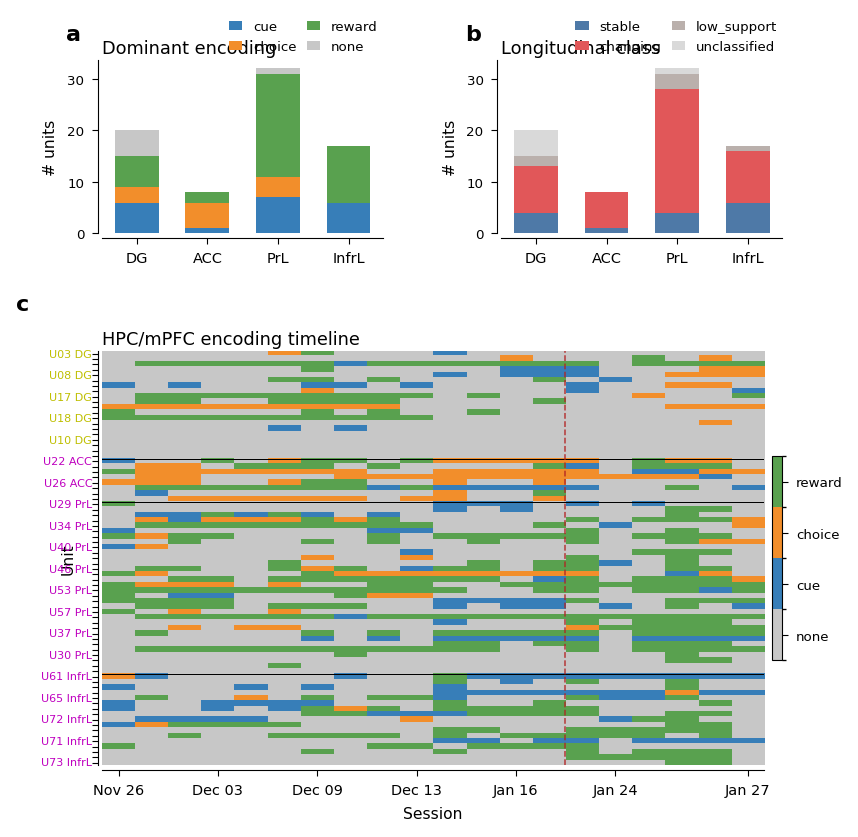

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_single_neuron_region_summary.svg
Trackwise post-cue classification: 77 units, 20 sessions (2024-11-26_16-39 to 2025-01-27_13-39), stable=15, changing=50, unclassified=6


In [ ]:
# SINGLE_NEURON_THESIS_BLOCK

NB_DIR = Path.cwd()
trackwise_nb_path = NB_DIR / 'neuron_classification_trackwise.ipynb'
if not trackwise_nb_path.exists():
    raise FileNotFoundError(trackwise_nb_path)
trackwise_nb = json.loads(trackwise_nb_path.read_text())
trackwise_outputs = trackwise_nb['cells'][7]['outputs']

CUE_INTRO_DATE_TRACK = '2024-11-26'
MIN_SIG_SESSIONS_STABLE_TRACK = 3


def _plotly_fig(output_idx):
    return trackwise_outputs[output_idx]['data']['application/vnd.plotly.v1+json']


fig_timeline_cached = _plotly_fig(6)
all_session_labels = list(fig_timeline_cached['data'][0]['x'])
y_labels_all = list(fig_timeline_cached['data'][0]['y'])
custom_all = np.asarray(fig_timeline_cached['data'][0]['customdata'], dtype=object)

session_labels = [
    sid for sid in all_session_labels
    if str(sid).split('_')[0] >= CUE_INTRO_DATE_TRACK
]

state_all = pd.DataFrame(
    custom_all,
    index=pd.Index(y_labels_all, name='label'),
    columns=all_session_labels,
).fillna('none').astype(str)
state_postcue = state_all.loc[:, session_labels]


def _label_unit(label):
    parts = [p.strip() for p in label.split('|')]
    return parts[0] if parts else str(label)


def _label_region_raw(label):
    parts = [p.strip() for p in label.split('|')]
    return parts[1] if len(parts) > 1 else 'Unknown'


def _display_region(region):
    return 'DG' if region in {'CA1', 'DG'} else region


def _compact_unit_label(label):
    unit = _label_unit(label).replace('Unit00', 'U').replace('Unit0', 'U').replace('Unit', 'U')
    return f'{unit} {_display_region(_label_region_raw(label))}'


state_order = ['none', 'cue', 'choice', 'reward']
state_to_int = {s: i for i, s in enumerate(state_order)}
state_rank = {s: i for i, s in enumerate(state_order)}


def _dominant_encoding(states):
    sig = pd.Series(states, dtype='object')
    sig = sig[sig.ne('none')]
    if sig.empty:
        return 'none'
    counts = sig.value_counts()
    top = counts[counts == counts.max()].index.tolist()
    return sorted(top, key=lambda s: state_rank.get(s, 99))[0]


def _stability_class(states):
    sig = pd.Series(states, dtype='object')
    sig = sig[sig.ne('none')]
    n_sig = int(len(sig))
    if n_sig == 0:
        return 'unclassified'
    n_unique = int(sig.nunique())
    if n_unique == 1 and n_sig >= MIN_SIG_SESSIONS_STABLE_TRACK:
        return 'stable'
    if n_unique == 1:
        return 'low_support'
    return 'changing'


unit_profile = pd.DataFrame({
    'label': state_postcue.index,
    'unit': [_label_unit(lab) for lab in state_postcue.index],
    'brain_region': [_display_region(_label_region_raw(lab)) for lab in state_postcue.index],
    'dominant_encoding': [_dominant_encoding(row) for row in state_postcue.to_numpy(dtype=object)],
    'stability_class': [_stability_class(row) for row in state_postcue.to_numpy(dtype=object)],
})
profile_by_label = unit_profile.set_index('label')

# CA1 and DG are displayed as one DG-labelled hippocampal group.
region_order = ['DG', 'ACC', 'PrL', 'InfrL']
enc_order = ['cue', 'choice', 'reward', 'none']
stab_order = ['stable', 'changing', 'low_support', 'unclassified']
enc_counts = pd.crosstab(
    unit_profile['brain_region'],
    unit_profile['dominant_encoding'],
).reindex(index=region_order, columns=enc_order, fill_value=0)
stab_counts = pd.crosstab(
    unit_profile['brain_region'],
    unit_profile['stability_class'],
).reindex(index=region_order, columns=stab_order, fill_value=0)

hpc_regions = {'DG'}
mpfc_regions = {'ACC', 'PrL', 'InfrL'}
region_to_group = {**{r: 'HPC' for r in hpc_regions}, **{r: 'mPFC' for r in mpfc_regions}}
region_group_colors = {'HPC': 'y', 'mPFC': 'm'}  # match HP/mPFC colors in the ensemble-weight plots


def _label_large_region(label):
    return region_to_group.get(_display_region(_label_region_raw(label)), 'other')


focus_labels = [
    lab for lab in state_postcue.index
    if _display_region(_label_region_raw(lab)) in region_to_group
]

region_rank = {'DG': 0, 'ACC': 1, 'PrL': 2, 'InfrL': 3}
stab_rank = {'changing': 0, 'stable': 1, 'low_support': 2, 'unclassified': 3}
focus_labels = sorted(
    focus_labels,
    key=lambda lab: (
        region_rank.get(_display_region(_label_region_raw(lab)), 99),
        stab_rank.get(profile_by_label.loc[lab, 'stability_class'], 99),
        lab,
    ),
)
custom_focus = state_postcue.loc[focus_labels].to_numpy(dtype=object)

enc_colors = {'cue': '#377eb8', 'choice': '#f28e2b', 'reward': '#59a14f', 'none': '#c7c7c7'}
stab_colors = {'stable': '#4e79a7', 'changing': '#e15759', 'low_support': '#bab0ac', 'unclassified': '#d9d9d9'}
z_display = np.vectorize(lambda v: state_to_int.get(str(v), 0))(custom_focus)

_rc = {
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 7,
    'axes.titlesize': 8, 'axes.labelsize': 7, 'xtick.labelsize': 6.5, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'axes.linewidth': 0.5, 'xtick.major.width': 0.5,
    'ytick.major.width': 0.5, 'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'xtick.direction': 'out', 'ytick.direction': 'out', 'pdf.fonttype': 42,
    'svg.fonttype': 'none', 'figure.dpi': 160,
}

with plt.rc_context(_rc):
    fig = plt.figure(figsize=(5.25, 5.65))
    gs = fig.add_gridspec(2, 2, height_ratios=[0.92, 2.20], hspace=0.40, wspace=0.42)
    ax_enc = fig.add_subplot(gs[0, 0])
    ax_stab = fig.add_subplot(gs[0, 1])
    ax_time = fig.add_subplot(gs[1, :])

    x = np.arange(len(region_order))
    bottoms = np.zeros(len(region_order))
    for enc in enc_order:
        vals = enc_counts[enc].to_numpy()
        ax_enc.bar(x, vals, bottom=bottoms, color=enc_colors[enc], width=0.62, linewidth=0, label=enc)
        bottoms += vals
    ax_enc.set_xticks(x, region_order, rotation=35, ha='right')
    ax_enc.set_ylabel('# units')
    ax_enc.set_title('Dominant encoding', loc='left', pad=3)
    ax_enc.legend(frameon=False, ncol=2, handlelength=1.0, columnspacing=0.8, loc='lower right', bbox_to_anchor=(1.0, 1.01), borderaxespad=0.0)

    bottoms = np.zeros(len(region_order))
    for stab in stab_order:
        vals = stab_counts[stab].to_numpy()
        ax_stab.bar(x, vals, bottom=bottoms, color=stab_colors[stab], width=0.62, linewidth=0, label=stab)
        bottoms += vals
    ax_stab.set_xticks(x, region_order, rotation=35, ha='right')
    ax_stab.set_ylabel('# units')
    ax_stab.set_title('Longitudinal class', loc='left', pad=3)
    ax_stab.legend(frameon=False, ncol=2, handlelength=1.0, columnspacing=0.8, loc='lower right', bbox_to_anchor=(1.0, 1.01), borderaxespad=0.0)

    cmap = mpl.colors.ListedColormap([enc_colors[s] for s in state_order])
    norm = mpl.colors.BoundaryNorm(np.arange(len(state_order) + 1) - 0.5, cmap.N)
    ax_time.imshow(z_display, aspect='auto', interpolation='nearest', cmap=cmap, norm=norm)
    ax_time.set_title('HPC/mPFC encoding timeline', loc='left', pad=3)
    ax_time.set_xlabel('Session')
    ax_time.set_ylabel('Unit')
    regions = np.array([_display_region(_label_region_raw(lab)) for lab in focus_labels])
    group_starts = np.r_[0, np.flatnonzero(regions[1:] != regions[:-1]) + 1]
    shown_rows = np.zeros(len(focus_labels), dtype=bool)
    shown_rows[::4] = True
    shown_rows[group_starts] = True
    shown_rows[-1] = True
    ax_time.set_yticks(np.arange(len(focus_labels)))
    ax_time.set_yticklabels([''] * len(focus_labels))
    for i, lab in enumerate(focus_labels):
        if not shown_rows[i]:
            continue
        ax_time.text(
            -0.015, i, _compact_unit_label(lab),
            transform=ax_time.get_yaxis_transform(), ha='right', va='center',
            fontsize=5.0, color=region_group_colors.get(_label_large_region(lab), 'black'),
            clip_on=False,
        )
    tick_idx = np.unique(np.linspace(0, len(session_labels) - 1, 7, dtype=int))
    tick_dates = pd.to_datetime([session_labels[i][:10] for i in tick_idx])
    ax_time.set_xticks(tick_idx)
    ax_time.set_xticklabels([d.strftime('%b %d') for d in tick_dates], rotation=0, ha='center')

    for yi in np.flatnonzero(regions[1:] != regions[:-1]) + 0.5:
        ax_time.axhline(yi, color='black', linewidth=0.45)
    for date_label, color in [('2025-01-23', '#b22222')]:
        hit = next((i for i, s in enumerate(session_labels) if s[:10] >= date_label), None)
        if hit is not None:
            ax_time.axvline(hit - 0.5, color=color, linewidth=0.7, linestyle='--', alpha=0.85)

    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_time, ticks=np.arange(len(state_order)), fraction=0.015, pad=0.012)
    cbar.ax.set_yticklabels(state_order)
    cbar.outline.set_linewidth(0.5)

    for label, ax in zip(['a', 'b', 'c'], [ax_enc, ax_stab, ax_time]):
        ax.text(-0.13, 1.09, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 2))
        ax.spines['bottom'].set_position(('outward', 2))

    fig.subplots_adjust(left=0.14, right=0.95, top=0.91, bottom=0.13)
    plt.show()

EXPORT_DIR = Path.cwd() / 'figures_thesis_sam'
EXPORT_DIR.mkdir(exist_ok=True)
region_svg = EXPORT_DIR / 'figure_single_neuron_region_summary.svg'
fig.savefig(region_svg, format='svg', bbox_inches='tight')
print('Wrote', region_svg)
print(
    f'Trackwise post-cue classification: {unit_profile["unit"].nunique()} units, '
    f'{len(session_labels)} sessions ({session_labels[0]} to {session_labels[-1]}), '
    f'stable={(unit_profile["stability_class"] == "stable").sum()}, '
    f'changing={(unit_profile["stability_class"] == "changing").sum()}, '
    f'unclassified={(unit_profile["stability_class"] == "unclassified").sum()}'
)

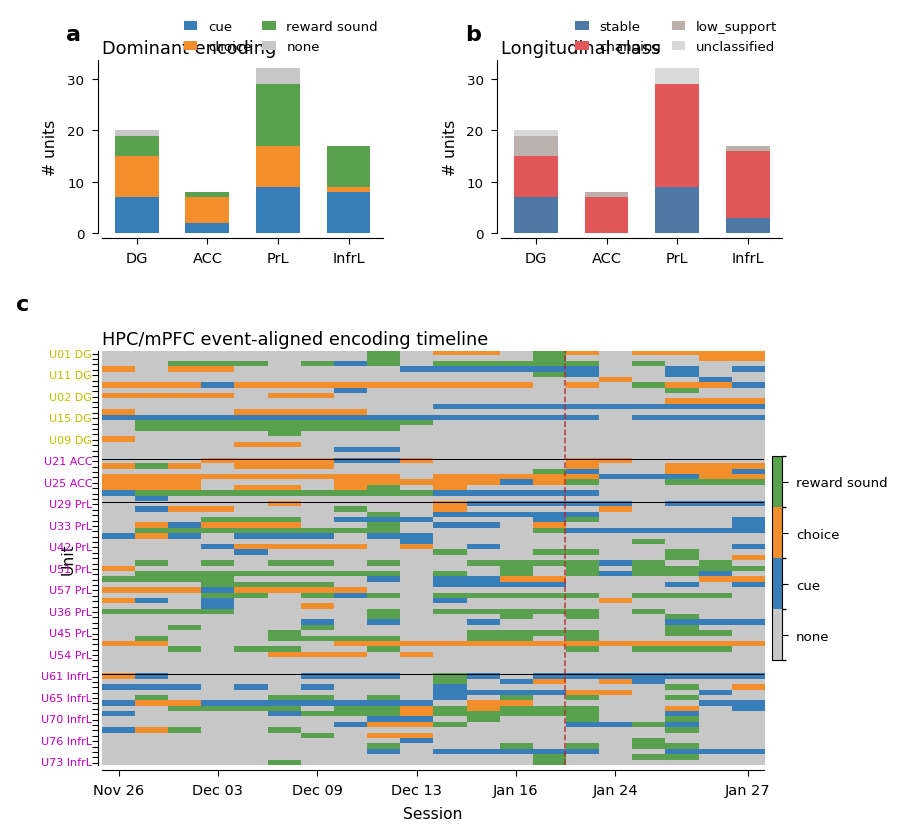

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_single_neuron_event_region_summary.svg
Event-aligned post-cue classification: 77 units, 20 sessions (2024-11-26_16-39 to 2025-01-27_13-39), stable=19, changing=48, unclassified=4


In [ ]:
# SINGLE_NEURON_THESIS_BLOCK

NB_DIR = Path.cwd()
event_nb_path = NB_DIR / 'neuron_classification_event_based.ipynb'
if not event_nb_path.exists():
    raise FileNotFoundError(event_nb_path)
event_nb = json.loads(event_nb_path.read_text())
event_outputs = event_nb['cells'][6]['outputs']

CUE_INTRO_DATE_EVENT = '2024-11-26'
MIN_SIG_SESSIONS_STABLE_EVENT = 3


def _event_plotly_fig(output_idx):
    return event_outputs[output_idx]['data']['application/vnd.plotly.v1+json']


fig_event_timeline_cached = _event_plotly_fig(6)
all_session_labels_event = list(fig_event_timeline_cached['data'][0]['x'])
y_labels_event_all = list(fig_event_timeline_cached['data'][0]['y'])
custom_event_all = np.asarray(fig_event_timeline_cached['data'][0]['customdata'], dtype=object)

session_labels_event = [
    sid for sid in all_session_labels_event
    if str(sid).split('_')[0] >= CUE_INTRO_DATE_EVENT
]

state_all_event = pd.DataFrame(
    custom_event_all,
    index=pd.Index(y_labels_event_all, name='label'),
    columns=all_session_labels_event,
).fillna('none').astype(str)
state_postcue_event = state_all_event.loc[:, session_labels_event]


def _event_label_unit(label):
    parts = [p.strip() for p in label.split('|')]
    return parts[0] if parts else str(label)


def _event_label_region(label):
    parts = [p.strip() for p in label.split('|')]
    return parts[1] if len(parts) > 1 else 'Unknown'


def _event_display_region(region):
    return 'DG' if region in {'CA1', 'DG'} else region


def _event_compact_unit_label(label):
    unit = _event_label_unit(label).replace('Unit00', 'U').replace('Unit0', 'U').replace('Unit', 'U')
    return f'{unit} {_event_display_region(_event_label_region(label))}'


state_order_event = ['none', 'cue', 'choice', 'reward_sound']
state_labels_event = {'none': 'none', 'cue': 'cue', 'choice': 'choice', 'reward_sound': 'reward sound'}
state_rank_event = {s: i for i, s in enumerate(state_order_event)}


def _event_dominant_encoding(states):
    sig = pd.Series(states, dtype='object')
    sig = sig[sig.ne('none')]
    if sig.empty:
        return 'none'
    counts = sig.value_counts()
    top = counts[counts == counts.max()].index.tolist()
    return sorted(top, key=lambda s: state_rank_event.get(s, 99))[0]


def _event_stability_class(states):
    sig = pd.Series(states, dtype='object')
    sig = sig[sig.ne('none')]
    n_sig = int(len(sig))
    if n_sig == 0:
        return 'unclassified'
    n_unique = int(sig.nunique())
    if n_unique == 1 and n_sig >= MIN_SIG_SESSIONS_STABLE_EVENT:
        return 'stable'
    if n_unique == 1:
        return 'low_support'
    return 'changing'


unit_profile_event = pd.DataFrame({
    'label': state_postcue_event.index,
    'unit': [_event_label_unit(lab) for lab in state_postcue_event.index],
    'brain_region': [_event_display_region(_event_label_region(lab)) for lab in state_postcue_event.index],
    'dominant_encoding': [_event_dominant_encoding(row) for row in state_postcue_event.to_numpy(dtype=object)],
    'stability_class': [_event_stability_class(row) for row in state_postcue_event.to_numpy(dtype=object)],
})
profile_by_label_event = unit_profile_event.set_index('label')

# Join hippocampal units into one DG-labelled display group in the bars and timeline.
region_order_event = ['DG', 'ACC', 'PrL', 'InfrL']
enc_order_event = ['cue', 'choice', 'reward_sound', 'none']
stab_order_event = ['stable', 'changing', 'low_support', 'unclassified']
enc_counts_event = pd.crosstab(
    unit_profile_event['brain_region'],
    unit_profile_event['dominant_encoding'],
).reindex(index=region_order_event, columns=enc_order_event, fill_value=0)
stab_counts_event = pd.crosstab(
    unit_profile_event['brain_region'],
    unit_profile_event['stability_class'],
).reindex(index=region_order_event, columns=stab_order_event, fill_value=0)

hpc_regions_event = {'DG'}
mpfc_regions_event = {'ACC', 'PrL', 'InfrL'}
region_to_group_event = {**{r: 'HPC' for r in hpc_regions_event}, **{r: 'mPFC' for r in mpfc_regions_event}}
region_group_colors_event = {'HPC': 'y', 'mPFC': 'm'}  # same y-label scheme as Figure 5.4


def _event_label_large_region(label):
    return region_to_group_event.get(_event_display_region(_event_label_region(label)), 'other')


focus_labels_event = [
    lab for lab in state_postcue_event.index
    if _event_display_region(_event_label_region(lab)) in region_to_group_event
]

region_rank_event = {'DG': 0, 'ACC': 1, 'PrL': 2, 'InfrL': 3}
stab_rank_event = {'changing': 0, 'stable': 1, 'low_support': 2, 'unclassified': 3}
focus_labels_event = sorted(
    focus_labels_event,
    key=lambda lab: (
        region_rank_event.get(_event_display_region(_event_label_region(lab)), 99),
        stab_rank_event.get(profile_by_label_event.loc[lab, 'stability_class'], 99),
        lab,
    ),
)
custom_event_focus = state_postcue_event.loc[focus_labels_event].to_numpy(dtype=object)

enc_colors_event = {'cue': '#377eb8', 'choice': '#f28e2b', 'reward_sound': '#59a14f', 'none': '#c7c7c7'}
stab_colors_event = {'stable': '#4e79a7', 'changing': '#e15759', 'low_support': '#bab0ac', 'unclassified': '#d9d9d9'}
state_to_int_event = {s: i for i, s in enumerate(state_order_event)}
z_event_display = np.vectorize(lambda v: state_to_int_event.get(str(v), 0))(custom_event_focus)

_rc_event = {
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 7,
    'axes.titlesize': 8, 'axes.labelsize': 7, 'xtick.labelsize': 6.5, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'axes.linewidth': 0.5, 'xtick.major.width': 0.5,
    'ytick.major.width': 0.5, 'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'xtick.direction': 'out', 'ytick.direction': 'out', 'pdf.fonttype': 42,
    'svg.fonttype': 'none', 'figure.dpi': 160,
}

with plt.rc_context(_rc_event):
    fig_event = plt.figure(figsize=(5.25, 5.65))
    gs_event = fig_event.add_gridspec(2, 2, height_ratios=[0.92, 2.20], hspace=0.40, wspace=0.42)
    ax_event_enc = fig_event.add_subplot(gs_event[0, 0])
    ax_event_stab = fig_event.add_subplot(gs_event[0, 1])
    ax_event_time = fig_event.add_subplot(gs_event[1, :])

    xpos_event = np.arange(len(region_order_event))
    bottoms_event = np.zeros(len(region_order_event))
    for enc in enc_order_event:
        vals = enc_counts_event[enc].to_numpy()
        ax_event_enc.bar(
            xpos_event, vals, bottom=bottoms_event,
            color=enc_colors_event[enc], width=0.62, linewidth=0,
            label=state_labels_event.get(enc, enc),
        )
        bottoms_event += vals
    ax_event_enc.set_xticks(xpos_event, region_order_event, rotation=35, ha='right')
    ax_event_enc.set_ylabel('# units')
    ax_event_enc.set_title('Dominant encoding', loc='left', pad=3)
    ax_event_enc.legend(frameon=False, ncol=2, handlelength=1.0, columnspacing=0.8,
                        loc='lower right', bbox_to_anchor=(1.0, 1.01), borderaxespad=0.0)

    bottoms_event = np.zeros(len(region_order_event))
    for stab in stab_order_event:
        vals = stab_counts_event[stab].to_numpy()
        ax_event_stab.bar(xpos_event, vals, bottom=bottoms_event,
                          color=stab_colors_event[stab], width=0.62, linewidth=0,
                          label=stab)
        bottoms_event += vals
    ax_event_stab.set_xticks(xpos_event, region_order_event, rotation=35, ha='right')
    ax_event_stab.set_ylabel('# units')
    ax_event_stab.set_title('Longitudinal class', loc='left', pad=3)
    ax_event_stab.legend(frameon=False, ncol=2, handlelength=1.0, columnspacing=0.8,
                         loc='lower right', bbox_to_anchor=(1.0, 1.01), borderaxespad=0.0)

    cmap_event = mpl.colors.ListedColormap([enc_colors_event[s] for s in state_order_event])
    norm_event = mpl.colors.BoundaryNorm(np.arange(len(state_order_event) + 1) - 0.5, cmap_event.N)
    ax_event_time.imshow(z_event_display, aspect='auto', interpolation='nearest', cmap=cmap_event, norm=norm_event)
    ax_event_time.set_title('HPC/mPFC event-aligned encoding timeline', loc='left', pad=3)
    ax_event_time.set_xlabel('Session')
    ax_event_time.set_ylabel('Unit')
    regions_event = np.array([_event_display_region(_event_label_region(lab)) for lab in focus_labels_event])
    group_starts_event = np.r_[0, np.flatnonzero(regions_event[1:] != regions_event[:-1]) + 1]
    shown_rows_event = np.zeros(len(focus_labels_event), dtype=bool)
    shown_rows_event[::4] = True
    shown_rows_event[group_starts_event] = True
    shown_rows_event[-1] = True
    ax_event_time.set_yticks(np.arange(len(focus_labels_event)))
    ax_event_time.set_yticklabels([''] * len(focus_labels_event))
    for i, lab in enumerate(focus_labels_event):
        if not shown_rows_event[i]:
            continue
        ax_event_time.text(
            -0.015, i, _event_compact_unit_label(lab),
            transform=ax_event_time.get_yaxis_transform(), ha='right', va='center',
            fontsize=5.0, color=region_group_colors_event.get(_event_label_large_region(lab), 'black'),
            clip_on=False,
        )
    tick_idx_event = np.unique(np.linspace(0, len(session_labels_event) - 1, 7, dtype=int))
    tick_dates_event = pd.to_datetime([session_labels_event[i][:10] for i in tick_idx_event])
    ax_event_time.set_xticks(tick_idx_event)
    ax_event_time.set_xticklabels([d.strftime('%b %d') for d in tick_dates_event], rotation=0, ha='center')

    for yi in np.flatnonzero(regions_event[1:] != regions_event[:-1]) + 0.5:
        ax_event_time.axhline(yi, color='black', linewidth=0.45)
    for date_label, color in [('2025-01-23', '#b22222')]:
        hit = next((i for i, s in enumerate(session_labels_event) if s[:10] >= date_label), None)
        if hit is not None:
            ax_event_time.axvline(hit - 0.5, color=color, linewidth=0.7, linestyle='--', alpha=0.85)

    cbar_event = fig_event.colorbar(
        mpl.cm.ScalarMappable(norm=norm_event, cmap=cmap_event),
        ax=ax_event_time, ticks=np.arange(len(state_order_event)), fraction=0.015, pad=0.012,
    )
    cbar_event.ax.set_yticklabels([state_labels_event[s] for s in state_order_event])
    cbar_event.outline.set_linewidth(0.5)

    for label, ax in zip(['a', 'b', 'c'], [ax_event_enc, ax_event_stab, ax_event_time]):
        ax.text(-0.13, 1.09, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 2))
        ax.spines['bottom'].set_position(('outward', 2))

    fig_event.subplots_adjust(left=0.14, right=0.95, top=0.91, bottom=0.13)
    plt.show()

EXPORT_DIR = Path.cwd() / 'figures_thesis_sam'
EXPORT_DIR.mkdir(exist_ok=True)
event_region_svg = EXPORT_DIR / 'figure_single_neuron_event_region_summary.svg'
fig_event.savefig(event_region_svg, format='svg', bbox_inches='tight')
print('Wrote', event_region_svg)
print(
    f'Event-aligned post-cue classification: {unit_profile_event["unit"].nunique()} units, '
    f'{len(session_labels_event)} sessions ({session_labels_event[0]} to {session_labels_event[-1]}), '
    f'stable={(unit_profile_event["stability_class"] == "stable").sum()}, '
    f'changing={(unit_profile_event["stability_class"] == "changing").sum()}, '
    f'unclassified={(unit_profile_event["stability_class"] == "unclassified").sum()}'
)

Figure 5.4 summarizes the single-neuron classification across regions and sessions. The bar plots show that ACC units are dominated by the choice/reward-approach category, but the stability panel and the mPFC timeline show that this is not a simple population of permanently labelled choice cells. Most ACC units switch between significant labels across the recording period, consistent with longitudinal representational change and recording drift rather than a fixed single-neuron code.


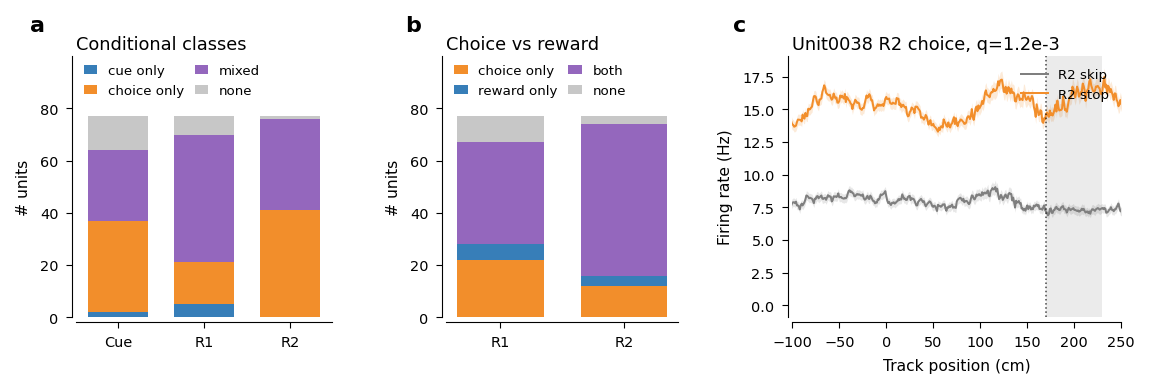

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_single_neuron_selectivity.svg
Cached significant conditional units: {('cue_zone', 'choice'): 62, ('cue_zone', 'cue'): 29, ('reward1_zone', 'choice'): 65, ('reward1_zone', 'cue'): 54, ('reward2_zone', 'choice'): 76, ('reward2_zone', 'cue'): 35}
Cached reward-zone choice-vs-reward summary:
         choice_not_reward  reward_not_choice  both  none
reward1                 22                  6    39    10
reward2                 12                  4    58     3


In [ ]:
# SINGLE_NEURON_THESIS_BLOCK

expected_sig = {
    ('cue_zone', 'choice'): 62, ('cue_zone', 'cue'): 29,
    ('reward1_zone', 'choice'): 65, ('reward1_zone', 'cue'): 54,
    ('reward2_zone', 'choice'): 76, ('reward2_zone', 'cue'): 35,
}

class_counts = pd.DataFrame(
    {
        'cue_only': [2, 5, 0],
        'choice_only': [35, 16, 41],
        'mixed': [27, 49, 35],
        'none': [13, 7, 1],
    },
    index=['cue_zone', 'reward1_zone', 'reward2_zone'],
)
zone_counts = pd.DataFrame(
    {
        'choice_not_reward': [22, 12],
        'reward_not_choice': [6, 4],
        'both': [39, 58],
        'none': [10, 3],
    },
    index=['reward1', 'reward2'],
)

fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)

ex_unit = 'Unit0038'
x = fr_track.reset_index()[['from_position_bin', 'cue', 'choice_R2', ex_unit]].copy()
x = x[x['cue'].isin([1, 2])].copy()
if not pd.api.types.is_bool_dtype(x['choice_R2']):
    x['choice_R2'] = pd.to_numeric(x['choice_R2'], errors='coerce').fillna(0).astype(bool)
else:
    x['choice_R2'] = x['choice_R2'].fillna(False).astype(bool)

zones = {'reward2_zone': (170, 230)}
class_order = ['cue_only', 'choice_only', 'mixed', 'none']
class_colors = {'cue_only': '#377eb8', 'choice_only': '#f28e2b', 'mixed': '#9467bd', 'none': '#c7c7c7'}
reward_order = ['choice_not_reward', 'reward_not_choice', 'both', 'none']
reward_colors = {'choice_not_reward': '#f28e2b', 'reward_not_choice': '#377eb8', 'both': '#9467bd', 'none': '#c7c7c7'}
reward_labels = {'choice_not_reward': 'choice only', 'reward_not_choice': 'reward only', 'both': 'both', 'none': 'none'}

_rc = {
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7, 'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5, 'legend.fontsize': 6, 'axes.linewidth': 0.5,
    'xtick.major.width': 0.5, 'ytick.major.width': 0.5, 'xtick.major.size': 2.5,
    'ytick.major.size': 2.5, 'xtick.direction': 'out', 'ytick.direction': 'out',
    'lines.linewidth': 0.9, 'pdf.fonttype': 42, 'svg.fonttype': 'none', 'figure.dpi': 160,
}

with plt.rc_context(_rc):
    fig_sel, axes = plt.subplots(1, 3, figsize=(7.1, 2.55), gridspec_kw={'width_ratios': [1.05, 0.95, 1.35], 'wspace': 0.42})
    ax0, ax1, ax2 = axes

    xpos = np.arange(3)
    bottoms = np.zeros(3)
    for cls in class_order:
        vals = class_counts[cls].to_numpy()
        ax0.bar(xpos, vals, bottom=bottoms, color=class_colors[cls], width=0.70, linewidth=0, label=cls.replace('_', ' '))
        bottoms += vals
    ax0.set_xticks(xpos, ['Cue', 'R1', 'R2'])
    ax0.set_ylabel('# units')
    ax0.set_ylim(0, 100)
    ax0.set_yticks([0, 20, 40, 60, 80])
    ax0.set_title('Conditional classes', loc='left', pad=3)
    ax0.legend(frameon=False, handlelength=1.0, loc='upper left', ncol=2, columnspacing=0.8, borderaxespad=0.2)

    xpos2 = np.arange(2)
    bottoms = np.zeros(2)
    for key in reward_order:
        vals = zone_counts[key].to_numpy()
        ax1.bar(xpos2, vals, bottom=bottoms, color=reward_colors[key], width=0.70, linewidth=0, label=reward_labels[key])
        bottoms += vals
    ax1.set_xticks(xpos2, ['R1', 'R2'])
    ax1.set_ylabel('# units')
    ax1.set_ylim(0, 100)
    ax1.set_yticks([0, 20, 40, 60, 80])
    ax1.set_title('Choice vs reward', loc='left', pad=3)
    ax1.legend(frameon=False, handlelength=1.0, loc='upper left', ncol=2, columnspacing=0.8, borderaxespad=0.2)

    for cval, color, label in [(False, '#7f7f7f', 'R2 skip'), (True, '#f28e2b', 'R2 stop')]:
        g = x.loc[x['choice_R2'].eq(cval)].groupby('from_position_bin')[ex_unit]
        m = g.mean().sort_index()
        sem = g.sem(ddof=1).reindex(m.index).fillna(0)
        ax2.plot(m.index.to_numpy(dtype=float), m.to_numpy(dtype=float), color=color, label=label)
        ax2.fill_between(
            m.index.to_numpy(dtype=float),
            (m - sem).to_numpy(dtype=float),
            (m + sem).to_numpy(dtype=float),
            color=color, alpha=0.18, linewidth=0,
        )
    ax2.axvspan(*zones['reward2_zone'], color='black', alpha=0.08, linewidth=0)
    ax2.axvline(170, color='black', linestyle=':', linewidth=0.7, alpha=0.7)
    ax2.set_xlim(-100, 250)
    ax2.set_xlabel('Track position (cm)')
    ax2.set_ylabel('Firing rate (Hz)')
    ax2.set_title(f'{ex_unit} R2 choice, q=1.2e-3', loc='left', pad=3)
    ax2.legend(frameon=False, loc='upper right')

    for label, ax in zip(['a', 'b', 'c'], axes):
        ax.text(-0.18, 1.08, label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 2))
        ax.spines['bottom'].set_position(('outward', 2))

    fig_sel.subplots_adjust(left=0.07, right=0.99, top=0.84, bottom=0.20)
    plt.show()

EXPORT_DIR = Path.cwd() / 'figures_thesis_sam'
EXPORT_DIR.mkdir(exist_ok=True)
selectivity_svg = EXPORT_DIR / 'figure_single_neuron_selectivity.svg'
fig_sel.savefig(selectivity_svg, format='svg', bbox_inches='tight')
print('Wrote', selectivity_svg)
print('Cached significant conditional units:', expected_sig)
print('Cached reward-zone choice-vs-reward summary:')
print(zone_counts.to_string())

Figure 5.5 tests whether significant single-neuron effects are selective. Choice encoding is common even after cue identity is controlled: 62 units were significant for choice in the cue zone, 65 in R1, and 76 in R2. Cue effects were also significant, but pure cue-only units were rare compared with choice-only or mixed units. In the reward zones, many units remained significant for the stop/skip choice after reward was controlled, while reward-only units were less common. Thus, statistical significance alone should not be interpreted as clean predictive coding: many neurons carry mixed task variables, and the most robust single-neuron signal is action/choice related.


Figure 5.6 adds an event-aligned control analysis for the single-neuron results. Unlike Figure 5.5, which uses track-position zone averages, this analysis extracts firing rates directly around event timestamps in a -150 to +150 ms window. Reward responses are tested separately for R1 and R2 by comparing actual rewarded trials aligned to the local reward sound with no-reward trials pseudo-aligned to the local reward-zone entry plus the median plausible reward-sound delay. This pseudo-alignment is necessary because no actual reward sound occurs on no-reward trials. Choice responses are tested separately at R1 and R2 reward-zone entry by a plain local stop-versus-skip split; this panel is therefore an event-aligned stop/skip comparison, not a cue- or reward-controlled selectivity test.

## Discussion: relation to predictive coding work

Yaghoubi et al. (2026) argue that hippocampal reward representations become predictive over learning, with reward-tuned cells progressively representing earlier task features. The present analysis was designed to test a related idea in a multi-region rat recording, but the result is more conservative. There are significant single-neuron cue and choice effects, and ensemble-level decoders recover cue and choice information in specific sessions. However, the single-neuron classifications do not show a clean, stable hippocampal reward-to-cue shift. Instead, ACC and mPFC units are dominated by choice/reward-approach labels and frequently change their preferred encoding across sessions.

This pattern fits better with medial prefrontal and ACC accounts of action selection, behavioral flexibility, and value-guided control than with a direct reproduction of hippocampal predictive reward coding. It also agrees with the caution raised by longitudinal neural recordings: individual neurons can drift or change task tuning while population-level information remains behaviorally meaningful. The one-animal scope and the unstable behavioral phases therefore make the single-neuron result useful mainly as mechanistic support for the ensemble analysis, not as standalone proof of predictive coding.

The selectivity analyses should therefore be interpreted as an additional control rather than as an exact replication of Yaghoubi et al. From the accessible Nature abstract and page metadata, their single-cell claim centers on tracking reward-tuned hippocampal neurons and a learning-related shift toward pre-reward task features. The conditional cue-vs-choice and choice-vs-reward tests used here ask a related but distinct question: whether significance survives when competing task variables are explicitly controlled.

References used for this framing: Yaghoubi et al. (2026), Nature, published 14 January 2026 with an author correction listed on 12 May 2026, https://doi.org/10.1038/s41586-025-09958-0; Stachenfeld et al. (2017), Nature Neuroscience, https://doi.org/10.1038/nn.4650; Sun et al. (2025), Nature, https://doi.org/10.1038/s41586-024-08548-w; Euston et al. (2012), Neuron, https://doi.org/10.1016/j.neuron.2012.12.002; Driscoll et al. (2017), Cell, https://doi.org/10.1016/j.cell.2017.07.021; Kolling et al. (2016), Nature Neuroscience, https://doi.org/10.1038/nn.4382.


## Per-session bin-effect heatmap (skip − stop in R1)

Session-by-session, bin-by-bin difference in Ens 012 activation between
trials where the animal skipped R1 versus stopped at R1, computed
separately for the three task intervals (cue entry, R1 entry, R2 entry).
Each cell is a Welch two-sample mean difference (b − a = skip − stop),
white dots mark per-(session,interval) BH-FDR q<0.05 bins (3-bin sliding
window), and the red horizontal line marks the cue-reward reversal
(2025-01-23). Sessions are restricted to the same set used in the
ensemble-encoding heatmap (n_trials ≥ 10 in the decoder runs) and the
y-axis is reversed (oldest at the top) to match the other figures.


In [ ]:
BIN_EFFECT_ASSEMBLY = 'Assembly007'
BIN_EFFECT_INTERVALS = ['cue_entry_interval', 'R1_entry_interval', 'R2_entry_interval']
BIN_EFFECT_INTERVAL_LABEL = {
    'cue_entry_interval': 'Cue entry',
    'R1_entry_interval': 'R1 entry',
    'R2_entry_interval': 'R2 entry',
}
BIN_EFFECT_MIN_TRIALS = 10
BIN_EFFECT_REVERSAL_DATE = datetime(2025, 1, 23)
BIN_EFFECT_VMAX_PCTL = 95
BIN_EFFECT_WINDOW_HALF = 1   # +-1 bin sliding window (3-bin)


def _be_df_with_cols(df):
    out = df.copy()
    idx_names = list(out.index.names) if isinstance(out.index, pd.MultiIndex) else [out.index.name]
    if any((n is not None) and (n not in out.columns) for n in idx_names):
        out = out.reset_index()
    else:
        out = out.reset_index(drop=True)
    return out


def _be_prepare_binwise(t0_ens, assembly_col, intervals):
    df = _be_df_with_cols(t0_ens)
    keep = ['session_id', 'trial_id', 'cue', 'choice_R1', 'choice_R2', 'interval_name',
            'from_ephys_timestamp', 'to_ephys_timestamp', assembly_col]
    opt = [c for c in ['entry_id'] if c in df.columns]
    df = df[keep + opt].copy()
    df = df[df['interval_name'].isin(intervals)].copy()
    df = df[df[assembly_col].notna()].copy()
    df = df[df['choice_R1'].isin([True, False])].copy()
    df['r1_action'] = np.where(df['choice_R1'].eq(True), 'stop_R1', 'skip_R1')
    df['assembly_value'] = df[assembly_col].astype(float)
    sort_cols = ['session_id', 'trial_id', 'interval_name',
                 'from_ephys_timestamp', 'to_ephys_timestamp']
    if 'entry_id' in df.columns:
        sort_cols.append('entry_id')
    df = df.sort_values(sort_cols).reset_index(drop=True)
    g = ['session_id', 'trial_id', 'interval_name']
    df['bin_idx'] = df.groupby(g).cumcount().astype(int)
    df['first_from'] = df.groupby(g)['from_ephys_timestamp'].transform('min').astype(float)
    df['bin_center_us'] = (df['from_ephys_timestamp'].astype(float)
                            + df['to_ephys_timestamp'].astype(float)) / 2.0
    df['bin_center_ms'] = (df['bin_center_us'] - df['first_from']) / 1000.0
    return df


def _be_compare(window, group_col, a, b, value_col='assembly_value'):
    av = window.loc[window[group_col] == a, value_col].dropna().to_numpy(float)
    bv = window.loc[window[group_col] == b, value_col].dropna().to_numpy(float)
    if len(av) < 2 or len(bv) < 2:
        return dict(n_a=len(av), n_b=len(bv), diff_b_minus_a=np.nan,
                    welch_p_two_sided=np.nan)
    _t, p = stats.ttest_ind(bv, av, equal_var=False)
    return dict(n_a=len(av), n_b=len(bv),
                diff_b_minus_a=float(bv.mean() - av.mean()),
                welch_p_two_sided=float(p))


def _be_bh_fdr(p):
    p = np.asarray(p, float); q = np.full(p.shape, np.nan); v = np.isfinite(p)
    if not v.any(): return q
    pv = p[v]; o = np.argsort(pv); r = pv[o]
    sc = r.size / np.arange(1, r.size + 1)
    qr = np.clip(np.minimum.accumulate((r * sc)[::-1])[::-1], 0, 1)
    qq = np.empty_like(pv); qq[o] = qr; q[v] = qq; return q


def _be_summarize_by_session(binwise_df, intervals, window_half):
    rows = []
    for (sid, iv), sub in binwise_df.groupby(['session_id', 'interval_name'],
                                              sort=True, dropna=False):
        if iv not in intervals:
            continue
        bin_ids = sorted(pd.Series(sub['bin_idx'].dropna().unique()).astype(int).tolist())
        for bi in bin_ids:
            cen = sub.loc[sub['bin_idx'] == bi]
            win = sub.loc[sub['bin_idx'].between(bi - window_half, bi + window_half)]
            r = _be_compare(win, 'r1_action', 'stop_R1', 'skip_R1')
            rows.append({
                'session_id': sid, 'interval_name': iv, 'bin_idx': int(bi),
                'bin_center_ms': float(cen['bin_center_ms'].median())
                                  if cen['bin_center_ms'].notna().any() else np.nan,
                **r,
            })
    out = pd.DataFrame(rows)
    out['welch_fdr_q'] = np.nan
    for _, idx in out.groupby(['session_id', 'interval_name'], dropna=False).groups.items():
        sub = out.loc[idx]
        out.loc[idx, 'welch_fdr_q'] = _be_bh_fdr(sub['welch_p_two_sided'].to_numpy(float))
    return out


def _be_sessions_from_runs(min_trials=BIN_EFFECT_MIN_TRIALS):
    base = next((p for p in ('interval_session_decoding_runs',
                              'scripted_plotting/animal_6_analysis/interval_session_decoding_runs')
                  if os.path.isdir(p)), None)
    if not base:
        raise FileNotFoundError('interval_session_decoding_runs not found')
    sids = set()
    for rd in sorted(glob.glob(os.path.join(base, 'log_reg_5k_3intervals_Assembly*'))):
        p = os.path.join(rd, 'results.parquet')
        p = p if os.path.exists(p) else os.path.join(rd, 'results.csv')
        if not os.path.exists(p):
            continue
        d = pd.read_parquet(p) if p.endswith('parquet') else pd.read_csv(p)
        d['n_trials'] = pd.to_numeric(d['n_trials'], errors='coerce')
        sids.update(d.loc[d['n_trials'] >= min_trials, 'session_id'].astype(str).unique())
    return sorted(sids)


_be_session_names = session_names

_be_t0_ens = analytics.get_analytics('EnsembleT0Projection',
                                      session_names=_be_session_names)

_be_all_bins = _be_prepare_binwise(_be_t0_ens, BIN_EFFECT_ASSEMBLY, BIN_EFFECT_INTERVALS)
_be_session_bin_df = _be_summarize_by_session(_be_all_bins, BIN_EFFECT_INTERVALS,
                                               window_half=BIN_EFFECT_WINDOW_HALF)

_be_valid_sids = _be_sessions_from_runs(BIN_EFFECT_MIN_TRIALS)
_be_session_bin_df = _be_session_bin_df[
    _be_session_bin_df['session_id'].astype(str).isin(_be_valid_sids)
].copy()

_be_all_sessions = sorted(_be_session_bin_df['session_id'].astype(str).unique())
_be_session_labels = [s[:10] for s in _be_all_sessions]

_be_vmax_cand = []
for iv in BIN_EFFECT_INTERVALS:
    sub = _be_session_bin_df.loc[
        (_be_session_bin_df['interval_name'] == iv)
        & _be_session_bin_df['diff_b_minus_a'].notna()
    ]
    _be_vmax_cand.append(np.nanpercentile(np.abs(sub['diff_b_minus_a']),
                                          BIN_EFFECT_VMAX_PCTL))
_be_vmax = max(_be_vmax_cand) if _be_vmax_cand else 1.0
if not np.isfinite(_be_vmax) or _be_vmax <= 0:
    _be_vmax = 1.0


def _be_date(s):
    try:
        return datetime.strptime(s[:16], '%Y-%m-%d_%H-%M')
    except Exception:
        return None


_be_reversal_idx = next((i for i, s in enumerate(_be_all_sessions)
                          if _be_date(s) and _be_date(s) >= BIN_EFFECT_REVERSAL_DATE),
                         None)

fig_bin_effect = make_subplots(
    rows=3, cols=1,
    shared_xaxes=False, shared_yaxes=False,
    vertical_spacing=0.07,
    subplot_titles=[BIN_EFFECT_INTERVAL_LABEL[iv] for iv in BIN_EFFECT_INTERVALS],
)

for ri, iv in enumerate(BIN_EFFECT_INTERVALS, start=1):
    sub = _be_session_bin_df.loc[_be_session_bin_df['interval_name'] == iv].copy()
    sub['bin_center_ms_plot'] = sub['bin_center_ms'].round(1)
    heat = (sub.pivot_table(index='session_id', columns='bin_center_ms_plot',
                            values='diff_b_minus_a', aggfunc='mean')
              .reindex(index=_be_all_sessions)
              .sort_index(axis=1))
    x_vals = heat.columns.to_numpy(float)
    z_vals = heat.to_numpy(float)
    fig_bin_effect.add_trace(go.Heatmap(
        x=x_vals, y=_be_all_sessions, z=z_vals, coloraxis='coloraxis',
        xgap=0, ygap=0,
        hovertemplate=(BIN_EFFECT_INTERVAL_LABEL[iv]
                       + '<br>t=%{x:.0f} ms<br>session=%{y}'
                         '<br>skip − stop=%{z:.3f}<extra></extra>'),
    ), row=ri, col=1)

    sig = sub.loc[sub['welch_fdr_q'] < 0.05]
    fig_bin_effect.add_trace(go.Scatter(
        x=sig['bin_center_ms_plot'], y=sig['session_id'],
        mode='markers',
        marker=dict(size=2.8, color='white',
                     line=dict(color='black', width=0.5)),
        showlegend=(ri == 1), name='Welch FDR q<0.05',
        hovertemplate='q<0.05<extra></extra>',
    ), row=ri, col=1)

    if _be_reversal_idx is not None:
        sfx = '' if ri == 1 else str(ri)
        fig_bin_effect.add_shape(
            type='line', x0=0, x1=1, xref=f'x{sfx} domain',
            y0=_be_reversal_idx - 0.5, y1=_be_reversal_idx - 0.5,
            yref=f'y{sfx}', line=dict(color='red', width=1.2),
        )

BIN_EFFECT_FIG_W = 560
BIN_EFFECT_FIG_H = 640
fig_bin_effect.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=10, color='black'),
    coloraxis=dict(
        colorscale=[[0.0, '#0072B2'], [0.5, '#f7f7f7'], [1.0, '#D55E00']],  # stop -> white -> skip (Okabe-Ito choice palette, R1_CHOICE_CMAP)
        cmin=-_be_vmax, cmax=_be_vmax,
        colorbar=dict(title=dict(text=f'skip − stop<br>({BIN_EFFECT_ASSEMBLY.replace("Assembly", "Ens ")})', font=dict(size=9)),
                      tickfont=dict(size=8), thickness=10, len=0.55, x=1.02),
    ),
    legend=dict(font=dict(size=8), orientation='h',
                yanchor='top', y=-0.08, x=0.5, xanchor='center'),
    width=BIN_EFFECT_FIG_W, height=BIN_EFFECT_FIG_H,
    margin=dict(l=80, r=90, t=58, b=70),
    paper_bgcolor='white', plot_bgcolor='white',
    title=dict(
        text=f'{BIN_EFFECT_ASSEMBLY.replace("Assembly", "Ens ")}'
             ': per-session bin effect (skip − stop, R1)',
        x=0.02, xanchor='left', font=dict(size=12, color='black'),
    ),
)
fig_bin_effect.update_xaxes(
    tickfont=dict(size=8), title_font=dict(size=9),
    showline=True, linewidth=0.8, linecolor='black', mirror=True,
)
fig_bin_effect.update_xaxes(title_text='time from interval start (ms)', row=3, col=1)
fig_bin_effect.update_yaxes(
    tickfont=dict(size=7), autorange='reversed',
    tickmode='array', tickvals=_be_all_sessions, ticktext=_be_session_labels,
    showline=True, linewidth=0.8, linecolor='black', mirror=True,
)
for ann in fig_bin_effect.layout.annotations:
    ann.font = dict(size=10, color='black')
fig_bin_effect.show()

_be_svg = os.path.join(os.getcwd(), 'figures_thesis_sam',
                       'figure_bin_effect_skip_minus_stop_R1.svg')
os.makedirs(os.path.dirname(_be_svg), exist_ok=True)
fig_bin_effect.write_image(_be_svg, format='svg',
                            width=BIN_EFFECT_FIG_W, height=BIN_EFFECT_FIG_H)
print('Wrote', _be_svg)

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_bin_effect_skip_minus_stop_R1.svg


### Per-session effect size (diverging bars)

Same per-session skip − stop effect as the line plot above, drawn as
horizontal bars anchored at zero. Bar length is the effect magnitude
and the colour is the sign (orange = skip > stop, blue = stop > skip).
Solid saturated bars with a black edge are BH-FDR q<0.05; faint bars
are non-significant. This view makes per-session direction and
magnitude impossible to miss.


## Within-interval cue progression

Mean Ens 007 trajectory across the three task intervals, split by cue.
For each interval, the per-bin mean is computed across trials in each
cue group (Cue 1 vs Cue 2), with the shaded band showing the standard error of the mean (± SEM) across trials in that bin. Red diamonds beneath each
panel mark bins where the two cue groups differ (per-bin Welch t,
BH-FDR q<0.05 within each interval). The `TRIAL_SUBSET`
toggle at the top of the cell switches between **expert trials only**
(animal followed the cue: cue1 → stop R1, cue2 → skip R1 + stop R2) and
**all trials**.


In [ ]:
TRIAL_SUBSET = 'all'             # <-- 'expert' or 'all'
PROG_ASSEMBLY = 'Assembly023'   # <-- any Assembly### in the t0 ens table
PROG_SESSIONS = None             # None -> same n_trials>=10 set as the ensemble-encoding heatmap


assert TRIAL_SUBSET in ('expert', 'all'), \
    "TRIAL_SUBSET must be 'expert' or 'all'"

CUE1_COLOR = '#e98800'   # cue 1 (orange)
CUE2_COLOR = '#bc00e9'   # cue 2 (purple)
SIG_COLOR  = '#d62828'

# t0 (alignment event) position within each interval, in ms from interval start.
# Equals n_bins_left * 40 ms (see analytics_processing/integr_analytics.py).
T0_OFFSET_MS = {
    'cue_entry_interval': 120,   # cue becomes visible
    'R1_entry_interval':  400,   # animal enters R1 zone
    'R2_entry_interval':  400,   # animal enters R2 zone
}

_prog_bins = (
    _be_all_bins.copy() if PROG_ASSEMBLY == BIN_EFFECT_ASSEMBLY
    else _be_prepare_binwise(_be_t0_ens, PROG_ASSEMBLY, BIN_EFFECT_INTERVALS)
)
_prog_bins['cue_label'] = pd.to_numeric(_prog_bins['cue'], errors='coerce').map(
    {1.0: 'cue1', 2.0: 'cue2'}
)
_prog_bins = _prog_bins[_prog_bins['cue_label'].notna()].copy()
_prog_session_set = (
    set(map(str, PROG_SESSIONS)) if PROG_SESSIONS is not None
    else set(_be_all_sessions)
)
_prog_bins = _prog_bins[
    _prog_bins['session_id'].astype(str).isin(_prog_session_set)
].copy()

if TRIAL_SUBSET == 'expert':
    _expert_mask = (
        (_prog_bins['cue'].astype(float) == 1.0)
        & _prog_bins['choice_R1'].eq(True)
        & _prog_bins['choice_R2'].eq(False)
    ) | (
        (_prog_bins['cue'].astype(float) == 2.0)
        & _prog_bins['choice_R1'].eq(False)
        & _prog_bins['choice_R2'].eq(True)
    )
    _prog_bins = _prog_bins.loc[_expert_mask].copy()

_prog_traj = (
    _prog_bins.groupby(['interval_name', 'bin_idx', 'cue_label'],
                        dropna=False)['assembly_value']
    .agg(mean='mean', std='std', n='count').reset_index()
)
_prog_traj['sem'] = _prog_traj['std'] / np.sqrt(_prog_traj['n'].where(_prog_traj['n'] > 0, np.nan))
_prog_centers = (
    _prog_bins.groupby(['interval_name', 'bin_idx'], dropna=False)['bin_center_ms']
    .median().reset_index()
)
_prog_traj = _prog_traj.merge(_prog_centers, on=['interval_name', 'bin_idx'], how='left')


def _prog_binwise(bins_df, intervals, window_half=0):
    rows = []
    for iv in intervals:
        sub = bins_df[bins_df['interval_name'] == iv]
        bin_ids = sorted(pd.Series(sub['bin_idx'].dropna().unique()).astype(int).tolist())
        for bi in bin_ids:
            win = sub[sub['bin_idx'].between(bi - window_half, bi + window_half)]
            r = _be_compare(win, 'cue_label', 'cue1', 'cue2')
            cen = sub[sub['bin_idx'] == bi]
            rows.append({
                'interval_name': iv, 'bin_idx': int(bi),
                'bin_center_ms': float(cen['bin_center_ms'].median())
                                  if cen['bin_center_ms'].notna().any() else np.nan,
                **r,
            })
    out = pd.DataFrame(rows)
    out['welch_fdr_q'] = np.nan
    for _, idx in out.groupby('interval_name', dropna=False).groups.items():
        out.loc[idx, 'welch_fdr_q'] = _be_bh_fdr(
            out.loc[idx, 'welch_p_two_sided'].to_numpy(float)
        )
    return out


_prog_binwise_df = _prog_binwise(_prog_bins, BIN_EFFECT_INTERVALS, window_half=0)
_prog_n_per_cue = (
    _prog_bins[['session_id', 'trial_id', 'interval_name', 'cue_label']]
    .drop_duplicates()
    .groupby(['interval_name', 'cue_label']).size()
    .rename('n_trials').reset_index()
)

fig_prog = make_subplots(
    rows=3, cols=1, shared_xaxes=False, shared_yaxes=False,
    vertical_spacing=0.10,
    subplot_titles=[BIN_EFFECT_INTERVAL_LABEL[iv] for iv in BIN_EFFECT_INTERVALS],
)

CUE_COLOURS = {'cue1': CUE1_COLOR, 'cue2': CUE2_COLOR}
CUE_LABEL = {'cue1': 'Cue 1', 'cue2': 'Cue 2'}

for ri, iv in enumerate(BIN_EFFECT_INTERVALS, start=1):
    sub_traj = _prog_traj[_prog_traj['interval_name'] == iv]
    sub_sig = _prog_binwise_df[_prog_binwise_df['interval_name'] == iv].sort_values('bin_idx')

    y_lo, y_hi = [], []
    for cue in ['cue1', 'cue2']:
        g = sub_traj[sub_traj['cue_label'] == cue].sort_values('bin_idx')
        mean = g['mean'].to_numpy(float)
        sem = g['sem'].fillna(0).to_numpy(float)
        if np.isfinite(mean).any():
            y_lo.append(float(np.nanmin(mean - sem)))
            y_hi.append(float(np.nanmax(mean + sem)))

    if y_lo and y_hi:
        y_min, y_max = min(y_lo), max(y_hi)
    else:
        y_min, y_max = -0.5, 0.5
    y_span = max(y_max - y_min, 1e-6)
    y_sig = y_min - 0.10 * y_span
    y_range = [y_sig - 0.04 * y_span, y_max + 0.08 * y_span]

    for cue in ['cue1', 'cue2']:
        g = sub_traj[sub_traj['cue_label'] == cue].sort_values('bin_center_ms')
        x = g['bin_center_ms'].to_numpy(float)
        mean = g['mean'].to_numpy(float)
        sem = g['sem'].fillna(0).to_numpy(float)
        col = CUE_COLOURS[cue]
        fig_prog.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([mean + sem, (mean - sem)[::-1]]),
            fill='toself',
            fillcolor=f"rgba({int(col[1:3],16)},{int(col[3:5],16)},{int(col[5:7],16)},0.20)",
            line=dict(width=0), hoverinfo='skip',
            showlegend=False,
        ), row=ri, col=1)
        n_cue = int(_prog_n_per_cue.query(
            "interval_name == @iv and cue_label == @cue"
        )['n_trials'].sum())
        fig_prog.add_trace(go.Scatter(
            x=x, y=mean, mode='lines',
            line=dict(color=col, width=1.8),
            name=f'{CUE_LABEL[cue]} (n={n_cue} trials, band = ± SEM)',
            legendgroup=cue,
            showlegend=(ri == 1),
            hovertemplate=(BIN_EFFECT_INTERVAL_LABEL[iv]
                           + f'<br>{CUE_LABEL[cue]}<br>t=%{{x:.0f}} ms'
                             '<br>mean=%{y:.3f}<extra></extra>'),
        ), row=ri, col=1)

    q = sub_sig['welch_fdr_q'].to_numpy(float)
    sig = np.isfinite(q) & (q < 0.05)
    if sig.any():
        fig_prog.add_trace(go.Scatter(
            x=sub_sig.loc[sig, 'bin_center_ms'].to_numpy(float),
            y=np.full(int(sig.sum()), y_sig),
            mode='markers',
            marker=dict(symbol='diamond', color=SIG_COLOR, size=6,
                        line=dict(color='black', width=0.5)),
            name='Welch BH-FDR q<0.05',
            legendgroup='sig',
            showlegend=(ri == 1),
            hovertemplate=(BIN_EFFECT_INTERVAL_LABEL[iv]
                           + '<br>t=%{x:.0f} ms<br>q<0.05<extra></extra>'),
        ), row=ri, col=1)

    fig_prog.add_vline(
        x=T0_OFFSET_MS[iv], line=dict(color='black', width=1.0, dash='dash'),
        annotation=dict(text='t0', font=dict(size=8, color='black')),
        annotation_position='top right',
        row=ri, col=1,
    )
    fig_prog.update_yaxes(range=y_range, row=ri, col=1)
    fig_prog.add_annotation(
        text=f"n sig bins: {int(sig.sum())}/{len(sub_sig)}",
        xref=f'x{"" if ri==1 else ri} domain',
        yref=f'y{"" if ri==1 else ri} domain',
        x=0.99, y=0.97, xanchor='right', yanchor='top', showarrow=False,
        font=dict(size=8, color='black'),
        bgcolor='rgba(255,255,255,0.80)',
    )

PROG_FIG_W = 540
PROG_FIG_H = 560
fig_prog.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=10, color='black'),
    width=PROG_FIG_W, height=PROG_FIG_H,
    margin=dict(l=78, r=20, t=70, b=70),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(font=dict(size=8), orientation='h',
                yanchor='top', y=-0.06, x=0.5, xanchor='center'),
    title=dict(
        text=(f'{PROG_ASSEMBLY.replace("Assembly", "Ens ")}'
              f': within-interval cue progression — '
              f'{("expert trials" if TRIAL_SUBSET == "expert" else "all trials")}'),
        x=0.02, xanchor='left', font=dict(size=12, color='black'),
    ),
)
fig_prog.update_xaxes(
    tickfont=dict(size=8), title_font=dict(size=9),
    showline=True, linewidth=0.8, linecolor='black', mirror=True,
)
fig_prog.update_xaxes(title_text='time from interval start (ms)', row=3, col=1)
fig_prog.update_yaxes(
    tickfont=dict(size=8), title_font=dict(size=9),
    showline=True, linewidth=0.8, linecolor='black', mirror=True,
    title_text=f'mean {PROG_ASSEMBLY.replace("Assembly", "Ens ")}',
)
for ann in fig_prog.layout.annotations:
    if ann.text in [BIN_EFFECT_INTERVAL_LABEL[iv] for iv in BIN_EFFECT_INTERVALS]:
        ann.font = dict(size=10, color='black')
fig_prog.show()

_prog_svg = os.path.join(
    os.getcwd(), 'figures_thesis_sam',
    f'figure_cue_progression_{PROG_ASSEMBLY}_{TRIAL_SUBSET}.svg',
)
os.makedirs(os.path.dirname(_prog_svg), exist_ok=True)
fig_prog.write_image(_prog_svg, format='svg',
                     width=PROG_FIG_W, height=PROG_FIG_H)
print('Wrote', _prog_svg)

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_cue_progression_Assembly023_all.svg


## Per-session ensemble trajectory by interval-specific split

Adapted from the `wrapper_EnsembleSessionwise` dash app. Shows the ensemble
projection across the cue-entry, R1-entry and R2-entry intervals laid out
side by side. Each interval is split by its own behavioural variable:

- **Cue entry** &mdash; trials grouped by *visual* cue identity (Cue 1 / Cue 2).
  Because the cue&ndash;reward contingency reverses on 2025-01-23, the raw `cue`
  token is swapped (1&harr;2) for post-reversal sessions so each colour tracks a
  fixed visual cue throughout (R1/R2 splits are unaffected).
- **R1 entry** &mdash; trials grouped by R1 choice (stopped at R1 / skipped).
- **R2 entry** &mdash; trials grouped by R2 choice (stopped at R2 / skipped).

The top row is the across-session mean per group per interval with the
shaded band showing the SEM across sessions; the bottom row is the
per-session ridgeline (one row per session, oldest at the top) of the
within-session mean trajectory for each split group. Black dashed verticals
mark the alignment event (t0) within each interval, the red horizontal line
marks the cue-reward reversal (2025-01-23), and `ENS_SESSIONS` / `ENS_ASSEMBLY`
at the top of the cell control which sessions and which ensemble are shown.


In [ ]:
ENS_ASSEMBLY = 'Assembly023'      # which assembly column to plot
ENS_SESSIONS = ['2024-11-28', '2025-02-22']# ['2025-01-23', '2025-01-30']               # None -> n_trials>=10 set; otherwise ['from', 'to'] (inclusive range)
ENS_AMP_SCALE = 0.5               # ridge amplitude multiplier


ENS_INTERVAL_ORDER = ['cue_entry_interval', 'R1_entry_interval', 'R2_entry_interval']
ENS_REVERSAL_DATE = datetime(2025, 1, 23)

ENS_INTERVAL_SPLIT = {
    'cue_entry_interval': {
        'label': 'Cue entry',
        'column': 'cue_visual',   # visual-cue identity (reversal-aware), not the reward token
        'groups': [
            {'name': 'Cue 1',
             'matcher': lambda s: pd.to_numeric(s, errors='coerce').eq(1.0),
             'color': '#bc00e9'}, ##e98800'
            {'name': 'Cue 2',
             'matcher': lambda s: pd.to_numeric(s, errors='coerce').eq(2.0),
             'color': '#e98800'}, #'#bc00e9'
        ],
    },
    'R1_entry_interval': {
        'label': 'R1 entry',
        'column': 'choice_R1',
        'groups': [
            {'name': 'Stopped R1', 'matcher': lambda s: s.eq(True),  'color': '#0072B2'},
            {'name': 'Skipped R1', 'matcher': lambda s: s.eq(False), 'color': '#D55E00'},
        ],
    },
    'R2_entry_interval': {
        'label': 'R2 entry',
        'column': 'choice_R2',
        'groups': [
            {'name': 'Stopped R2', 'matcher': lambda s: s.eq(True),  'color': '#009E73'},
            {'name': 'Skipped R2', 'matcher': lambda s: s.eq(False), 'color': '#CC79A7'},
        ],
    },
}


def _ens_sessions_from_decoder_runs(min_trials=10):
    """Same n_trials>=10 set as the ensemble-encoding heatmap."""
    base = next((p for p in ('interval_session_decoding_runs',
                              'scripted_plotting/animal_6_analysis/interval_session_decoding_runs')
                  if os.path.isdir(p)), None)
    if base is None:
        return set()
    sids = set()
    for rd in sorted(glob.glob(os.path.join(base, 'log_reg_5k_3intervals_Assembly*'))):
        p = os.path.join(rd, 'results.parquet')
        p = p if os.path.exists(p) else os.path.join(rd, 'results.csv')
        if not os.path.exists(p):
            continue
        d = pd.read_parquet(p) if p.endswith('parquet') else pd.read_csv(p)
        d['n_trials'] = pd.to_numeric(d['n_trials'], errors='coerce')
        sids.update(d.loc[d['n_trials'] >= min_trials, 'session_id'].astype(str).unique())
    return sids


def _ens_parse_bound(s, end=False):
    s = str(s)
    for fmt in ('%Y-%m-%d_%H-%M', '%Y-%m-%d'):
        try:
            dt = datetime.strptime(s, fmt)
            if end and fmt == '%Y-%m-%d':
                from datetime import time as _time
                dt = datetime.combine(dt.date(), _time(23, 59, 59))
            return dt
        except ValueError:
            continue
    return None
def _ens_sid_dt(sid):
    try: return datetime.strptime(str(sid)[:16], '%Y-%m-%d_%H-%M')
    except Exception: return None

if ENS_SESSIONS is None:
    _ens_range = None
    _ens_default_set = _ens_sessions_from_decoder_runs()
else:
    assert isinstance(ENS_SESSIONS, (list, tuple)) and len(ENS_SESSIONS) == 2, (
        "ENS_SESSIONS must be None or ['from', 'to'] (2 entries, inclusive range). "
        f"Got {ENS_SESSIONS!r}."
    )
    _start_dt = _ens_parse_bound(ENS_SESSIONS[0], end=False)
    _end_dt   = _ens_parse_bound(ENS_SESSIONS[1], end=True)
    assert _start_dt is not None, f"Cannot parse ENS_SESSIONS[0]={ENS_SESSIONS[0]!r}"
    assert _end_dt   is not None, f"Cannot parse ENS_SESSIONS[1]={ENS_SESSIONS[1]!r}"
    if _end_dt < _start_dt:
        _start_dt, _end_dt = _end_dt, _start_dt
    _ens_range = (_start_dt, _end_dt)
    _ens_default_set = None

_ens_t0 = _be_t0_ens

_ens_df = _ens_t0.reset_index() if isinstance(_ens_t0.index, pd.MultiIndex) \
                                  else _ens_t0.copy()
_ens_keep = ['session_id', 'trial_id', 'interval_name', 'cue',
             'choice_R1', 'choice_R2', 'from_ephys_timestamp', 't0', ENS_ASSEMBLY]
_ens_df = _ens_df[[c for c in _ens_keep if c in _ens_df.columns]].copy()
_ens_df['session_id'] = _ens_df['session_id'].astype(str)
_all_sids = _ens_df['session_id'].astype(str).unique().tolist()
if _ens_range is None:
    _resolved = {sid for sid in _all_sids if sid in _ens_default_set}
    _info = f'default n_trials>=10 set'
else:
    _start_dt, _end_dt = _ens_range
    _resolved = set()
    for sid in _all_sids:
        sd = _ens_sid_dt(sid)
        if sd is not None and _start_dt <= sd <= _end_dt:
            _resolved.add(sid)
    _info = f'range {_start_dt:%Y-%m-%d_%H-%M} to {_end_dt:%Y-%m-%d_%H-%M}'
print(f'ENS_SESSIONS ({_info}) -> {len(_resolved)} session(s)')
if not _resolved:
    print('  WARNING: zero sessions matched; falling back to all loaded sessions')
    _resolved = set(_all_sids)
_ens_df = _ens_df[_ens_df['session_id'].astype(str).isin(_resolved)]
_ens_df = _ens_df[_ens_df['interval_name'].isin(ENS_INTERVAL_ORDER)]
_ens_df = _ens_df.dropna(subset=[ENS_ASSEMBLY, 'session_id', 'interval_name',
                                   'from_ephys_timestamp', 't0', 'trial_id']).copy()
_ens_df[ENS_ASSEMBLY] = pd.to_numeric(_ens_df[ENS_ASSEMBLY], errors='coerce')
_ens_df['from_ephys_timestamp'] = pd.to_numeric(_ens_df['from_ephys_timestamp'], errors='coerce')
_ens_df['t0'] = pd.to_numeric(_ens_df['t0'], errors='coerce')
_ens_df['rel_t_s'] = ((_ens_df['from_ephys_timestamp'] - _ens_df['t0']) / 1_000_000.0).round(6)

# Visual-cue identity for the cue-entry split.
# `cue` is the reward-contingency TOKEN, which is invariant across the reversal.
# The VISUAL cue flips at the contingency reversal (cue_visible = flip(token)
# post-reversal), so for sessions on/after ENS_REVERSAL_DATE we swap 1<->2 to
# recover visual-cue identity. Only the cue-entry interval uses this column;
# the R1/R2 intervals keep their own choice_R1 / choice_R2 columns unchanged.
_ens_cue_num = pd.to_numeric(_ens_df['cue'], errors='coerce')
_ens_post_rev = _ens_df['session_id'].map(
    lambda s: (_ens_sid_dt(s) is not None) and (_ens_sid_dt(s) >= ENS_REVERSAL_DATE)
).astype(bool)
_ens_df['cue_visual'] = _ens_cue_num.where(
    ~_ens_post_rev, _ens_cue_num.map({1.0: 2.0, 2.0: 1.0})
)


def _ens_assign_group(sub_df, split):
    out = pd.Series(pd.NA, index=sub_df.index, dtype=object)
    col = split['column']
    if col not in sub_df.columns:
        return out
    for grp in split['groups']:
        m = grp['matcher'](sub_df[col]).fillna(False)
        out.loc[m & out.isna()] = grp['name']
    return out


_ens_df['_split_group'] = pd.NA
for _iv, _split in ENS_INTERVAL_SPLIT.items():
    _mask = _ens_df['interval_name'] == _iv
    _ens_df.loc[_mask, '_split_group'] = _ens_assign_group(_ens_df.loc[_mask], _split)
_ens_df = _ens_df[_ens_df['_split_group'].notna()].copy()

_ens_all_sessions = sorted(_ens_df['session_id'].unique())
_ens_session_labels = [s[:10] for s in _ens_all_sessions]

_ens_windows = {}
_ens_widths = []
for _iv in ENS_INTERVAL_ORDER:
    _vals = _ens_df.loc[_ens_df['interval_name'] == _iv, 'rel_t_s']
    if _vals.empty:
        continue
    _lo = float(_vals.min())
    _hi = float(_vals.max())
    _pad = 0.03 * (_hi - _lo) if _hi > _lo else 0.15
    _ens_windows[_iv] = (_lo - _pad, _hi + _pad)
    _ens_widths.append((_hi - _lo) + 2 * _pad)

_ens_gap = max(0.03 * float(np.median(_ens_widths)) if _ens_widths else 0.0, 0.04)
_ens_shift, _ens_bounds, _ens_t0_x = {}, {}, {}
_cursor = 0.0
for _i, _iv in enumerate(ENS_INTERVAL_ORDER):
    if _iv not in _ens_windows:
        continue
    _lo, _hi = _ens_windows[_iv]
    if _i > 0:
        _cursor += _ens_gap
    _x0 = _cursor
    _x1 = _cursor + (_hi - _lo)
    _ens_shift[_iv] = _x0 - _lo
    _ens_bounds[_iv] = (_x0, _x1)
    _ens_t0_x[_iv] = _ens_shift[_iv]
    _cursor = _x1
_ens_x_range = [-0.01 * _cursor, _cursor + 0.01 * _cursor]

_act_vals = _ens_df[ENS_ASSEMBLY].dropna()
_ens_act_center = float(_act_vals.median())
_ens_act_span = float(_act_vals.max() - _act_vals.min()) or 1.0
_ens_ridge_scale = 5.0 * ENS_AMP_SCALE
_ens_stride = max(0.28, 0.40 * _ens_act_span * (0.94 + 0.06 * ENS_AMP_SCALE))
_ens_n = len(_ens_all_sessions)
_ens_y = {sid: (_ens_n - 1 - i) * _ens_stride for i, sid in enumerate(_ens_all_sessions)}
_ens_t0_half = max(0.18 * _ens_act_span * max(ENS_AMP_SCALE, 0.5),
                    0.08 + 0.04 * ENS_AMP_SCALE)

def _date(s):
    try:
        return datetime.strptime(s[:16], '%Y-%m-%d_%H-%M')
    except Exception:
        return None
_reversal_idx = next((i for i, s in enumerate(_ens_all_sessions)
                       if _date(s) and _date(s) >= ENS_REVERSAL_DATE), None)
_reversal_y = (_ens_y[_ens_all_sessions[_reversal_idx]] + _ens_stride / 2.0
               if _reversal_idx is not None else None)

ENS_FIG_W = 760
_ens_top_h = 130
_ens_bot_h = max(22 * _ens_n + 60, 360)
ENS_FIG_H = _ens_top_h + _ens_bot_h + 80

fig_ens_ridge = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.012,
    row_heights=[_ens_top_h / (_ens_top_h + _ens_bot_h),
                  _ens_bot_h / (_ens_top_h + _ens_bot_h)],
)

def _ens_bh_fdr(p):
    p = np.asarray(p, float); q = np.full(p.shape, np.nan); v = np.isfinite(p)
    if not v.any(): return q
    pv = p[v]; o = np.argsort(pv); r = pv[o]
    sc = r.size / np.arange(1, r.size + 1)
    qr = np.clip(np.minimum.accumulate((r * sc)[::-1])[::-1], 0, 1)
    qq = np.empty_like(pv); qq[o] = qr; q[v] = qq; return q

_ens_sig = {}     # interval_name -> DataFrame[rel_t_s, q]
for _iv in ENS_INTERVAL_ORDER:
    _sub_iv = _ens_df[_ens_df['interval_name'] == _iv]
    if _sub_iv.empty:
        continue
    _split = ENS_INTERVAL_SPLIT[_iv]
    if len(_split['groups']) != 2:
        continue
    _ga, _gb = _split['groups'][0]['name'], _split['groups'][1]['name']
    _rows = []
    for _t, _gt in _sub_iv.groupby('rel_t_s'):
        _a = _gt.loc[_gt['_split_group'].eq(_ga), ENS_ASSEMBLY].dropna().to_numpy(float)
        _b = _gt.loc[_gt['_split_group'].eq(_gb), ENS_ASSEMBLY].dropna().to_numpy(float)
        if len(_a) < 2 or len(_b) < 2:
            _rows.append({'rel_t_s': float(_t), 'p': np.nan}); continue
        _, _p = stats.ttest_ind(_a, _b, equal_var=False)
        _rows.append({'rel_t_s': float(_t), 'p': float(_p)})
    _df_sig = pd.DataFrame(_rows).sort_values('rel_t_s').reset_index(drop=True)
    _df_sig['q'] = _ens_bh_fdr(_df_sig['p'].to_numpy(float))
    _ens_sig[_iv] = _df_sig

_top_y_min = []
for _iv in ENS_INTERVAL_ORDER:
    _sub_iv = _ens_df[_ens_df['interval_name'] == _iv]
    if _sub_iv.empty:
        continue
    _split = ENS_INTERVAL_SPLIT[_iv]
    for _grp in _split['groups']:
        _sub = _sub_iv[_sub_iv['_split_group'] == _grp['name']]
        if _sub.empty:
            continue
        _across = (_sub.groupby('rel_t_s', dropna=False)
                       .agg(mean=(ENS_ASSEMBLY, 'mean'),
                            std=(ENS_ASSEMBLY, 'std'),
                            n=(ENS_ASSEMBLY, 'count'))
                       .reset_index().sort_values('rel_t_s'))
        _across['sem'] = _across['std'] / np.sqrt(_across['n'].where(_across['n'] > 0, np.nan))
        if _across.empty:
            continue
        _x = _across['rel_t_s'].to_numpy(float) + _ens_shift[_iv]
        _y = _across['mean'].to_numpy(float)
        _sem = _across['sem'].fillna(0).to_numpy(float)
        _r, _g, _b = int(_grp['color'][1:3], 16), int(_grp['color'][3:5], 16), int(_grp['color'][5:7], 16)
        fig_ens_ridge.add_trace(go.Scatter(
            x=np.concatenate([_x, _x[::-1]]),
            y=np.concatenate([_y + _sem, (_y - _sem)[::-1]]),
            fill='toself', mode='lines', line=dict(width=0),
            fillcolor=f"rgba({_r},{_g},{_b},0.18)",
            hoverinfo='skip', showlegend=False,
        ), row=1, col=1)
        fig_ens_ridge.add_trace(go.Scatter(
            x=_x, y=_y, mode='lines',
            line=dict(color=_grp['color'], width=2.0),
            name=f"{_split['label']}: {_grp['name']}",
            legendgroup=_grp['name'], showlegend=True,
            hovertemplate=(_split['label'] + f"<br>{_grp['name']}"
                           "<br>t=%{x:.3f} s (segment)"
                           "<br>mean=%{y:.3f}<extra></extra>"),
        ), row=1, col=1)

for _iv in ENS_INTERVAL_ORDER:
    if _iv in _ens_t0_x:
        fig_ens_ridge.add_vline(x=_ens_t0_x[_iv], line_width=0.9, line_dash='dash',
                                 line_color='rgba(70,70,70,0.85)', row=1, col=1)

_top_lo, _top_hi = +np.inf, -np.inf
for _tr in fig_ens_ridge.data:
    if getattr(_tr, 'yaxis', '') not in ('y', 'y1'):
        continue
    _y = _tr.y
    if _y is None or len(_y) == 0:
        continue
    _yv = np.array([v for v in _y if v is not None], dtype=float)
    _yv = _yv[np.isfinite(_yv)]
    if _yv.size == 0:
        continue
    _top_lo = min(_top_lo, float(_yv.min()))
    _top_hi = max(_top_hi, float(_yv.max()))
if not np.isfinite(_top_lo):
    _top_lo, _top_hi = 0.0, 1.0
_top_span = max(_top_hi - _top_lo, 0.05)
_sig_y = _top_lo - 0.10 * _top_span
_top_y_range = [_top_lo - 0.18 * _top_span, _top_hi + 0.06 * _top_span]

for _iv in ENS_INTERVAL_ORDER:
    if _iv not in _ens_sig or _iv not in _ens_shift:
        continue
    _ds = _ens_sig[_iv]
    _sig_mask = np.isfinite(_ds['q'].to_numpy(float)) & (_ds['q'].to_numpy(float) < 0.05)
    if not _sig_mask.any():
        continue
    _xs = _ds['rel_t_s'].to_numpy(float)[_sig_mask] + _ens_shift[_iv]
    fig_ens_ridge.add_trace(go.Scatter(
        x=_xs, y=np.full(_xs.size, _sig_y),
        mode='markers',
        marker=dict(symbol='diamond', color='#d62828', size=7,
                    line=dict(color='black', width=0.5)),
        name='Welch BH-FDR q<0.05',
        legendgroup='sig', showlegend=(_iv == ENS_INTERVAL_ORDER[0]),
        hovertemplate=(ENS_INTERVAL_SPLIT[_iv]['label']
                       + '<br>t=%{x:.3f} s (segment)<br>q<0.05<extra></extra>'),
    ), row=1, col=1)
fig_ens_ridge.update_yaxes(range=_top_y_range, row=1, col=1)

_baseline_x, _baseline_y = [], []
_t0_marks_x, _t0_marks_y = [], []
_group_payloads = {}

for _sid in _ens_all_sessions:
    _base = _ens_y[_sid]
    for _iv in ENS_INTERVAL_ORDER:
        _sub = _ens_df[(_ens_df['session_id'] == _sid)
                       & (_ens_df['interval_name'] == _iv)]
        if _sub.empty:
            continue
        _x0, _x1 = _ens_bounds[_iv]
        _baseline_x += [_x0, _x1, None]
        _baseline_y += [_base, _base, None]
        for _grp in ENS_INTERVAL_SPLIT[_iv]['groups']:
            _sub_g = _sub[_sub['_split_group'] == _grp['name']]
            if _sub_g.empty:
                continue
            _mean_df = (_sub_g.groupby('rel_t_s', as_index=False)
                              .agg(m=(ENS_ASSEMBLY, 'mean'),
                                   n=(ENS_ASSEMBLY, 'count'))
                              .sort_values('rel_t_s'))
            _min_support = 2 if _mean_df['n'].max() >= 2 else 1
            _mean_df = _mean_df[_mean_df['n'] >= _min_support]
            if len(_mean_df) < 2:
                continue
            _xs = _mean_df['rel_t_s'].to_numpy(float) + _ens_shift[_iv]
            _ys = _base + (_mean_df['m'].to_numpy(float) - _ens_act_center) * _ens_ridge_scale
            _pl = _group_payloads.setdefault(_grp['name'],
                {'x': [], 'y': [], 'color': _grp['color'],
                 'label': f"{ENS_INTERVAL_SPLIT[_iv]['label']}: {_grp['name']}"})
            _pl['x'].extend(_xs.tolist() + [None])
            _pl['y'].extend(_ys.tolist() + [None])
        _t0_marks_x += [_ens_t0_x[_iv], _ens_t0_x[_iv], None]
        _t0_marks_y += [_base - _ens_t0_half, _base + _ens_t0_half, None]

fig_ens_ridge.add_trace(go.Scatter(
    x=_baseline_x, y=_baseline_y, mode='lines',
    line=dict(color='rgba(130,130,130,0.30)', width=0.5, dash='dot'),
    showlegend=False, hoverinfo='skip',
), row=2, col=1)
fig_ens_ridge.add_trace(go.Scatter(
    x=_t0_marks_x, y=_t0_marks_y, mode='lines',
    line=dict(color='rgba(70,70,70,0.55)', width=0.7, dash='dash'),
    showlegend=False, hoverinfo='skip',
), row=2, col=1)
for _key, _pl in _group_payloads.items():
    fig_ens_ridge.add_trace(go.Scattergl(
        x=_pl['x'], y=_pl['y'], mode='lines',
        line=dict(color=_pl['color'], width=1.6),
        showlegend=False, name=_pl['label'], hoverinfo='skip',
    ), row=2, col=1)

for _i in range(len(ENS_INTERVAL_ORDER) - 1):
    _a = ENS_INTERVAL_ORDER[_i]
    _b = ENS_INTERVAL_ORDER[_i + 1]
    if _a not in _ens_bounds or _b not in _ens_bounds:
        continue
    _x_sep = 0.5 * (_ens_bounds[_a][1] + _ens_bounds[_b][0])
    for _r in (1, 2):
        fig_ens_ridge.add_vline(x=_x_sep, line_width=0.6,
                                 line_color='rgba(120,120,120,0.30)', row=_r, col=1)

if _reversal_y is not None:
    fig_ens_ridge.add_hline(y=_reversal_y, line=dict(color='red', width=1.0),
                              row=2, col=1)

fig_ens_ridge.update_layout(
    template='plotly_white',
    font=dict(family='Arial, Helvetica, sans-serif', size=12, color='black'),
    width=ENS_FIG_W, height=ENS_FIG_H,
    margin=dict(l=90, r=20, t=46, b=110),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(font=dict(size=10), orientation='h',
                yanchor='top', y=-0.12, x=0.5, xanchor='center'),
    title=dict(text=f"{ENS_ASSEMBLY.replace('Assembly', 'Ens ')}: per-session ensemble trajectory by interval-specific split",
               x=0.02, xanchor='left', font=dict(size=14, color='black')),
)
fig_ens_ridge.update_xaxes(showline=True, linewidth=0.8, linecolor='black',
                            mirror=False, range=_ens_x_range, zeroline=False,
                            ticks='outside')

_xt_v, _xt_t = [], []
for _iv in ENS_INTERVAL_ORDER:
    if _iv not in _ens_bounds:
        continue
    _lo, _hi = _ens_windows[_iv]
    for _tic in (-0.4, 0.0, 0.4, 0.8, 1.2):
        if _lo <= _tic <= _hi:
            _xt_v.append(_tic + _ens_shift[_iv])
            _xt_t.append(f"{_tic:.1f}")
fig_ens_ridge.update_xaxes(tickmode='array', tickvals=_xt_v, ticktext=_xt_t,
                            tickfont=dict(size=10), title_font=dict(size=11),
                            row=2, col=1,
                            title_text='time relative to interval t0 (s)')
fig_ens_ridge.update_xaxes(showticklabels=False, row=1, col=1)

for _iv in ENS_INTERVAL_ORDER:
    if _iv not in _ens_bounds:
        continue
    _x0, _x1 = _ens_bounds[_iv]
    fig_ens_ridge.add_annotation(
        text=f"<b>{ENS_INTERVAL_SPLIT[_iv]['label']}</b>",
        x=0.5 * (_x0 + _x1), y=1.04, xref='x', yref='paper',
        showarrow=False, font=dict(size=12, color='black'),
    )

fig_ens_ridge.update_yaxes(
    title_text=f"mean {ENS_ASSEMBLY.replace('Assembly', 'Ens ')}",
    tickfont=dict(size=10), title_font=dict(size=11),
    showline=True, linewidth=0.8, linecolor='black', mirror=False,
    ticks='outside',
    row=1, col=1,
)
_y_tickvals = [_ens_y[_sid] for _sid in _ens_all_sessions]
fig_ens_ridge.update_yaxes(
    tickmode='array', tickvals=_y_tickvals, ticktext=_ens_session_labels,
    tickfont=dict(size=9),
    showline=True, linewidth=0.8, linecolor='black', mirror=False,
    ticks='outside',
    title_text='', showgrid=False, zeroline=False,
    row=2, col=1,
)

fig_ens_ridge.show()

_ens_svg = os.path.join(os.getcwd(), 'figures_thesis_sam',
                        f'figure_ensemble_ridgeline_{ENS_ASSEMBLY}.svg')
os.makedirs(os.path.dirname(_ens_svg), exist_ok=True)
fig_ens_ridge.write_image(_ens_svg, format='svg',
                           width=ENS_FIG_W, height=ENS_FIG_H)
print('Wrote', _ens_svg, '| sessions:', _ens_n)

ENS_SESSIONS (range 2024-11-28_00-00 to 2025-02-22_23-59) -> 20 session(s)


Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_ensemble_ridgeline_Assembly023.svg | sessions: 20


# Figure: Forward-only "true-failure" R1 trials

Two-panel comparison of trials where the animal nominally skipped the R1
reward zone on a Cue 1 trial yet had at least one frame inside the zone
whose forward-only ball velocity fell below the Unity stop rule (ST x fps).
Each panel shows the per-frame |frame_raw|, time-aligned to R1 zone entry;
thin per-trial traces and a thicker overlaid mean are coloured by the
forward proportion. The dashed horizontal line marks the Unity threshold;
the dotted vertical line marks R1-zone entry. Left: 2024-12-10; right:
2024-12-11. Adapted from the "Plotting true failures only" cell of
choice_failures.ipynb, restricted to R1 and styled for publication.

Loading BehaviorFramewise for: ['2024-12-10_17-20_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min']
R1 forward-only failure candidates per session:
session_id
2024-12-10_17-20     3
2024-12-11_17-42    10


findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Fon

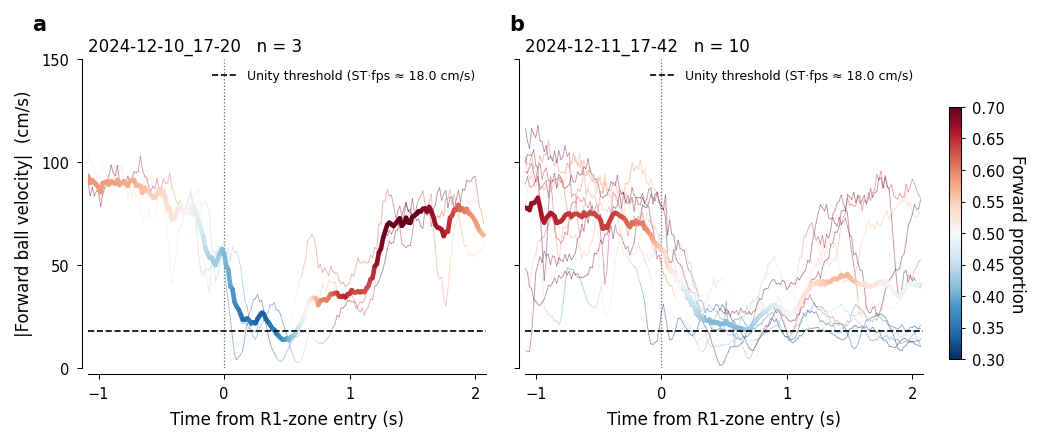

findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Arial' not found.
findfont: Fon

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_R1_true_failures_2sessions.svg


In [ ]:
CF_SESSIONS = ['2024-12-10', '2024-12-11']  # left, right
N_PRE, N_POST = 65, 125                      # frames before / after R1 entry
Y_MAX_CMS = 150.0
COLOR_VMIN, COLOR_VMAX = 0.3, 0.7
CMAP_NAME = 'RdBu_r'
FPS_NOMINAL = 60.0

_cf_rc = {
    'font.family': 'Arial, Helvetica, sans-serif',
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 0.8,
    'lines.solid_capstyle': 'round',
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'figure.dpi': 150,
}
TRIAL_LW     = 0.45        # thin individuals -> "swarm" context
TRIAL_ALPHA  = 0.40
MEAN_LW      = 2.2
THR_LW       = 0.8
PANEL_LABELS = ('a', 'b')

cf_lookup = {}
for full in session_names:
    full = str(full)
    short = '_'.join(full.split('_')[:2])    # 'YYYY-MM-DD_HH-MM'
    cf_lookup[short] = (short, full)
    cf_lookup[full.split('_')[0]] = (short, full)   # bare date
    cf_lookup[full] = (short, full)
cf_resolved = [cf_lookup[s] for s in CF_SESSIONS]
cf_short_ids = [s for s, _ in cf_resolved]
cf_full_session_names = [f for _, f in cf_resolved]
print('Loading BehaviorFramewise for:', cf_full_session_names)

framew_beh_cf = analytics.get_analytics('BehaviorFramewise',
                                          session_names=cf_full_session_names)


def _cf_short_session(full_name):
    return '_'.join(str(full_name).split('_')[:2])


def _cf_summarize_R1_candidates(framew_df):
    """Trials with cue=1, choice_R1<=0, and at least one in-R1-zone frame
    where the forward-only velocity dipped below ST*fps."""
    zf = framew_df.loc[framew_df['track_zone'].eq('reward1Zone')].copy()
    zf['_session_id'] = zf.index.get_level_values('session_id')
    zf['_entry_id']   = zf.index.get_level_values('entry_id')
    for col in ['trial_id','cue','choice_R1','frame_raw',
                'velocity_threshold_at_R1','fps']:
        zf[col] = pd.to_numeric(zf[col], errors='coerce')
    zf = zf.dropna(subset=['_session_id','trial_id','cue','choice_R1',
                            'frame_raw','velocity_threshold_at_R1','fps'])
    zf['abs_frame_raw']    = zf['frame_raw'].abs()
    zf['forward_threshold'] = zf['velocity_threshold_at_R1'] * zf['fps']
    zf['below_thr']         = zf['abs_frame_raw'] < zf['forward_threshold']

    grouped = zf.groupby(['_session_id','trial_id'], sort=False)
    summary = grouped.agg(
        cue=('cue','first'),
        choice_R1=('choice_R1','first'),
        velocity_threshold=('velocity_threshold_at_R1','first'),
        fps=('fps','median'),
        forward_threshold=('forward_threshold','median'),
        n_below=('below_thr','sum'),
    ).reset_index().rename(columns={'_session_id': 'session_id'})

    skip_mask = pd.to_numeric(summary['choice_R1'], errors='coerce').fillna(0).le(0)
    cue_mask  = pd.to_numeric(summary['cue'], errors='coerce').eq(1)
    return summary.loc[skip_mask & cue_mask & summary['n_below'].gt(0)].copy()


def _cf_build_window(full_session_id, trial_ids, framew_df, n_pre, n_post):
    sf = (framew_df.xs(full_session_id, level='session_id')
                   .reset_index()
                   .sort_values(['trial_id', 'entry_id']))
    chunks = []
    for trial_id in trial_ids:
        tf = sf.loc[pd.to_numeric(sf['trial_id'], errors='coerce').eq(trial_id)].copy()
        if tf.empty:
            continue
        locs = np.flatnonzero(tf['track_zone'].eq('reward1Zone').to_numpy())
        if locs.size == 0:
            continue
        entry_loc = int(locs[0])
        start = max(0, entry_loc - n_pre)
        stop  = min(len(tf), entry_loc + n_post)
        win = tf.iloc[start:stop].copy()
        win['rel_frame'] = np.arange(start, stop) - entry_loc
        win['_trial_id'] = trial_id
        chunks.append(win)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


cf_candidates = _cf_summarize_R1_candidates(framew_beh_cf)
print('R1 forward-only failure candidates per session:')
print(cf_candidates.groupby(cf_candidates['session_id'].astype(str).map(_cf_short_session))['trial_id']
      .count().to_string())

with plt.rc_context(_cf_rc):
    fig_cf, axes_cf = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True,
                                    gridspec_kw=dict(width_ratios=[1, 1], wspace=0.10))
    norm_cf = mpl.colors.Normalize(vmin=COLOR_VMIN, vmax=COLOR_VMAX)
    cmap_cf = mpl.colormaps[CMAP_NAME]
    last_lc = None

    def _gradient_line(ax, x, y, c, lw, alpha, zorder):
        """Draw a single trajectory whose segments are coloured by `c` (a
        per-point value averaged between adjacent points)."""
        if x.size < 2:
            return None
        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
        seg_c = 0.5 * (c[:-1] + c[1:])
        lc = LineCollection(segs, cmap=cmap_cf, norm=norm_cf,
                             linewidths=lw, alpha=alpha, zorder=zorder,
                             capstyle='round', joinstyle='round')
        lc.set_array(seg_c)
        ax.add_collection(lc)
        return lc

    for panel_idx, (ax, short) in enumerate(zip(axes_cf, cf_short_ids)):
        sess_cands = cf_candidates[cf_candidates['session_id'].astype(str).eq(short)]
        trial_ids = sess_cands['trial_id'].drop_duplicates().tolist()
        win = _cf_build_window(short, trial_ids, framew_beh_cf, N_PRE, N_POST)

        panel_label_x = -0.14 if panel_idx == 0 else -0.04
        ax.text(panel_label_x, 1.08, PANEL_LABELS[panel_idx],
                transform=ax.transAxes,
                fontsize=10, fontweight='bold', va='bottom', ha='left')

        if win.empty:
            ax.text(0.5, 0.5, 'No matching trials', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(f'{short}  (n=0)', loc='left')
            continue

        for trial_id, td in win.groupby('_trial_id', sort=False):
            x_t = td['rel_frame'].to_numpy(dtype=float) / FPS_NOMINAL
            y_t = td['frame_raw'].abs().to_numpy(dtype=float)
            c_t = td['frame_forward_prop'].to_numpy(dtype=float)
            mask = np.isfinite(x_t) & np.isfinite(y_t) & np.isfinite(c_t)
            if mask.sum() < 2:
                continue
            lc = _gradient_line(ax, x_t[mask], y_t[mask], c_t[mask],
                                lw=TRIAL_LW, alpha=TRIAL_ALPHA, zorder=3)
            if lc is not None:
                last_lc = lc

        win_plot = win.assign(abs_raw=win['frame_raw'].abs())
        mt = (win_plot.groupby('rel_frame', as_index=False)
                       [['abs_raw', 'frame_forward_prop']].mean()
                       .dropna(subset=['abs_raw'])
                       .sort_values('rel_frame'))
        if len(mt) >= 2:
            lc_mean = _gradient_line(
                ax,
                mt['rel_frame'].to_numpy(dtype=float) / FPS_NOMINAL,
                mt['abs_raw'].to_numpy(dtype=float),
                mt['frame_forward_prop'].to_numpy(dtype=float),
                lw=MEAN_LW, alpha=1.0, zorder=4,
            )
            if lc_mean is not None:
                last_lc = lc_mean

        # Threshold line: the Unity per-frame stop rule (ST x fps).
        thr = float(sess_cands['forward_threshold'].median())
        ax.axhline(thr, color='black', linestyle='--', linewidth=THR_LW, zorder=5,
                   label=f'Unity threshold (ST·fps ≈ {thr:.1f} cm/s)')

        ax.axvline(0.0, color='black', linestyle=':', linewidth=0.6,
                   alpha=0.6, zorder=2)

        ax.set_xlim(-N_PRE / FPS_NOMINAL, N_POST / FPS_NOMINAL)
        ax.set_ylim(0, Y_MAX_CMS)
        ax.set_xticks([-1.0, 0.0, 1.0, 2.0])
        ax.set_yticks([0, 50, 100, 150])
        ax.set_title(f'{short}   n = {len(trial_ids)}', loc='left', pad=4)
        ax.set_xlabel('Time from R1-zone entry (s)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 3))
        ax.spines['bottom'].set_position(('outward', 3))
        ax.legend(loc='upper right', frameon=False, handlelength=2.0,
                  borderaxespad=0.4, labelspacing=0.2)

    axes_cf[0].set_ylabel('|Forward ball velocity|  (cm/s)')

    fig_cf.subplots_adjust(left=0.085, right=0.88, top=0.91, bottom=0.20)
    if last_lc is not None:
        cax = fig_cf.add_axes([0.905, 0.22, 0.011, 0.58])
        cbar = fig_cf.colorbar(last_lc, cax=cax)
        cbar.set_label('Forward proportion', rotation=270, labelpad=10)
        cbar.ax.tick_params(width=0.5, length=2)
        cbar.outline.set_linewidth(0.5)

    plt.show()

EXPORT_DIR = os.path.join(os.getcwd(), 'figures_thesis_sam')
os.makedirs(EXPORT_DIR, exist_ok=True)
svg_path = os.path.join(EXPORT_DIR, 'figure_R1_true_failures_2sessions.svg')
fig_cf.savefig(svg_path, format='svg', bbox_inches='tight')
print(f'Wrote {svg_path}')

Retraction failures per session:
                  R1  R2
session_short           
2024-11-14_15-01  10  10
2024-11-14_16-40  11   1
2024-11-15_15-48  17   8
2024-11-20_17-46   4   1
2024-11-21_17-22   4   1
2024-11-22_16-01   5   1
2024-11-25_16-25   1   2
2024-11-26_16-39   6   0
2024-11-27_16-11   0   1
2024-11-28_17-41   4   0
2024-12-02_16-09   1   2
2024-12-03_16-23   1   0
2024-12-04_18-06   0   1
2024-12-06_16-49   0   0
2024-12-09_17-45   1   1
2024-12-10_17-20   0   1
2024-12-11_17-42   4   4
2024-12-12_16-13   1   2
2024-12-13_17-10   0   5
2025-01-14_18-08   1   0
2025-01-15_17-18   1   0
2025-01-16_17-47   0   0
2025-01-17_16-55   0   0
2025-01-23_16-48   0   2
2025-01-24_12-24   1   0
2025-01-24_19-37   0   0
2025-01-25_10-55   0   2
2025-01-25_21-29   2   0
2025-01-26_13-45   0   0
2025-01-26_21-48   0   0
2025-01-27_13-39   3   3
Total R1 failures: 78
Total R2 failures: 48


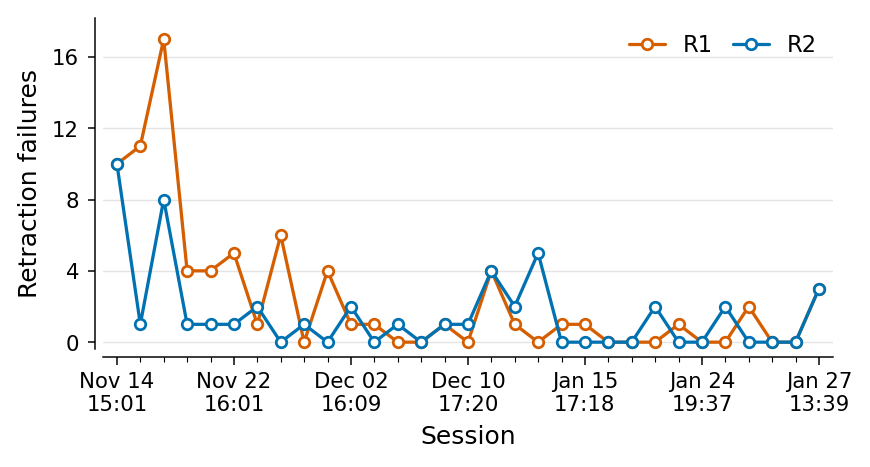

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/figure_retraction_failures_by_session.svg


In [ ]:
# Retraction failures per session: reward valve opened, reward removed by
# vacuum, no lick between reward opening and vacuum, and a lick within 250 ms
# after vacuum. The reward is assigned to R1/R2 by nearest frame position at
# the reward-open timestamp.


RF_LICK_AFTER_VACUUM_MS = 250.0
RF_REWARD_FRAME_TOLERANCE_US = 250_000
RF_R1_CENTER_CM = 80.0
RF_R2_CENTER_CM = 200.0
RF_EXCLUDED_SESSION_NAMES = EXCLUDED_SESSION_NAMES

_rf_rc = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8.5,
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 9,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3.0,
    'ytick.major.size': 3.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 1.3,
    'lines.solid_capstyle': 'round',
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
    'figure.dpi': 180,
}


def _rf_data_root():
    candidates = [
        Path('/mnt/slow/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100'),
        Path('/mnt/fast/promoted/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100'),
        Path('/mnt/NAS/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find the rYL006 P1100 data root.')


def _rf_session_names(data_root):
    names = [str(s) for s in session_names]
    names = sorted(s for s in names if s not in set(RF_EXCLUDED_SESSION_NAMES))
    return names


def _rf_reward_zone_from_position(position_cm):
    if pd.isna(position_cm):
        return np.nan
    d_r1 = abs(float(position_cm) - RF_R1_CENTER_CM)
    d_r2 = abs(float(position_cm) - RF_R2_CENTER_CM)
    return 1 if d_r1 <= d_r2 else 2


def _rf_events_for_session(session_name, data_root):
    session_dir = data_root / session_name / 'session_analytics'
    events = pd.read_parquet(session_dir / 'BehaviorEvents.parquet')
    frames = pd.read_parquet(
        session_dir / 'BehaviorFramewise.parquet',
        columns=['frame_pc_timestamp', 'frame_position', 'track_zone', 'trial_id'],
    )

    events = events.copy()
    events['event_pc_timestamp'] = pd.to_numeric(
        events['event_pc_timestamp'], errors='coerce'
    ).astype('int64')

    frames = frames[['frame_pc_timestamp', 'frame_position', 'track_zone', 'trial_id']].dropna(
        subset=['frame_pc_timestamp']
    ).copy()
    frames['frame_pc_timestamp'] = pd.to_numeric(
        frames['frame_pc_timestamp'], errors='coerce'
    ).astype('int64')
    frames = frames.sort_values('frame_pc_timestamp')

    rewards = events.loc[events['event_name'].eq('R')].sort_values('event_pc_timestamp').copy()
    if rewards.empty:
        return pd.DataFrame()

    rewards = pd.merge_asof(
        rewards,
        frames,
        left_on='event_pc_timestamp',
        right_on='frame_pc_timestamp',
        direction='nearest',
        tolerance=RF_REWARD_FRAME_TOLERANCE_US,
        suffixes=('', '_frame'),
    )
    rewards['reward_zone'] = rewards['frame_position'].map(_rf_reward_zone_from_position)

    rows = []
    for trial_id, trial_events in events.dropna(subset=['trial_id']).groupby('trial_id'):
        trial_events = trial_events.sort_values('event_pc_timestamp')
        trial_rewards = rewards.loc[rewards['trial_id'].eq(trial_id)].sort_values('event_pc_timestamp')
        trial_vacuums = trial_events.loc[trial_events['event_name'].eq('V')].sort_values('event_pc_timestamp')
        if trial_rewards.empty or trial_vacuums.empty:
            continue

        lick_times = trial_events.loc[
            trial_events['event_name'].eq('L'), 'event_pc_timestamp'
        ].to_numpy(dtype=np.int64)

        for _, vacuum in trial_vacuums.iterrows():
            previous_rewards = trial_rewards.loc[
                trial_rewards['event_pc_timestamp'] <= vacuum['event_pc_timestamp']
            ]
            if previous_rewards.empty:
                continue

            reward = previous_rewards.iloc[-1]
            reward_time = int(reward['event_pc_timestamp'])
            vacuum_time = int(vacuum['event_pc_timestamp'])

            licks_before_vacuum = lick_times[(lick_times >= reward_time) & (lick_times < vacuum_time)]
            licks_after_vacuum = lick_times[lick_times >= vacuum_time]
            first_lick_after_ms = (
                (licks_after_vacuum[0] - vacuum_time) / 1_000
                if licks_after_vacuum.size else np.nan
            )
            retraction_failure = (
                licks_before_vacuum.size == 0
                and pd.notna(first_lick_after_ms)
                and first_lick_after_ms <= RF_LICK_AFTER_VACUUM_MS
            )

            rows.append({
                'session_name': session_name,
                'session_short': '_'.join(session_name.split('_')[:2]),
                'trial_id': int(trial_id),
                'reward_zone': reward['reward_zone'],
                'reward_position_cm': reward['frame_position'],
                'reward_track_zone': reward['track_zone'],
                'reward_to_vacuum_s': (vacuum_time - reward_time) / 1_000_000,
                'licks_between_reward_and_vacuum': int(licks_before_vacuum.size),
                'first_lick_after_vacuum_ms': first_lick_after_ms,
                'retraction_failure': bool(retraction_failure),
            })

    return pd.DataFrame(rows)


rf_data_root = _rf_data_root()
rf_session_names = _rf_session_names(rf_data_root)
rf_event_rows = [
    _rf_events_for_session(session_name, rf_data_root)
    for session_name in rf_session_names
]
rf_failures = pd.concat(rf_event_rows, ignore_index=True) if rf_event_rows else pd.DataFrame()

rf_counts = (
    rf_failures.loc[rf_failures['retraction_failure']]
    .pivot_table(index='session_name', columns='reward_zone', values='trial_id', aggfunc='count', fill_value=0)
    .reindex(rf_session_names, fill_value=0)
    .reindex(columns=[1, 2], fill_value=0)
    .astype(int)
)
rf_counts.columns = ['R1', 'R2']
rf_counts['session_short'] = ['_'.join(s.split('_')[:2]) for s in rf_counts.index]

rf_count_table = rf_counts.set_index('session_short')[['R1', 'R2']]
print('Retraction failures per session:')
print(rf_count_table.to_string())
print(f'Total R1 failures: {int(rf_count_table["R1"].sum())}')
print(f'Total R2 failures: {int(rf_count_table["R2"].sum())}')

EXPORT_DIR = Path.cwd() / 'figures_thesis_sam'
EXPORT_DIR.mkdir(exist_ok=True)
rf_svg_path = EXPORT_DIR / 'figure_retraction_failures_by_session.svg'

with plt.rc_context(_rf_rc):
    fig_rf, ax_rf = plt.subplots(figsize=(4.8, 2.75))
    x = np.arange(len(rf_count_table))
    session_datetimes = pd.to_datetime(rf_count_table.index, format='%Y-%m-%d_%H-%M')
    major_tick_idx = np.unique(
        np.r_[0, np.arange(5, len(rf_count_table), 5), len(rf_count_table) - 1]
    ).astype(int)
    major_tick_labels = [session_datetimes[i].strftime('%b %d\n%H:%M') for i in major_tick_idx]
    colors = {'R1': '#D55E00', 'R2': '#0072B2'}

    for label in ['R1', 'R2']:
        y = rf_count_table[label].to_numpy(dtype=float)
        ax_rf.plot(
            x, y,
            marker='o', markersize=4.2,
            markerfacecolor='white', markeredgewidth=1.1,
            color=colors[label], label=label,
            zorder=3,
        )

    ax_rf.set_ylabel('Retraction failures')
    ax_rf.set_xlabel('Session')
    ax_rf.set_xlim(-0.6, len(rf_count_table) - 0.4)
    ax_rf.set_xticks(major_tick_idx)
    ax_rf.set_xticklabels(major_tick_labels)
    ax_rf.set_xticks(x, minor=True)
    ax_rf.tick_params(axis='x', which='major', pad=3.0)
    ax_rf.tick_params(axis='x', which='minor', bottom=True, labelbottom=False, length=1.8, width=0.45)
    ymax = max(1, int(rf_count_table[['R1', 'R2']].to_numpy().max()))
    ax_rf.set_ylim(-0.4, ymax + 1.2)
    ax_rf.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=5))
    ax_rf.grid(axis='y', color='#d9d9d9', linewidth=0.55, alpha=0.7)
    ax_rf.set_axisbelow(True)
    ax_rf.spines['top'].set_visible(False)
    ax_rf.spines['right'].set_visible(False)
    ax_rf.spines['left'].set_position(('outward', 3))
    ax_rf.spines['bottom'].set_position(('outward', 3))
    ax_rf.legend(
        frameon=False, loc='upper right', ncol=2,
        handlelength=1.6, columnspacing=0.9, borderaxespad=0.3,
    )
    fig_rf.subplots_adjust(left=0.14, right=0.985, top=0.95, bottom=0.28)
    fig_rf.savefig(rf_svg_path, format='svg', bbox_inches='tight')
    plt.show()

print(f'Wrote {rf_svg_path}')

# Ensemble weights and projections (stacked, one panel per ensemble)

Adapted from `experimental_ensembles.ipynb` (the per-ensemble 2x2 subplot grid),
but with the subplots taken apart into two separate stacked figures, one panel
per ensemble (Assembly001-Assembly023, 23 panels each):

- **Ensemble weights** &mdash; the per-neuron ICA weight vector for each
  ensemble (HP units yellow, mPFC magenta; black rings mark |weight| > 0.2).
- **Ensemble projections** &mdash; the concatenated projection over the whole
  recording, smoothed at 15-min (solid) and 30-s (faint) windows. Dashed
  verticals mark session boundaries; the date labels along the top are cut to
  the day (the recording-hour suffix after the first `_` is dropped).

Only these two plot kinds are kept (the abs-weight histogram from the original
grid is dropped). Fonts are enlarged so the panel and session-date labels stay
legible at this stacked scale.

In [ ]:
ensambles = analytics.get_analytics(
    'ConcatenatedEnsambles40ms', session_names=session_names
)
ensamble_proj = analytics.get_analytics(
    'ConcatenatedEnsambleProj40ms', session_names=session_names
).drop('to_ephys_timestamp', axis=1)
ensamble_proj.set_index(['session_id', 'from_ephys_timestamp'], inplace=True)

n_ensembles = ensambles.shape[1]
n_units = ensambles.shape[0]
n_sessions = ensamble_proj.index.get_level_values('session_id').nunique()
print(f'{n_ensembles} ensembles, {n_units} units, {n_sessions} sessions')

/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambles40ms.parquet
/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/../../animal_analytics/ConcatenatedEnsambleProj40ms.parquet


23 ensembles, 77 units, 26 sessions


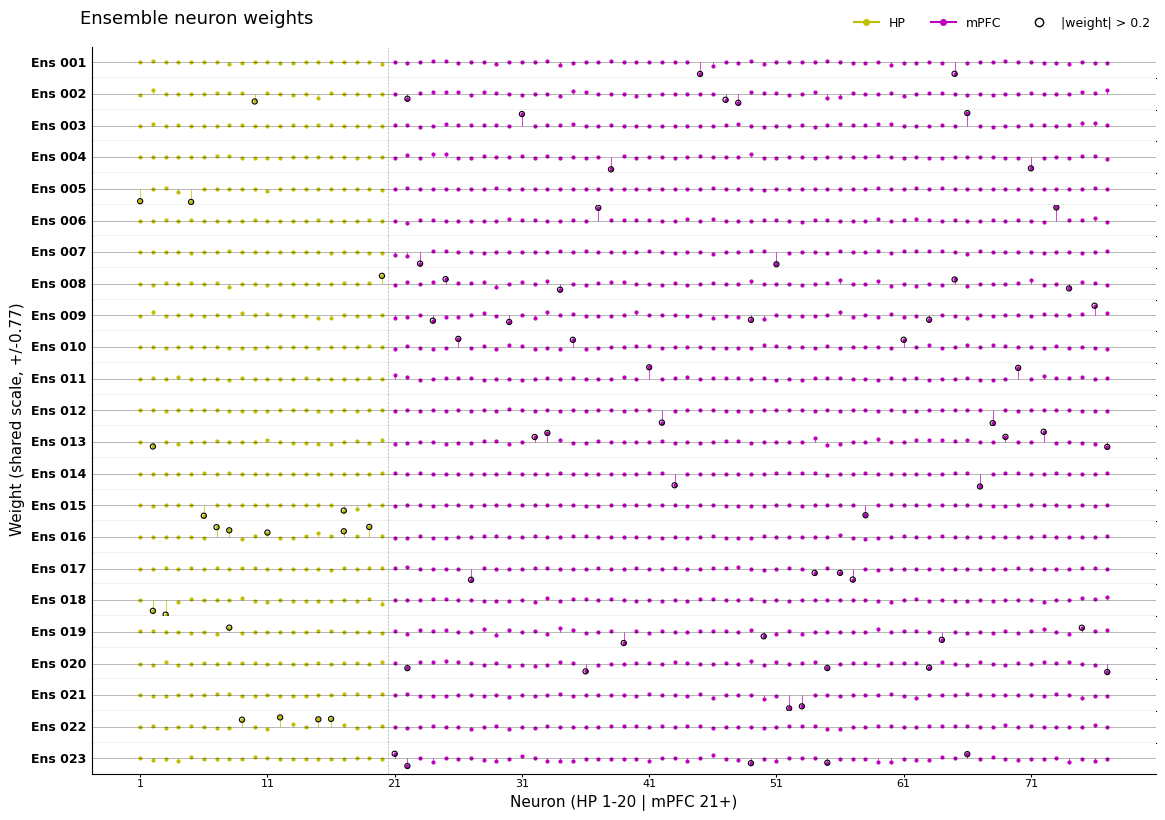

In [ ]:
A4_LANDSCAPE = (11.69, 8.27)  # inches; one landscape A4 page
HP_NEURON_COUNT = 20          # first 20 units are HP, the rest are mPFC
WEIGHT_THR = 0.2              # |weight| above this gets a black ring
PANEL_LABEL_FS = 9            # ensemble name on the left of each panel
AXIS_LABEL_FS = 11            # shared x/y axis labels
TICK_FS = 8
LEGEND_FS = 9
SUPTITLE_FS = 13

ensemble_cols = list(ensambles.columns)
n_ens = len(ensemble_cols)

fig_weights, axes = plt.subplots(
    nrows=n_ens, ncols=1, figsize=A4_LANDSCAPE, sharex=True, sharey=True,
    gridspec_kw={'hspace': 0.0},
)

ylim = np.max(np.abs(ensambles.values)) * 1.1

for ax, col in zip(axes, ensemble_cols):
    name = str(col).replace('Assembly', 'Ens ')
    weights = ensambles[col]

    ml1 = ax.stem(np.arange(HP_NEURON_COUNT), weights.iloc[:HP_NEURON_COUNT],
                  linefmt='y-', markerfmt='yo', basefmt=' ')
    ml2 = ax.stem(np.arange(HP_NEURON_COUNT, n_units), weights.iloc[HP_NEURON_COUNT:],
                  linefmt='m-', markerfmt='mo', basefmt=' ')
    for ml in (ml1, ml2):
        ml.markerline.set_markersize(2)
        ml.stemlines.set_linewidth(0.5)

    mask = (np.abs(weights) > WEIGHT_THR).values
    high_x = np.arange(n_units)[mask]
    ax.scatter(high_x, weights.values[mask], s=14, facecolors='none',
               edgecolors='k', linewidths=0.8, zorder=3)

    ax.axhline(0, color='k', linewidth=0.4, alpha=0.5)
    ax.axvline(HP_NEURON_COUNT - 0.5, color='gray', linestyle='--',
               linewidth=0.5, alpha=0.6)
    ax.set_ylim(-ylim, ylim)
    ax.set_ylabel(name, rotation=0, ha='right', va='center',
                  fontsize=PANEL_LABEL_FS, fontweight='bold')
    ax.tick_params(axis='y', labelleft=False, length=0)  # weight scale is shared
    ax.tick_params(axis='x', labelsize=TICK_FS, length=2, pad=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda neuron_idx, _: f'{neuron_idx + 1:g}'))
axes[-1].set_xlabel('Neuron (HP 1-20 | mPFC 21+)', fontsize=AXIS_LABEL_FS)
fig_weights.supylabel(f'Weight (shared scale, +/-{ylim:.2f})', fontsize=AXIS_LABEL_FS, x=0.01)

legend_handles = [
    Line2D([0], [0], color='y', marker='o', linestyle='-', markersize=4, label='HP'),
    Line2D([0], [0], color='m', marker='o', linestyle='-', markersize=4, label='mPFC'),
    Line2D([0], [0], color='k', marker='o', linestyle='none', markerfacecolor='none',
           markeredgecolor='k', markersize=6, label='|weight| > 0.2'),
]
fig_weights.legend(handles=legend_handles, fontsize=LEGEND_FS, ncol=3,
                   loc='upper right', bbox_to_anchor=(0.995, 1.0), frameon=False)
fig_weights.suptitle('Ensemble neuron weights', fontsize=SUPTITLE_FS, x=0.07,
                     ha='left', y=0.995)
fig_weights.subplots_adjust(left=0.08, right=0.99, top=0.95, bottom=0.07)
plt.show()

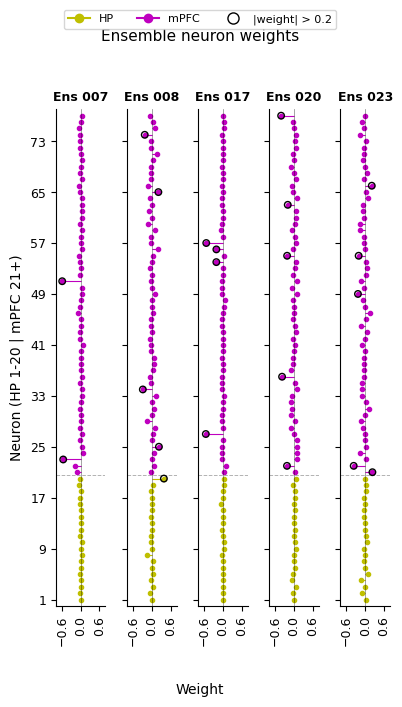

In [ ]:
HP_NEURON_COUNT = 20      # first 20 units are HP, the rest are mPFC
WEIGHT_THR = 0.2          # |weight| above this gets a black ring
TARGET_ENS = ['007', '008', '017', '020', '023']  # ensembles to show
PANEL_LABEL_FS = 9        # ensemble name inside each panel
AXIS_LABEL_FS = 10        # shared x/y axis labels
TICK_FS = 9               # tick labels
LEGEND_FS = 8
SUPTITLE_FS = 11
MARKER_SIZE = 3           # stem dot size

_ens_num = lambda col: ''.join(ch for ch in str(col) if ch.isdigit())
selected_cols = [c for tgt in TARGET_ENS for c in ensambles.columns
                 if _ens_num(c) == tgt]
n_sel = len(selected_cols)

xlim = np.max(np.abs(ensambles[selected_cols].values)) * 1.35

fig_weights_rot, axes = plt.subplots(
    nrows=1, ncols=n_sel, figsize=(4.1, 7.0), sharex=True, sharey=True,
)

for ax, col in zip(axes, selected_cols):
    name = str(col).replace('Assembly', 'Ens ')
    weights = ensambles[col]

    m_hp, s_hp, _ = ax.stem(np.arange(HP_NEURON_COUNT), weights.iloc[:HP_NEURON_COUNT],
            orientation='horizontal', linefmt='y-', markerfmt='yo', basefmt=' ')
    m_pf, s_pf, _ = ax.stem(np.arange(HP_NEURON_COUNT, n_units), weights.iloc[HP_NEURON_COUNT:],
            orientation='horizontal', linefmt='m-', markerfmt='mo', basefmt=' ')
    for m in (m_hp, m_pf):
        m.set_markersize(MARKER_SIZE)
    for s in (s_hp, s_pf):
        s.set_linewidth(0.8)

    mask = (np.abs(weights) > WEIGHT_THR).values
    high_y = np.arange(n_units)[mask]
    ax.scatter(weights.values[mask], high_y, s=22, facecolors='none',
               edgecolors='k', linewidths=1.0, zorder=3)

    ax.axvline(0, color='k', linewidth=0.5, alpha=0.5)
    ax.axhline(HP_NEURON_COUNT - 0.5, color='gray', linestyle='--',
               linewidth=0.7, alpha=0.6)
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(-1, n_units)
    ax.set_title(name, fontsize=PANEL_LABEL_FS, fontweight='bold')

    ax.xaxis.set_major_locator(MaxNLocator(nbins=3, prune='both'))
    ax.tick_params(labelsize=TICK_FS)
    plt.setp(ax.get_xticklabels(), rotation=90)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda neuron_idx, _: f'{neuron_idx + 1:g}'))
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
axes[0].set_ylabel('Neuron (HP 1-20 | mPFC 21+)', fontsize=AXIS_LABEL_FS)
fig_weights_rot.supxlabel('Weight', fontsize=AXIS_LABEL_FS)

legend_handles = [
    Line2D([0], [0], color='y', marker='o', linestyle='-', label='HP'),
    Line2D([0], [0], color='m', marker='o', linestyle='-', label='mPFC'),
    Line2D([0], [0], color='k', marker='o', linestyle='none', markerfacecolor='none',
           markeredgecolor='k', markersize=8, label='|weight| > 0.2'),
]
fig_weights_rot.legend(handles=legend_handles, fontsize=LEGEND_FS, ncol=3,
           loc='upper center', bbox_to_anchor=(0.5, 1.0))
fig_weights_rot.suptitle('Ensemble neuron weights', fontsize=SUPTITLE_FS, y=0.965)
fig_weights_rot.tight_layout(rect=(0, 0.02, 1, 0.94), w_pad=1.2)
fig_weights_rot.savefig('ensemble_neuron_weights_rotated.svg', format='svg', bbox_inches='tight')
plt.show()

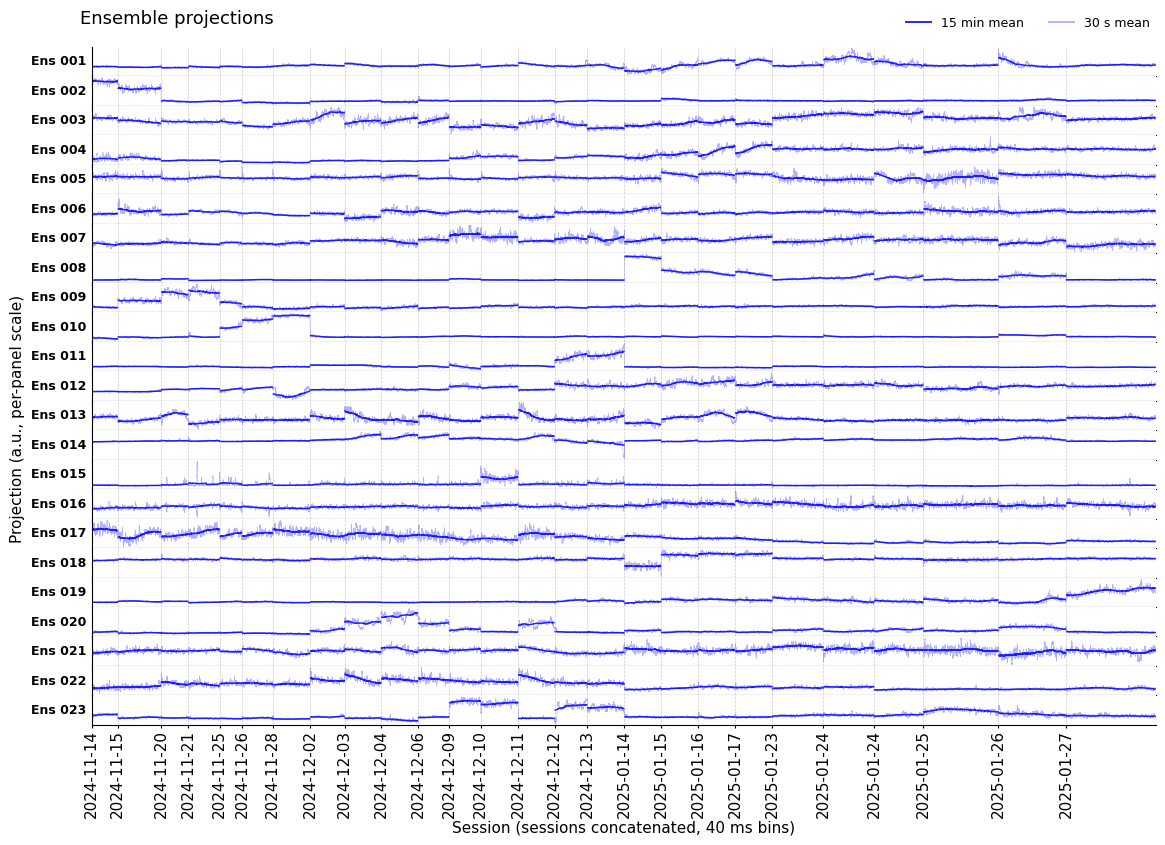

In [ ]:
A4_LANDSCAPE = (11.69, 8.27)  # inches; one landscape A4 page
PROJ_CLIP = 3                 # clip projection before smoothing
WIN_15MIN = 25 * 60 * 15      # 15 min rolling window (25 Hz -> 40 ms bins)
MINP_15MIN = 25 * 60 * 8      # min periods for the 15 min mean
WIN_30S = 25 * 30             # 30 s rolling window
PANEL_LABEL_FS = 9            # ensemble name on the left of each panel
AXIS_LABEL_FS = 11            # shared x/y axis labels
SESSION_FS = 11               # session-date labels on the bottom axis
LEGEND_FS = 9
SUPTITLE_FS = 13

ensemble_cols = list(ensamble_proj.columns)
n_ens = len(ensemble_cols)
session_ids = list(ensamble_proj.index.unique(level='session_id'))

boundaries, date_labels = [], []
sample_cnt = 0
for s_id in session_ids:
    boundaries.append(sample_cnt)
    date_labels.append(str(s_id).split('_')[0])
    sample_cnt += len(ensamble_proj.loc[s_id])
total_len = sample_cnt

fig_proj, axes = plt.subplots(
    nrows=n_ens, ncols=1, figsize=A4_LANDSCAPE, sharex=True,
    gridspec_kw={'hspace': 0.0},
)

for ax, col in zip(axes, ensemble_cols):
    name = str(col).replace('Assembly', 'Ens ')
    clipped = np.clip(ensamble_proj[col], -PROJ_CLIP, PROJ_CLIP)

    smoothed_30s = clipped.groupby(level='session_id').rolling(
        window=WIN_30S, center=True, min_periods=1).mean().values
    smoothed_15min = clipped.groupby(level='session_id').rolling(
        window=WIN_15MIN, center=True, min_periods=MINP_15MIN).mean().values

    ax.plot(smoothed_30s, color='blue', alpha=0.3, linewidth=0.4)
    ax.plot(smoothed_15min, color='blue', alpha=0.85, linewidth=1.1)

    for boundary in boundaries:
        ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

    ax.set_xlim(0, total_len)
    ax.set_ylabel(name, rotation=0, ha='right', va='center',
                  fontsize=PANEL_LABEL_FS, fontweight='bold')
    ax.tick_params(axis='y', labelleft=False, length=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_bottom = axes[-1]
ax_bottom.set_xticks(boundaries)
ax_bottom.set_xticklabels(date_labels, rotation=90, fontsize=SESSION_FS, ha='center')
ax_bottom.tick_params(axis='x', labelbottom=True, length=2, pad=1)
ax_bottom.set_xlabel('Session (sessions concatenated, 40 ms bins)',
                     fontsize=AXIS_LABEL_FS, labelpad=2)
fig_proj.supylabel('Projection (a.u., per-panel scale)', fontsize=AXIS_LABEL_FS, x=0.01)

legend_handles = [
    Line2D([0], [0], color='blue', alpha=0.85, lw=1.4, label='15 min mean'),
    Line2D([0], [0], color='blue', alpha=0.3, lw=1.4, label='30 s mean'),
]
fig_proj.legend(handles=legend_handles, fontsize=LEGEND_FS, ncol=2,
                loc='upper right', bbox_to_anchor=(0.995, 1.0), frameon=False)
fig_proj.suptitle('Ensemble projections', fontsize=SUPTITLE_FS, x=0.07,
                  ha='left', y=0.995)
fig_proj.subplots_adjust(left=0.08, right=0.99, top=0.95, bottom=0.13)
plt.show()

In [ ]:
EXPORT_DIR = os.path.join(os.getcwd(), 'figures_thesis_sam')
os.makedirs(EXPORT_DIR, exist_ok=True)

weights_svg = os.path.join(EXPORT_DIR, 'ensemble_neuron_weights_stacked.svg')
proj_svg = os.path.join(EXPORT_DIR, 'ensemble_projections_stacked.svg')

fig_weights.savefig(weights_svg, format='svg', bbox_inches='tight')
fig_proj.savefig(proj_svg, format='svg', bbox_inches='tight')

print(f'Wrote {weights_svg}')
print(f'Wrote {proj_svg}')

Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/ensemble_neuron_weights_stacked.svg
Wrote /home/samed/VirtualReality/analysisVR/scripted_plotting/animal_6_analysis/figures_thesis_sam/ensemble_projections_stacked.svg
